### Dark Rate Measurements

In [ ]:
"""
02_darkrate_hrppd.py
====================
Computes dark rate (Hz/cm²) for HRPPD Ch1 (P9) and Ch2 (P10)
from NPZ-cached waveforms saved by MSO64B Act on Event.

File naming expected:
    {DATA_DIR}/{RUN_PREFIX}_{PC}_ch1_{timestamp}.wfm  → cache →
    {DATA_DIR}/CACHE/{RUN_PREFIX}_{PC}_ch1_{timestamp}.npz

Run 01_build_cache_hrppd.py first.

Usage:
    python 02_darkrate_hrppd.py
"""

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
#  CONFIG
# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260408"
RUN_PREFIX       = "0408AA"

# PC voltages to process — must match file suffixes exactly
PC_VOLTAGES      = [30, 50]

# MCP voltage label for this batch
MCP_VOLTAGE      = 800          # V per MCP

# Pad area per channel
PAD_AREA_CM2     = 6.25         # cm² (from HRPPD 12 datasheet)

# Pulse detection — negative-going pulses
THRESHOLD_MV     = -5.0         # mV, adjust after inspecting noise floor

# Baseline: use first N samples
BASELINE_SAMPLES = 50

# Time window within acquisition to count pulses (avoid trigger edge)
PULSE_WINDOW_NS  = (5.0, 95.0)

# Minimum separation between pulses to avoid double-counting
MIN_PEAK_SEP_NS  = 5.0

# Channels to analyse
CHANNELS         = [1, 2]       # ch1=P9, ch2=P10
# ─────────────────────────────────────────────


def load_npz(npz_path: str):
    """Load NPZ cache directly. Returns (t_ns, v_mv) or (None, None)."""
    if not os.path.exists(npz_path):
        print(f"  WARNING: not found: {os.path.basename(npz_path)}")
        return None, None
    try:
        with np.load(npz_path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
            return t, v
    except Exception as e:
        print(f"  WARNING: failed to load {npz_path}: {e}")
        return None, None

def find_files_for_pc(data_dir: str, prefix: str, pc: int, ch: int):
    """
    Find all NPZ cache files matching:
        {data_dir}/CACHE/{prefix}_{pc}_ch{ch}_{timestamp}.npz
    Falls back to searching data_dir root if CACHE subdir not found.
    Returns sorted list of paths.
    """
    cache_dir = os.path.join(data_dir, "CACHE")

    for search_dir in [cache_dir, data_dir]:
        pattern = os.path.join(search_dir, f"{prefix}_{pc}_ch{ch}_*.npz")
        files   = sorted(glob.glob(pattern))
        if files:
            return files

    return []


def extract_timestamp(filepath: str) -> int:
    """Extract trailing timestamp integer from filename stem."""
    stem = os.path.splitext(os.path.basename(filepath))[0]
    m    = re.search(r"_(\d+)$", stem)
    return int(m.group(1)) if m else -1


def pair_channels(ch1_files, ch2_files):
    """
    Pair ch1 and ch2 NPZ files by closest timestamp.
    Returns list of (ch1_path, ch2_path) tuples.
    """
    if not ch2_files:
        return [(f, None) for f in ch1_files]

    ch2_ts = [(f, extract_timestamp(f)) for f in ch2_files]
    pairs  = []

    for f1 in ch1_files:
        ts1  = extract_timestamp(f1)
        best = min(ch2_ts, key=lambda x: abs(x[1] - ts1))
        pairs.append((f1, best[0]))

    return pairs


def subtract_baseline(v: np.ndarray, n: int = BASELINE_SAMPLES) -> np.ndarray:
    return v - np.median(v[:n])


def count_pulses(t: np.ndarray, v: np.ndarray) -> int:
    """
    Count negative-going pulses below THRESHOLD_MV within PULSE_WINDOW_NS.
    Uses simple region-minimum finder with MIN_PEAK_SEP_NS guard.
    """
    mask = (t >= PULSE_WINDOW_NS[0]) & (t <= PULSE_WINDOW_NS[1])
    t_w  = t[mask]
    v_w  = v[mask]

    if len(v_w) == 0:
        return 0

    below = v_w < THRESHOLD_MV
    if not np.any(below):
        return 0

    dt_ns       = float(np.median(np.diff(t_w))) if len(t_w) > 1 else 1.0
    min_sep_smp = max(1, int(MIN_PEAK_SEP_NS / dt_ns))

    count = 0
    i     = 0
    while i < len(v_w):
        if below[i]:
            j = i
            while j < len(v_w) and below[j]:
                j += 1
            # local minimum in this below-threshold region
            count += 1
            i      = j + min_sep_smp
        else:
            i += 1

    return count


def process_pc_voltage(pc: int):
    """
    Process all waveforms for one PC voltage setting.
    Returns result dict or None.
    """
    ch1_files = find_files_for_pc(DATA_DIR, RUN_PREFIX, pc, 1)
    ch2_files = find_files_for_pc(DATA_DIR, RUN_PREFIX, pc, 2)

    if not ch1_files:
        print(f"  [PC={pc}V] No ch1 files found — skipping.")
        return None

    print(f"  [PC={pc}V] ch1: {len(ch1_files)} files | ch2: {len(ch2_files)} files")

    pairs = pair_channels(ch1_files, ch2_files)

    record_len_ns = None
    ch1_total     = 0
    ch2_total     = 0
    n_waveforms   = 0

    for f1, f2 in pairs:
        t1, v1 = load_npz(f1)
        if t1 is None:
            continue

        v1 = subtract_baseline(v1)

        if record_len_ns is None:
            record_len_ns = float(t1[-1] - t1[0])

        ch1_total   += count_pulses(t1, v1)
        n_waveforms += 1

        if f2 is not None:
            t2, v2 = load_npz(f2)
            if t2 is not None:
                v2         = subtract_baseline(v2)
                ch2_total += count_pulses(t2, v2)

    if n_waveforms == 0 or record_len_ns is None:
        print(f"  [PC={pc}V] No valid waveforms processed.")
        return None

    total_time_s = n_waveforms * (record_len_ns * 1e-9)

    rate_ch1 = ch1_total / (total_time_s * PAD_AREA_CM2)
    rate_ch2 = ch2_total / (total_time_s * PAD_AREA_CM2)
    err_ch1  = np.sqrt(max(ch1_total, 1)) / (total_time_s * PAD_AREA_CM2)
    err_ch2  = np.sqrt(max(ch2_total, 1)) / (total_time_s * PAD_AREA_CM2)

    print(f"  [PC={pc}V] {n_waveforms} wfm | T={total_time_s:.4f}s | "
          f"Ch1(P9): {ch1_total} pulses → {rate_ch1:.1f} ± {err_ch1:.1f} Hz/cm² | "
          f"Ch2(P10): {ch2_total} pulses → {rate_ch2:.1f} ± {err_ch2:.1f} Hz/cm²")

    return {
        'pc_voltage'   : pc,
        'n_waveforms'  : n_waveforms,
        'total_time_s' : total_time_s,
        'ch1_counts'   : ch1_total,
        'ch2_counts'   : ch2_total,
        'ch1_rate'     : rate_ch1,
        'ch2_rate'     : rate_ch2,
        'ch1_err'      : err_ch1,
        'ch2_err'      : err_ch2,
    }


def plot_results(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.errorbar(df['pc_voltage'], df['ch1_rate'],
                yerr=df['ch1_err'],
                fmt='o-', color='steelblue', linewidth=1.8,
                markersize=7, capsize=4,
                label=f'P9 / Ch1 — {MCP_VOLTAGE} V MCP')

    ax.errorbar(df['pc_voltage'], df['ch2_rate'],
                yerr=df['ch2_err'],
                fmt='s--', color='tomato', linewidth=1.8,
                markersize=7, capsize=4,
                label=f'P10 / Ch2 — {MCP_VOLTAGE} V MCP')

    ax.set_yscale('log')
    ax.set_xlabel('Photocathode Voltage (V)', fontsize=13)
    ax.set_ylabel('Dark Rate (Hz/cm²)',        fontsize=13)
    ax.set_title(
        f'HRPPD 12 — Dark Rate vs Photocathode Voltage\n'
        f'MCP = {MCP_VOLTAGE} V/MCP  |  threshold = {THRESHOLD_MV} mV',
        fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

    plt.tight_layout()
    out = os.path.join(DATA_DIR, f"{RUN_PREFIX}_{MCP_VOLTAGE}MCP_darkrate.png")
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Plot saved → {out}")


def main():
    print("=" * 65)
    print("HRPPD 12 — Dark Rate Analysis")
    print(f"Data dir    : {DATA_DIR}")
    print(f"Run prefix  : {RUN_PREFIX}")
    print(f"MCP voltage : {MCP_VOLTAGE} V/MCP")
    print(f"Threshold   : {THRESHOLD_MV} mV")
    print(f"Pad area    : {PAD_AREA_CM2} cm²")
    print(f"PC voltages : {PC_VOLTAGES}")
    print("=" * 65)

    results = []
    for pc in PC_VOLTAGES:
        print(f"\nProcessing PC = {pc} V …")
        res = process_pc_voltage(pc)
        if res:
            results.append(res)

    if not results:
        print("\nERROR: No results. Check DATA_DIR and file naming.")
        return

    df = pd.DataFrame(results).sort_values('pc_voltage').reset_index(drop=True)

    # Save summary
    out_csv = os.path.join(DATA_DIR, f"{RUN_PREFIX}_{MCP_VOLTAGE}MCP_darkrate.csv")
    df.to_csv(out_csv, index=False, float_format='%.4f')
    print(f"\nSummary CSV → {out_csv}")

    # Print table
    print("\n" + "=" * 70)
    print(f"{'PC (V)':>8} | {'Ch1 P9 (Hz/cm²)':>18} | "
          f"{'Ch2 P10 (Hz/cm²)':>18} | {'N wfm':>7}")
    print("-" * 70)
    for _, r in df.iterrows():
        print(f"{r['pc_voltage']:>8.0f} | "
              f"{r['ch1_rate']:>12.1f} ± {r['ch1_err']:<6.1f} | "
              f"{r['ch2_rate']:>12.1f} ± {r['ch2_err']:<6.1f} | "
              f"{r['n_waveforms']:>7.0f}")
    print("=" * 70)

    plot_results(df)


if __name__ == "__main__":
    main()

In [ ]:
"""
02_darkrate_hrppd.py
====================
Computes dark rate (Hz/cm²) for HRPPD Ch1 (P9) and Ch2 (P10)
from NPZ-cached waveforms saved by MSO64B Act on Event.

Plot style: dark rate (log y) vs MCP voltage (x), one series per PC voltage.

The pulse window is automatically clipped to the actual waveform time range,
so data is never discarded just because the scope acquisition is shorter than
PULSE_WINDOW_NS. The rate denominator always matches the counted window.

Run 01_build_cache_hrppd.py first for each data directory.
"""

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────────────────────────────────────
#  RUN CONFIGS
# ─────────────────────────────────────────────────────────────────────────────
RUN_CONFIGS = [
    {
        'data_dir'    : '/home/matthew/cache/260406',
        'run_prefix'  : '0406AA',
        'mcp_voltage' : 750,
        'pc_voltages' : [30, 50],
    },
    {
        'data_dir'    : '/home/matthew/cache/260408',
        'run_prefix'  : '0408AA',
        'mcp_voltage' : 800,
        'pc_voltages' : [30],
    },
    # ── Add future runs here ────────────────────────────────────────────────
    # {
    #     'data_dir'    : '/home/matthew/cache/XXXXXX',
    #     'run_prefix'  : 'XXXXXXAA',
    #     'mcp_voltage' : 775,
    #     'pc_voltages' : [30, 50],
    # },
]

# ─────────────────────────────────────────────────────────────────────────────
#  SHARED SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
PAD_AREA_CM2     = 6.25      # cm² per pad (HRPPD 12 datasheet)
THRESHOLD_MV     = -5.0      # mV — negative-going pulse threshold
BASELINE_SAMPLES = 50        # leading samples used for baseline median
MIN_PEAK_SEP_NS  = 5.0       # minimum separation between pulses (ns)

# Desired analysis window. Both edges are clipped to the actual waveform range,
# so this is a ceiling, not a strict requirement. Set wide enough to cover all
# your acquisitions; the code handles the rest automatically.
PULSE_WINDOW_NS  = (0.0, 200.0)

# Avoid the first and last N ns of any waveform to steer clear of
# trigger/edge artefacts that show up right at the record boundaries.
EDGE_GUARD_NS    = 5.0

# ─────────────────────────────────────────────────────────────────────────────
#  Output
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR  = RUN_CONFIGS[0]['data_dir']
OUTPUT_NAME = 'hrppd12_darkrate_combined.png'

# Colours per PC voltage
PC_COLORS = {
    -10 : '#9400D3',
      0 : '#4B0082',
     10 : '#0000FF',
     30 : '#008000',
     50 : '#FF0000',
    100 : '#FF7F00',
    200 : '#FFD700',
    300 : '#00CED1',
    400 : '#FF1493',
}
DEFAULT_COLOR = '#607D8B'


# ═════════════════════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS
# ═════════════════════════════════════════════════════════════════════════════

def load_npz(path: str):
    if not os.path.exists(path):
        print(f"  WARNING: not found: {os.path.basename(path)}")
        return None, None
    try:
        with np.load(path, allow_pickle=False) as z:
            return z["t"].copy().ravel(), z["v"].copy().ravel()
    except Exception as e:
        print(f"  WARNING: failed to load {path}: {e}")
        return None, None


def find_files_for_pc(data_dir: str, prefix: str, pc: int, ch: int):
    cache_dir = os.path.join(data_dir, "CACHE")
    for search_dir in [cache_dir, data_dir]:
        files = sorted(glob.glob(
            os.path.join(search_dir, f"{prefix}_{pc}_ch{ch}_*.npz")))
        if files:
            return files
    return []


def extract_timestamp(filepath: str) -> int:
    m = re.search(r"_(\d+)$", os.path.splitext(os.path.basename(filepath))[0])
    return int(m.group(1)) if m else -1


def pair_channels(ch1_files, ch2_files):
    if not ch2_files:
        return [(f, None) for f in ch1_files]
    ch2_ts = [(f, extract_timestamp(f)) for f in ch2_files]
    return [
        (f1, min(ch2_ts, key=lambda x: abs(x[1] - extract_timestamp(f1)))[0])
        for f1 in ch1_files
    ]


def subtract_baseline(v: np.ndarray, n: int = BASELINE_SAMPLES) -> np.ndarray:
    return v - np.median(v[:n])


def effective_window(t: np.ndarray) -> tuple:
    """
    Return the analysis window (t_lo, t_hi) for this waveform by clipping
    PULSE_WINDOW_NS to the actual data range and applying the edge guard.
    Returns (None, None) if no usable range remains.
    """
    t_lo = max(PULSE_WINDOW_NS[0], float(t[0])  + EDGE_GUARD_NS)
    t_hi = min(PULSE_WINDOW_NS[1], float(t[-1]) - EDGE_GUARD_NS)
    if t_hi <= t_lo:
        return None, None
    return t_lo, t_hi


def count_pulses_in_window(t: np.ndarray, v: np.ndarray,
                           t_lo: float, t_hi: float) -> int:
    """
    Count negative-going pulses below THRESHOLD_MV inside [t_lo, t_hi].
    Uses contiguous-region detection with MIN_PEAK_SEP_NS dead-time guard.
    """
    mask = (t >= t_lo) & (t <= t_hi)
    t_w, v_w = t[mask], v[mask]
    if len(v_w) == 0:
        return 0
    below = v_w < THRESHOLD_MV
    if not np.any(below):
        return 0
    dt_ns = float(np.median(np.diff(t_w))) if len(t_w) > 1 else 1.0
    min_sep = max(1, int(MIN_PEAK_SEP_NS / dt_ns))
    count, i = 0, 0
    while i < len(v_w):
        if below[i]:
            j = i
            while j < len(v_w) and below[j]:
                j += 1
            count += 1
            i = j + min_sep
        else:
            i += 1
    return count


# ═════════════════════════════════════════════════════════════════════════════
#  CORE PROCESSING
# ═════════════════════════════════════════════════════════════════════════════

def process_pc_voltage(data_dir: str, run_prefix: str, mcp_voltage: int, pc: int):
    ch1_files = find_files_for_pc(data_dir, run_prefix, pc, 1)
    ch2_files = find_files_for_pc(data_dir, run_prefix, pc, 2)

    if not ch1_files:
        print(f"  [MCP={mcp_voltage}V | PC={pc}V] No ch1 files — skipping.")
        return None

    print(f"  [MCP={mcp_voltage}V | PC={pc}V] "
          f"ch1: {len(ch1_files)} files | ch2: {len(ch2_files)} files")

    pairs               = pair_channels(ch1_files, ch2_files)
    ch1_total           = 0
    ch2_total           = 0
    n_waveforms         = 0
    total_window_time_s = 0.0
    reported_window     = False

    for f1, f2 in pairs:
        t1, v1 = load_npz(f1)
        if t1 is None:
            continue
        v1 = subtract_baseline(v1)

        t_lo, t_hi = effective_window(t1)
        if t_lo is None:
            print(f"  WARNING: waveform [{t1[0]:.1f}, {t1[-1]:.1f}] ns has no usable "
                  f"range after edge guard — skipped.")
            continue

        if not reported_window:
            print(f"  INFO: analysis window = {t_lo:.1f} – {t_hi:.1f} ns  "
                  f"(waveform range: {t1[0]:.1f} – {t1[-1]:.1f} ns, "
                  f"edge guard: ±{EDGE_GUARD_NS} ns)")
            reported_window = True

        ch1_total           += count_pulses_in_window(t1, v1, t_lo, t_hi)
        n_waveforms         += 1
        total_window_time_s += (t_hi - t_lo) * 1e-9

        if f2 is not None:
            t2, v2 = load_npz(f2)
            if t2 is not None:
                v2 = subtract_baseline(v2)
                t2_lo, t2_hi = effective_window(t2)
                if t2_lo is not None:
                    ch2_total += count_pulses_in_window(t2, v2, t2_lo, t2_hi)

    if n_waveforms == 0:
        print(f"  [MCP={mcp_voltage}V | PC={pc}V] No valid waveforms processed.")
        return None

    # Rate = total pulses / (total live time × pad area)
    # Error = √N / (total live time × pad area)  — Poisson counting uncertainty
    rate_ch1 = ch1_total / (total_window_time_s * PAD_AREA_CM2)
    rate_ch2 = ch2_total / (total_window_time_s * PAD_AREA_CM2)
    err_ch1  = np.sqrt(max(ch1_total, 1)) / (total_window_time_s * PAD_AREA_CM2)
    err_ch2  = np.sqrt(max(ch2_total, 1)) / (total_window_time_s * PAD_AREA_CM2)

    print(f"    {n_waveforms} wfm | T={total_window_time_s:.4f} s | "
          f"Ch1(P9): {ch1_total} pulses → {rate_ch1:.2f} ± {err_ch1:.2f} Hz/cm² | "
          f"Ch2(P10): {ch2_total} pulses → {rate_ch2:.2f} ± {err_ch2:.2f} Hz/cm²")

    return {
        'mcp_voltage'  : mcp_voltage,
        'pc_voltage'   : pc,
        'n_waveforms'  : n_waveforms,
        'total_time_s' : total_window_time_s,
        'ch1_counts'   : ch1_total,
        'ch2_counts'   : ch2_total,
        'ch1_rate'     : rate_ch1,
        'ch2_rate'     : rate_ch2,
        'ch1_err'      : err_ch1,
        'ch2_err'      : err_ch2,
    }


def process_all_runs(run_configs: list) -> pd.DataFrame:
    all_results = []
    for cfg in run_configs:
        mcp = cfg['mcp_voltage']
        print(f"\n{'─'*60}")
        print(f" MCP = {mcp} V  |  {cfg['data_dir']}")
        print(f"{'─'*60}")
        for pc in cfg['pc_voltages']:
            res = process_pc_voltage(cfg['data_dir'], cfg['run_prefix'], mcp, pc)
            if res:
                all_results.append(res)

    if not all_results:
        return pd.DataFrame()

    return (pd.DataFrame(all_results)
              .sort_values(['pc_voltage', 'mcp_voltage'])
              .reset_index(drop=True))


# ═════════════════════════════════════════════════════════════════════════════
#  PLOTTING  — MCP voltage on x-axis, one series per PC voltage
# ═════════════════════════════════════════════════════════════════════════════

def plot_results(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ch_configs = [
        ('ch1_rate', 'ch1_err', 'P9 / Ch1',  axes[0]),
        ('ch2_rate', 'ch2_err', 'P10 / Ch2', axes[1]),
    ]

    pc_voltages = sorted(df['pc_voltage'].unique())

    for rate_col, err_col, ch_label, ax in ch_configs:
        for pc in pc_voltages:
            sub   = df[df['pc_voltage'] == pc].sort_values('mcp_voltage')
            color = PC_COLORS.get(pc, DEFAULT_COLOR)
            ax.errorbar(
                sub['mcp_voltage'], sub[rate_col],
                yerr=sub[err_col],
                fmt='o-', color=color,
                linewidth=1.8, markersize=7, capsize=4,
                label=f'{pc} V PC'
            )

        ax.set_yscale('log')
        ax.set_xlabel('MCP Voltage (V per MCP)', fontsize=12)
        ax.set_ylabel('Dark Rate (Hz/cm²)',       fontsize=12)
        ax.set_title(f'HRPPD 12 — {ch_label}',   fontsize=12)
        ax.legend(title='PC Voltage', fontsize=10, loc='upper left')
        ax.grid(True, which='both', alpha=0.3)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

    all_mcp = df['mcp_voltage'].unique()
    for ax in axes:
        ax.set_xlim(min(all_mcp) - 25, max(all_mcp) + 25)

    fig.suptitle(
        f'HRPPD 12 — Dark Rate vs MCP Voltage\n'
        f'threshold = {THRESHOLD_MV} mV  |  edge guard = ±{EDGE_GUARD_NS} ns',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, OUTPUT_NAME)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved → {out}")


# ═════════════════════════════════════════════════════════════════════════════
#  MAIN
# ═════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 65)
    print("HRPPD 12 — Dark Rate Analysis (multi-MCP)")
    for cfg in RUN_CONFIGS:
        print(f"  MCP={cfg['mcp_voltage']}V | PC={cfg['pc_voltages']} | {cfg['data_dir']}")
    print(f"Threshold   : {THRESHOLD_MV} mV")
    print(f"Pad area    : {PAD_AREA_CM2} cm²")
    print(f"Edge guard  : ±{EDGE_GUARD_NS} ns")
    print(f"Window req. : {PULSE_WINDOW_NS[0]}–{PULSE_WINDOW_NS[1]} ns "
          f"(clipped to actual data range per waveform)")
    print("=" * 65)

    df = process_all_runs(RUN_CONFIGS)

    if df.empty:
        print("\nERROR: No results. Check DATA_DIR paths and file naming.")
        return

    out_csv = os.path.join(OUTPUT_DIR, 'hrppd12_darkrate_combined.csv')
    df.to_csv(out_csv, index=False, float_format='%.4f')
    print(f"\nSummary CSV → {out_csv}")

    print("\n" + "=" * 80)
    print(f"{'MCP (V)':>8} | {'PC (V)':>6} | "
          f"{'Ch1 P9 (Hz/cm²)':>22} | {'Ch2 P10 (Hz/cm²)':>22} | {'N wfm':>7}")
    print("-" * 80)
    for _, r in df.iterrows():
        print(f"{r['mcp_voltage']:>8.0f} | {r['pc_voltage']:>6.0f} | "
              f"{r['ch1_rate']:>14.2f} ± {r['ch1_err']:<7.2f} | "
              f"{r['ch2_rate']:>14.2f} ± {r['ch2_err']:<7.2f} | "
              f"{r['n_waveforms']:>7.0f}")
    print("=" * 80)

    plot_results(df)


if __name__ == "__main__":
    main()

In [ ]:
"""
02_darkrate_hrppd.py
====================
Computes dark rate (Hz/cm²) for HRPPD Ch1 (P9) and Ch2 (P10)
from NPZ-cached waveforms saved by MSO64B Act on Event.

Plot style: dark rate (log y) vs MCP voltage (x), one series per PC voltage.

The pulse window is automatically clipped to the actual waveform time range,
so data is never discarded just because the scope acquisition is shorter than
PULSE_WINDOW_NS. The rate denominator always matches the counted window.

Run 01_build_cache_hrppd.py first for each data directory.
"""

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────────────────────────────────────
#  RUN CONFIGS
# ─────────────────────────────────────────────────────────────────────────────
RUN_CONFIGS = [
    {
        'data_dir'    : '/home/matthew/cache/260406',
        'run_prefix'  : '0406AA',
        'mcp_voltage' : 750,
        'pc_voltages' : [30, 50],
    },
    {
        'data_dir'    : '/home/matthew/cache/260408',
        'run_prefix'  : '0408AA',
        'mcp_voltage' : 800,
        'pc_voltages' : [30],
    },
    # ── Add future runs here ────────────────────────────────────────────────
    # {
    #     'data_dir'    : '/home/matthew/cache/XXXXXX',
    #     'run_prefix'  : 'XXXXXXAA',
    #     'mcp_voltage' : 775,
    #     'pc_voltages' : [30, 50],
    # },
]

# ─────────────────────────────────────────────────────────────────────────────
#  SHARED SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
PAD_AREA_CM2     = 6.25      # cm² per pad (HRPPD 12 datasheet)
THRESHOLD_MV     = -5.0      # mV — negative-going pulse threshold
BASELINE_SAMPLES = 50        # leading samples used for baseline median
MIN_PEAK_SEP_NS  = 5.0       # minimum separation between pulses (ns)

# Desired analysis window. Both edges are clipped to the actual waveform range,
# so this is a ceiling, not a strict requirement. Set wide enough to cover all
# your acquisitions; the code handles the rest automatically.
PULSE_WINDOW_NS  = (0.0, 200.0)

# Avoid the first and last N ns of any waveform to steer clear of
# trigger/edge artefacts that show up right at the record boundaries.
EDGE_GUARD_NS    = 5.0

# ─────────────────────────────────────────────────────────────────────────────
#  Output
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR  = RUN_CONFIGS[0]['data_dir']
OUTPUT_NAME = 'hrppd12_darkrate_combined.png'

# Colours per PC voltage
PC_COLORS = {
    -10 : '#9400D3',
      0 : '#4B0082',
     10 : '#0000FF',
     30 : '#008000',
     50 : '#FF0000',
    100 : '#FF7F00',
    200 : '#FFD700',
    300 : '#00CED1',
    400 : '#FF1493',
}
DEFAULT_COLOR = '#607D8B'


# ═════════════════════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS
# ═════════════════════════════════════════════════════════════════════════════

def load_npz(path: str):
    if not os.path.exists(path):
        print(f"  WARNING: not found: {os.path.basename(path)}")
        return None, None
    try:
        with np.load(path, allow_pickle=False) as z:
            return z["t"].copy().ravel(), z["v"].copy().ravel()
    except Exception as e:
        print(f"  WARNING: failed to load {path}: {e}")
        return None, None


def find_files_for_pc(data_dir: str, prefix: str, pc: int, ch: int):
    cache_dir = os.path.join(data_dir, "CACHE")
    for search_dir in [cache_dir, data_dir]:
        files = sorted(glob.glob(
            os.path.join(search_dir, f"{prefix}_{pc}_ch{ch}_*.npz")))
        if files:
            return files
    return []


def extract_timestamp(filepath: str) -> int:
    m = re.search(r"_(\d+)$", os.path.splitext(os.path.basename(filepath))[0])
    return int(m.group(1)) if m else -1


def pair_channels(ch1_files, ch2_files):
    if not ch2_files:
        return [(f, None) for f in ch1_files]
    ch2_ts = [(f, extract_timestamp(f)) for f in ch2_files]
    return [
        (f1, min(ch2_ts, key=lambda x: abs(x[1] - extract_timestamp(f1)))[0])
        for f1 in ch1_files
    ]


def subtract_baseline(v: np.ndarray, n: int = BASELINE_SAMPLES) -> np.ndarray:
    return v - np.median(v[:n])


def effective_window(t: np.ndarray) -> tuple:
    """
    Return the analysis window (t_lo, t_hi) for this waveform by clipping
    PULSE_WINDOW_NS to the actual data range and applying the edge guard.
    Returns (None, None) if no usable range remains.
    """
    t_lo = max(PULSE_WINDOW_NS[0], float(t[0])  + EDGE_GUARD_NS)
    t_hi = min(PULSE_WINDOW_NS[1], float(t[-1]) - EDGE_GUARD_NS)
    if t_hi <= t_lo:
        return None, None
    return t_lo, t_hi


def count_pulses_in_window(t: np.ndarray, v: np.ndarray,
                           t_lo: float, t_hi: float) -> int:
    """
    Count negative-going pulses below THRESHOLD_MV inside [t_lo, t_hi].
    Uses contiguous-region detection with MIN_PEAK_SEP_NS dead-time guard.
    """
    mask = (t >= t_lo) & (t <= t_hi)
    t_w, v_w = t[mask], v[mask]
    if len(v_w) == 0:
        return 0
    below = v_w < THRESHOLD_MV
    if not np.any(below):
        return 0
    dt_ns = float(np.median(np.diff(t_w))) if len(t_w) > 1 else 1.0
    min_sep = max(1, int(MIN_PEAK_SEP_NS / dt_ns))
    count, i = 0, 0
    while i < len(v_w):
        if below[i]:
            j = i
            while j < len(v_w) and below[j]:
                j += 1
            count += 1
            i = j + min_sep
        else:
            i += 1
    return count


# ═════════════════════════════════════════════════════════════════════════════
#  CORE PROCESSING
# ═════════════════════════════════════════════════════════════════════════════

def process_pc_voltage(data_dir: str, run_prefix: str, mcp_voltage: int, pc: int):
    ch1_files = find_files_for_pc(data_dir, run_prefix, pc, 1)
    ch2_files = find_files_for_pc(data_dir, run_prefix, pc, 2)

    if not ch1_files:
        print(f"  [MCP={mcp_voltage}V | PC={pc}V] No ch1 files — skipping.")
        return None

    print(f"  [MCP={mcp_voltage}V | PC={pc}V] "
          f"ch1: {len(ch1_files)} files | ch2: {len(ch2_files)} files")

    pairs               = pair_channels(ch1_files, ch2_files)
    ch1_total           = 0
    ch2_total           = 0
    n_waveforms         = 0
    total_window_time_s = 0.0
    reported_window     = False

    for f1, f2 in pairs:
        t1, v1 = load_npz(f1)
        if t1 is None:
            continue
        v1 = subtract_baseline(v1)

        t_lo, t_hi = effective_window(t1)
        if t_lo is None:
            print(f"  WARNING: waveform [{t1[0]:.1f}, {t1[-1]:.1f}] ns has no usable "
                  f"range after edge guard — skipped.")
            continue

        if not reported_window:
            print(f"  INFO: analysis window = {t_lo:.1f} – {t_hi:.1f} ns  "
                  f"(waveform range: {t1[0]:.1f} – {t1[-1]:.1f} ns, "
                  f"edge guard: ±{EDGE_GUARD_NS} ns)")
            reported_window = True

        ch1_total           += count_pulses_in_window(t1, v1, t_lo, t_hi)
        n_waveforms         += 1
        total_window_time_s += (t_hi - t_lo) * 1e-9

        if f2 is not None:
            t2, v2 = load_npz(f2)
            if t2 is not None:
                v2 = subtract_baseline(v2)
                t2_lo, t2_hi = effective_window(t2)
                if t2_lo is not None:
                    ch2_total += count_pulses_in_window(t2, v2, t2_lo, t2_hi)

    if n_waveforms == 0:
        print(f"  [MCP={mcp_voltage}V | PC={pc}V] No valid waveforms processed.")
        return None

    # Rate = total pulses / (total live time × pad area)
    # Error = √N / (total live time × pad area)  — Poisson counting uncertainty
    rate_ch1 = ch1_total / (total_window_time_s * PAD_AREA_CM2)
    rate_ch2 = ch2_total / (total_window_time_s * PAD_AREA_CM2)
    err_ch1  = np.sqrt(max(ch1_total, 1)) / (total_window_time_s * PAD_AREA_CM2)
    err_ch2  = np.sqrt(max(ch2_total, 1)) / (total_window_time_s * PAD_AREA_CM2)

    print(f"    {n_waveforms} wfm | T={total_window_time_s:.4f} s | "
          f"Ch1(P9): {ch1_total} pulses → {rate_ch1:.2f} ± {err_ch1:.2f} Hz/cm² | "
          f"Ch2(P10): {ch2_total} pulses → {rate_ch2:.2f} ± {err_ch2:.2f} Hz/cm²")

    return {
        'mcp_voltage'  : mcp_voltage,
        'pc_voltage'   : pc,
        'n_waveforms'  : n_waveforms,
        'total_time_s' : total_window_time_s,
        'ch1_counts'   : ch1_total,
        'ch2_counts'   : ch2_total,
        'ch1_rate'     : rate_ch1,
        'ch2_rate'     : rate_ch2,
        'ch1_err'      : err_ch1,
        'ch2_err'      : err_ch2,
    }


def process_all_runs(run_configs: list) -> pd.DataFrame:
    all_results = []
    for cfg in run_configs:
        mcp = cfg['mcp_voltage']
        print(f"\n{'─'*60}")
        print(f" MCP = {mcp} V  |  {cfg['data_dir']}")
        print(f"{'─'*60}")
        for pc in cfg['pc_voltages']:
            res = process_pc_voltage(cfg['data_dir'], cfg['run_prefix'], mcp, pc)
            if res:
                all_results.append(res)

    if not all_results:
        return pd.DataFrame()

    return (pd.DataFrame(all_results)
              .sort_values(['pc_voltage', 'mcp_voltage'])
              .reset_index(drop=True))


# ═════════════════════════════════════════════════════════════════════════════
#  PLOTTING  — MCP voltage on x-axis, one series per PC voltage
# ═════════════════════════════════════════════════════════════════════════════

def plot_results(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ch_configs = [
        ('ch1_rate', 'ch1_err', 'P9 / Ch1',  axes[0]),
        ('ch2_rate', 'ch2_err', 'P10 / Ch2', axes[1]),
    ]

    pc_voltages = sorted(df['pc_voltage'].unique())

    for rate_col, err_col, ch_label, ax in ch_configs:
        for pc in pc_voltages:
            sub   = df[df['pc_voltage'] == pc].sort_values('mcp_voltage')
            color = PC_COLORS.get(pc, DEFAULT_COLOR)
            ax.errorbar(
                sub['mcp_voltage'], sub[rate_col],
                yerr=sub[err_col],
                fmt='o-', color=color,
                linewidth=1.8, markersize=7, capsize=4,
                label=f'{pc} V PC'
            )

        ax.set_yscale('log')
        ax.set_xlabel('MCP Voltage (V per MCP)', fontsize=12)
        ax.set_ylabel('Dark Rate (Hz/cm²)',       fontsize=12)
        ax.set_title(f'HRPPD 12 — {ch_label}',   fontsize=12)
        ax.legend(title='PC Voltage', fontsize=10, loc='upper left')
        ax.grid(True, which='both', alpha=0.3)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

    all_mcp = df['mcp_voltage'].unique()
    for ax in axes:
        ax.set_xlim(min(all_mcp) - 25, max(all_mcp) + 25)

    fig.suptitle(
        f'HRPPD 12 — Dark Rate vs MCP Voltage\n'
        f'threshold = {THRESHOLD_MV} mV  |  edge guard = ±{EDGE_GUARD_NS} ns',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, OUTPUT_NAME)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved → {out}")


# ═════════════════════════════════════════════════════════════════════════════
#  MAIN
# ═════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 65)
    print("HRPPD 12 — Dark Rate Analysis (multi-MCP)")
    for cfg in RUN_CONFIGS:
        print(f"  MCP={cfg['mcp_voltage']}V | PC={cfg['pc_voltages']} | {cfg['data_dir']}")
    print(f"Threshold   : {THRESHOLD_MV} mV")
    print(f"Pad area    : {PAD_AREA_CM2} cm²")
    print(f"Edge guard  : ±{EDGE_GUARD_NS} ns")
    print(f"Window req. : {PULSE_WINDOW_NS[0]}–{PULSE_WINDOW_NS[1]} ns "
          f"(clipped to actual data range per waveform)")
    print("=" * 65)

    df = process_all_runs(RUN_CONFIGS)

    if df.empty:
        print("\nERROR: No results. Check DATA_DIR paths and file naming.")
        return

    out_csv = os.path.join(OUTPUT_DIR, 'hrppd12_darkrate_combined.csv')
    df.to_csv(out_csv, index=False, float_format='%.4f')
    print(f"\nSummary CSV → {out_csv}")

    print("\n" + "=" * 80)
    print(f"{'MCP (V)':>8} | {'PC (V)':>6} | "
          f"{'Ch1 P9 (Hz/cm²)':>22} | {'Ch2 P10 (Hz/cm²)':>22} | {'N wfm':>7}")
    print("-" * 80)
    for _, r in df.iterrows():
        print(f"{r['mcp_voltage']:>8.0f} | {r['pc_voltage']:>6.0f} | "
              f"{r['ch1_rate']:>14.2f} ± {r['ch1_err']:<7.2f} | "
              f"{r['ch2_rate']:>14.2f} ± {r['ch2_err']:<7.2f} | "
              f"{r['n_waveforms']:>7.0f}")
    print("=" * 80)

    plot_results(df)


if __name__ == "__main__":
    main()

In [ ]:
# import numpy as np, matplotlib.pyplot as plt
# z = np.load('/home/matthew/cache/260406/CACHE/0406AA_30_ch1_XXXXX.npz')
# t, v = z['t'], z['v']
# v = v - np.median(v[:50])
# plt.plot(t, v)
# plt.axhline(-5, color='r', linestyle='--', label='-5 mV threshold')
# plt.show()

In [ ]:
# do an IV curve from this table
import matplotlib.pyplot as plt

ch3_voltage = [399.82, 499.88, 599.90, 699.98, 800.22, 900.28]
ch4_voltage = [200.16, 200.16, 200.2, 200.18, 200.18, 200.18]

ch3_current_ua = [96.117, 115.517, 135.592, 156.261, 177.401, 199.157]
ch4_current_ua = [78.954, 88.818, 98.657, 108.501, 118.385, 128.229]

plt.figure(figsize=(8, 5))
plt.plot(ch3_voltage, ch3_current_ua, 'o-', label='Ch3 (MCP2in)', color='blue')
plt.plot(ch4_voltage, ch4_current_ua, 'o-', label='Ch4 (MCP2out)', color='orange')
plt.xlabel('Voltage (V)', fontsize=12)
plt.ylabel('Current (µA)', fontsize=12)
plt.title('IV Curve (All other channels off)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()  
# plt.savefig('/home/matthew/cache/260406/hrppd12_iv_curve.png', dpi=150)
plt.show()

In [ ]:
# do an IV curve from this table
import matplotlib.pyplot as plt

ch1_voltage = [400.06, 500.06, 600.08, 700.08, 800.24, 900.18]
ch2_voltage = [200.08, 200.10, 200.12, 200.12, 200.12, 200.12]

ch1_current_ua = [36.802, 46.361, 56.245, 66.061, 76.019, 86.572]
ch2_current_ua = [19.451, 19.565, 19.600, 19.636, 19.682, 19.702]

plt.figure(figsize=(8, 5))
plt.plot(ch1_voltage, ch1_current_ua, 'o-', label='Ch1 (MCP1in)', color='blue')
plt.plot(ch2_voltage, ch2_current_ua, 'o-', label='Ch2 (MCP1out)', color='orange')
plt.xlabel('Voltage (V)', fontsize=12)
plt.ylabel('Current (µA)', fontsize=12)
plt.title('IV Curve (All other channels off)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()  
# plt.savefig('/home/matthew/cache/260406/hrppd12_iv_curve.png', dpi=150)
plt.show()

In [ ]:
# do an IV curve from this table
import matplotlib.pyplot as plt

ch1_voltage = [400.10, 500.10, 600.08, 700.10, 800.32, 900.18]
ch2_voltage = [200.08, 200.10, 200.12, 200.12, 200.12, 200.12]
ch3_voltage = [399.82, 499.90, 600.00, 700.14, 800.28, 0.00]
ch4_voltage = [200.08, 200.10, 200.12, 200.12, 200.12, 200.12]

ch1_current_ua = [37.260, 46.907, 56.845, 67.030, 84.463, 154.935]
ch2_current_ua = [79.707, 89.714, 99.714, 109.689, 133.977, 100.738]
ch3_current_ua = [115.859, 135.395, 155.848, 176.930, 338.944, 39.592]
ch4_current_ua = [99.587, 109.588, 119.620, 129.780, 230.441, 59.477]

plt.figure(figsize=(8, 5))
plt.plot(ch1_voltage, ch1_current_ua, 'o-', label='Ch1 (MCP1in)', color='blue')
plt.plot(ch2_voltage, ch2_current_ua, 'o-', label='Ch2 (MCP1out)', color='orange')
plt.plot(ch3_voltage, ch3_current_ua, 'o-', label='Ch3 (MCP2in)', color='green')
plt.plot(ch4_voltage, ch4_current_ua, 'o-', label='Ch4 (MCP2out)', color='red')
plt.xlabel('Voltage (V)', fontsize=12)
plt.ylabel('Current (µA)', fontsize=12)
plt.title('IV Curve (400V Both MCPs, PC = 50V)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()  
# plt.savefig('/home/matthew/cache/260406/hrppd12_iv_curve.png', dpi=150)
plt.show()

In [ ]:
# do an IV curve from this table
import matplotlib.pyplot as plt

ch1_voltage = [900.38]
ch2_voltage = [200.98]
ch3_voltage = [897.58]
ch4_voltage = [200.44]

ch1_current_ua = [113.572]
ch2_current_ua = [150.084]
ch3_current_ua = [321.081]
ch4_current_ua = [213.296]

plt.figure(figsize=(8, 5))
plt.plot(ch1_voltage, ch1_current_ua, 'o-', label='Ch1 (MCP1in)', color='blue')
plt.plot(ch2_voltage, ch2_current_ua, 'o-', label='Ch2 (MCP1out)', color='orange')
plt.plot(ch3_voltage, ch3_current_ua, 'o-', label='Ch3 (MCP2in)', color='green')
plt.plot(ch4_voltage, ch4_current_ua, 'o-', label='Ch4 (MCP2out)', color='red')
plt.xlabel('Voltage (V)', fontsize=12)
plt.ylabel('Current (µA)', fontsize=12)
plt.title('IV Curve (900V Both MCPs, PC = 0V)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()  
# plt.savefig('/home/matthew/cache/260406/hrppd12_iv_curve.png', dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────
ch1_voltage = np.array([400.10, 500.10, 600.08, 700.10, 800.32, 900.18])
ch1_current_ua = np.array([37.260, 46.907, 56.845, 67.030, 84.463, 154.935])

ch3_voltage = np.array([399.82, 499.90, 600.00, 700.14, 800.28])  # last point dropped (0V trip)
ch3_current_ua = np.array([115.859, 135.395, 155.848, 176.930, 338.944])

# ── Linear fits: V = R * I + b  →  slope = R in V/µA = MΩ ────────
# Low-voltage (400–700V) — ohmic regime
mask_ch1 = ch1_voltage <= 700.5
mask_ch3 = ch3_voltage <= 700.5

coeffs_ch1, cov_ch1 = np.polyfit(ch1_current_ua[mask_ch1], ch1_voltage[mask_ch1], 1, cov=True)
coeffs_ch3, cov_ch3 = np.polyfit(ch3_current_ua[mask_ch3], ch3_voltage[mask_ch3], 1, cov=True)

R_ch1 = coeffs_ch1[0]  # MΩ directly
R_ch3 = coeffs_ch3[0]
R_err_ch1 = np.sqrt(cov_ch1[0, 0])
R_err_ch3 = np.sqrt(cov_ch3[0, 0])

def calc_r2(x, y, coeffs):
    res = y - np.polyval(coeffs, x)
    return 1 - np.sum(res**2) / np.sum((y - y.mean())**2)

r2_ch1 = calc_r2(ch1_current_ua[mask_ch1], ch1_voltage[mask_ch1], coeffs_ch1)
r2_ch3 = calc_r2(ch3_current_ua[mask_ch3], ch3_voltage[mask_ch3], coeffs_ch3)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Data points
ax.plot(ch1_current_ua, ch1_voltage, 'o', color='#1f77b4', ms=8, zorder=5, label='Ch1 (MCP1in)')
ax.plot(ch3_current_ua, ch3_voltage, 's', color='#2ca02c', ms=8, zorder=5, label='Ch3 (MCP2in)')

# Fit lines (extend through data range)
i_ext_ch1 = np.linspace(ch1_current_ua[mask_ch1].min() - 5, ch1_current_ua[mask_ch1].max() + 5, 100)
i_ext_ch3 = np.linspace(ch3_current_ua[mask_ch3].min() - 5, ch3_current_ua[mask_ch3].max() + 5, 100)

ax.plot(i_ext_ch1, np.polyval(coeffs_ch1, i_ext_ch1), '-', color='#1f77b4', alpha=0.7,
        label=f'Ch1 fit (400–700V): R = {R_ch1:.2f} ± {R_err_ch1:.2f} MΩ, R² = {r2_ch1:.4f}')
ax.plot(i_ext_ch3, np.polyval(coeffs_ch3, i_ext_ch3), '-', color='#2ca02c', alpha=0.7,
        label=f'Ch3 fit (400–700V): R = {R_ch3:.2f} ± {R_err_ch3:.2f} MΩ, R² = {r2_ch3:.4f}')

ax.set_xlabel('Current (µA)', fontsize=13)
ax.set_ylabel('MCP Voltage (V)', fontsize=13)
ax.set_title('HRPPD #12 — MCP IV Curve (slope = R)', fontsize=14)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

fig.tight_layout()
# fig.savefig('/home/matthew/cache/260406/hrppd12_iv_curve.png', dpi=200)
plt.show()

# ── Summary ───────────────────────────────────────────────────────
print(f"Ch1 (MCP1in): R = {R_ch1:.2f} ± {R_err_ch1:.2f} MΩ  (R² = {r2_ch1:.4f})")
print(f"Ch3 (MCP2in): R = {R_ch3:.2f} ± {R_err_ch3:.2f} MΩ  (R² = {r2_ch3:.4f})")

### Plot Waveforms 

In [1]:
import numpy as np, glob, os

DATA_DIR   = "/home/matthew/cache/260609_Off/CACHE"
files      = sorted(glob.glob(os.path.join(DATA_DIR, "AA0609_ch3_*.npz")))
with np.load(files[0], allow_pickle=False) as z:
    t = z["t"].ravel()
    v = z["v"].ravel()
print(f"N files     : {len(files)}")
print(f"Samples/wfm : {len(t)}")
print(f"Estimated RAM for all waveforms: {len(files) * len(t) * 2 * 8 / 1e9:.2f} GB")

N files     : 41434
Samples/wfm : 5000
Estimated RAM for all waveforms: 3.31 GB


In [2]:
import os
import glob
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR        = "/home/matthew/cache/260609_Off"
CACHE_SUBDIR    = "CACHE"

DATASETS = {
    "Laser OFF" : "AA0609",
}

CHANNELS = {
    3: "P9 / Ch1",
}

BASELINE_SAMPLES = 50
ALPHA            = 0.05
COLOR            = {3: "steelblue", 2: "tomato"}
MAX_WAVEFORMS    = 20000   # hard cap — ax.plot() copies data into Line2D objects,
                           # so every line above ~3k risks OOMing the kernel.
                           # Raise only if you have headroom; lower if it crashes.
N_GALLERY        = 10
GALLERY_COLS     = 5
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in [
            f"{prefix}_*_ch{ch}_*.npz",
            f"{prefix}_ch{ch}_*.npz",
            f"{prefix}_{ch}_*.npz",
            f"{prefix}*ch{ch}*.npz",
        ]:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  [ch{ch}] Matched '{pat}' → {len(files)} files")
                return files
    print(f"  [ch{ch}] WARNING: no NPZ files found for prefix '{prefix}'")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def plot_overlay(label, prefix, ch, ch_label, files):
    pool = files
    if MAX_WAVEFORMS and len(pool) > MAX_WAVEFORMS:
        rng  = np.random.default_rng(seed=42)
        idxs = rng.choice(len(pool), size=MAX_WAVEFORMS, replace=False)
        pool = [pool[i] for i in sorted(idxs)]
        print(f"  [ch{ch}] Capped at {MAX_WAVEFORMS} / {len(files)} waveforms")

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.suptitle(
        f"HRPPD 12 — Waveform Overlay\n{label}  |  {ch_label}  |  {len(pool)} waveforms",
        fontsize=13, fontweight="bold",
    )

    n_plotted = 0
    for path in pool:
        t, v = load_npz(path)
        if t is None:
            continue
        ax.plot(t, v, color=COLOR[ch], alpha=ALPHA, linewidth=0.6, rasterized=True)
        n_plotted += 1

    if n_plotted == 0:
        ax.text(0.5, 0.5, "No data found", transform=ax.transAxes,
                ha="center", va="center", fontsize=13, color="gray")

    ax.set_xlabel("Time (ns)", fontsize=11)
    ax.set_ylabel("Amplitude (mV)", fontsize=11)
    ax.grid(True, alpha=0.20)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    plt.tight_layout()
    safe = label.replace(" ", "_").replace("/", "-")
    out  = os.path.join(DATA_DIR, f"waveform_overlay_{safe}_ch{ch}.png")
    plt.savefig(out, dpi=150)
    print(f"  → Overlay saved: {out}")
    plt.close(fig)


def plot_gallery(label, prefix, ch, ch_label, files):
    if not files:
        return

    n_avail = len(files)
    n_pick  = min(N_GALLERY, n_avail)
    indices = np.linspace(0, n_avail - 1, n_pick, dtype=int)

    rows = (n_pick + GALLERY_COLS - 1) // GALLERY_COLS
    fig, axes = plt.subplots(rows, GALLERY_COLS,
                             figsize=(GALLERY_COLS * 3.2, rows * 2.8),
                             sharex=False, sharey=False)
    axes = np.array(axes).reshape(rows, GALLERY_COLS)
    fig.suptitle(
        f"HRPPD 12 — Individual Pulse Gallery\n{label}  |  {ch_label}",
        fontsize=13, fontweight="bold",
    )

    n_plotted = 0
    for idx, fi in enumerate(indices):
        t, v = load_npz(files[fi])
        if t is None:
            continue
        r, c = divmod(idx, GALLERY_COLS)
        ax   = axes[r, c]
        ax.plot(t, v, color=COLOR[ch], linewidth=1.2)
        ax.set_title(f"wfm #{fi}", fontsize=8, pad=3)
        ax.set_xlabel("ns", fontsize=8)
        ax.set_ylabel("mV", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        n_plotted += 1

    for idx in range(n_plotted, rows * GALLERY_COLS):
        r, c = divmod(idx, GALLERY_COLS)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    safe = label.replace(" ", "_").replace("/", "-")
    out  = os.path.join(DATA_DIR, f"waveform_gallery_{safe}_ch{ch}.png")
    plt.savefig(out, dpi=150)
    print(f"  → Gallery saved: {out}")
    plt.close(fig)


def process_dataset(label, prefix):
    print(f"\n{'='*60}\nDataset : {label}  (prefix={prefix})\n{'='*60}")
    for ch, ch_label in CHANNELS.items():
        files = find_npz(prefix, ch)
        if not files:
            continue
        print(f"  [ch{ch}] Found {len(files)} files")
        plot_overlay(label, prefix, ch, ch_label, files)
        plot_gallery(label, prefix, ch, ch_label, files)


def main():
    print("HRPPD 12 — Waveform Plotter")
    for label, prefix in DATASETS.items():
        process_dataset(label, prefix)
    print("\nDone.")


if __name__ == "__main__":
    main()

HRPPD 12 — Waveform Plotter

Dataset : Laser OFF  (prefix=AA0609)
  [ch3] Matched 'AA0609_ch3_*.npz' → 41434 files
  [ch3] Found 41434 files
  [ch3] Capped at 20000 / 41434 waveforms
  → Overlay saved: /home/matthew/cache/260609_Off/waveform_overlay_Laser_OFF_ch3.png
  → Gallery saved: /home/matthew/cache/260609_Off/waveform_gallery_Laser_OFF_ch3.png

Done.


### Waveforms with some individual pulses

In [ ]:
"""
temporal_overlay_hrppd.py
=========================
Shows waveform overlays binned by time — one panel per N-minute window.
Parses timestamp from filename: AA0609_ch3_20260609111205503.npz
→ YYYYMMDDHHMMSS + ms

Usage:
    python temporal_overlay_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timedelta
from collections import defaultdict

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260609"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0609"
CHANNEL          = 3

BIN_MINUTES      = 5       # time bin width
BASELINE_SAMPLES = 50
ALPHA            = 0.05
COLOR            = "steelblue"
MAX_PER_BIN      = 500     # max waveforms to plot per bin (downsampled if exceeded)
SEED             = 42
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def parse_timestamp(path):
    """Extract datetime from filename like AA0609_ch3_20260609111205503.npz"""
    name = os.path.basename(path)
    # Find the 17-digit timestamp
    parts = name.replace(".npz", "").split("_")
    for part in parts:
        if len(part) == 17 and part.isdigit():
            dt = datetime.strptime(part[:14], "%Y%m%d%H%M%S")
            ms = int(part[14:])
            return dt + timedelta(milliseconds=ms)
    return None


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    # ── Find and timestamp all files ──
    patterns = [
        f"{PREFIX}_*_ch{CHANNEL}_*.npz",
        f"{PREFIX}_ch{CHANNEL}_*.npz",
    ]
    files = []
    for pat in patterns:
        files = sorted(glob.glob(os.path.join(cache_dir(), pat)))
        if files:
            break

    if not files:
        print("No files found.")
        return

    print(f"  Found {len(files)} files")

    # Parse timestamps
    stamped = []
    for path in files:
        dt = parse_timestamp(path)
        if dt:
            stamped.append((dt, path))

    if not stamped:
        print("  Could not parse any timestamps — check filename format")
        return

    stamped.sort(key=lambda x: x[0])
    t_start = stamped[0][0]
    t_end   = stamped[-1][0]
    duration = (t_end - t_start).total_seconds() / 60
    print(f"  Time range : {t_start.strftime('%H:%M:%S')} → {t_end.strftime('%H:%M:%S')}")
    print(f"  Duration   : {duration:.1f} min")
    print(f"  Bin size   : {BIN_MINUTES} min\n")

    # ── Bin files by time ──
    bins = defaultdict(list)
    for dt, path in stamped:
        elapsed_min = (dt - t_start).total_seconds() / 60
        bin_idx     = int(elapsed_min // BIN_MINUTES)
        bins[bin_idx].append(path)

    n_bins  = max(bins.keys()) + 1
    bin_labels = [
        f"{t_start + timedelta(minutes=i*BIN_MINUTES):%H:%M}"
        f"–{t_start + timedelta(minutes=(i+1)*BIN_MINUTES):%H:%M}"
        for i in range(n_bins)
    ]

    print(f"  {n_bins} time bins:")
    for i in range(n_bins):
        print(f"    [{bin_labels[i]}]  {len(bins[i])} waveforms")

    # ── Plot grid ──
    cols = min(n_bins, 4)
    rows = (n_bins + cols - 1) // cols
    rng  = np.random.default_rng(SEED)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 4.5, rows * 3.5),
                             sharex=True, sharey=True)
    axes = np.array(axes).reshape(rows, cols)

    fig.suptitle(
        f"HRPPD 12 — Waveform Overlay vs Time  |  Ch{CHANNEL}\n"
        f"Each panel = {BIN_MINUTES}-min window  |  "
        f"{t_start.strftime('%Y-%m-%d')}",
        fontsize=12, fontweight="bold"
    )

    for bin_idx in range(n_bins):
        r, c   = divmod(bin_idx, cols)
        ax     = axes[r, c]
        paths  = bins[bin_idx]

        # Downsample if too many
        if len(paths) > MAX_PER_BIN:
            idxs  = rng.choice(len(paths), size=MAX_PER_BIN, replace=False)
            paths = [paths[i] for i in sorted(idxs)]

        for path in paths:
            t, v = load_npz(path)
            if t is None:
                continue
            ax.plot(t, v, color=COLOR, alpha=ALPHA,
                    linewidth=0.5, rasterized=True)

        ax.set_title(f"{bin_labels[bin_idx]}\n({len(bins[bin_idx])} wfms)",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("Time (ns)", fontsize=8)
        ax.set_ylabel("Amplitude (mV)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Hide unused panels
    for idx in range(n_bins, rows * cols):
        r, c = divmod(idx, cols)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    out = os.path.join(DATA_DIR, f"temporal_overlay_ch{CHANNEL}.png")
    fig.savefig(out, dpi=150)
    print(f"\n  → Saved: {out}")
    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    main()

### SPE Waveform Histogram

In [ ]:
"""
peak_scatter_hrppd.py
=====================
For each defined time cluster, selects waveforms whose peak falls
within that window and plots the amplitude distribution.

Produces:
  1. Scatter plot: t_peak vs amplitude (all pulses)
  2. One amplitude histogram per time cluster, overlaid on a single figure

Usage:
    python peak_scatter_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
#  CONFIG
# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"          # Laser ON
CHANNEL          = 3

AMP_THRESHOLD_MV = 5.0     # mV — only record pulses above this
BASELINE_SAMPLES = 50
N_BINS           = 60      # bins per amplitude histogram

# Time windows for each cluster (ns) — adjust after seeing scatter plot
CLUSTERS = {
    "Peak 1 (~50 ns)" : (40,  65),
    "Peak 2 (~80 ns)" : (65,  105),
    "Peak 3 (~125 ns)": (105, 145),
    "Peak 4 (~160 ns)": (145, 185),
}

COLORS = ["steelblue", "tomato", "seagreen", "darkorchid"]
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print(f"  WARNING: no NPZ files found for prefix '{prefix}', ch{ch}")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    print("HRPPD 12 — Per-Cluster Amplitude Distributions")
    print(f"Prefix    : {PREFIX}")
    print(f"Channel   : {CHANNEL}")
    print(f"Threshold : {AMP_THRESHOLD_MV} mV\n")

    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return

    t_peaks = []
    amps    = []
    n_loaded = 0
    n_rejected = 0

    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        n_loaded += 1
        idx  = np.argmin(v)
        peak = v[idx]
        if peak > -AMP_THRESHOLD_MV:
            n_rejected += 1
            continue
        t_peaks.append(t[idx])
        amps.append(-peak)

    t_peaks = np.array(t_peaks)
    amps    = np.array(amps)

    print(f"  Loaded      : {n_loaded}")
    print(f"  Rejected    : {n_rejected}")
    print(f"  With pulses : {len(t_peaks)}\n")

    if len(t_peaks) < 5:
        print("  ERROR: too few pulses")
        return

    # ── Figure 1: Scatter ──
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.scatter(t_peaks, amps, s=1.5, alpha=0.15,
                color="steelblue", rasterized=True)
    for i, (label, (t_lo, t_hi)) in enumerate(CLUSTERS.items()):
        ax1.axvspan(t_lo, t_hi, alpha=0.08, color=COLORS[i], label=label)
    ax1.set_xlabel("Peak Time (ns)", fontsize=12)
    ax1.set_ylabel("Peak Amplitude (mV)", fontsize=12)
    ax1.set_title(
        f"HRPPD 12 — Peak Time vs Amplitude\nCh{CHANNEL}  |  {len(t_peaks)} pulses",
        fontsize=12, fontweight="bold"
    )
    ax1.legend(fontsize=9, loc="upper right")
    ax1.grid(True, alpha=0.25)
    ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    out1 = os.path.join(DATA_DIR, f"peak_scatter_ch{CHANNEL}.png")
    fig1.savefig(out1, dpi=150)
    print(f"  → Scatter saved: {out1}")

    # ── Figure 2: Per-cluster amplitude histograms ──
    n_clusters = len(CLUSTERS)
    fig2, axes = plt.subplots(1, n_clusters,
                              figsize=(4.5 * n_clusters, 4.5),
                              sharey=False)
    if n_clusters == 1:
        axes = [axes]

    for ax, (label, (t_lo, t_hi)), color in zip(axes, CLUSTERS.items(), COLORS):
        mask = (t_peaks >= t_lo) & (t_peaks < t_hi)
        a    = amps[mask]
        print(f"  {label}: {mask.sum()} pulses  "
              f"| amp {a.min():.1f}–{a.max():.1f} mV  "
              f"| median {np.median(a):.1f} mV")

        ax.hist(a, bins=N_BINS, color=color, alpha=0.75,
                edgecolor="white", linewidth=0.4)
        ax.set_xlabel("Peak Amplitude (mV)", fontsize=11)
        ax.set_ylabel("Counts", fontsize=11)
        ax.set_title(f"{label}\n{mask.sum()} pulses", fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    fig2.suptitle(
        f"HRPPD 12 — Amplitude Distribution per Time Cluster  |  Ch{CHANNEL}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    out2 = os.path.join(DATA_DIR, f"cluster_amp_hist_ch{CHANNEL}.png")
    fig2.savefig(out2, dpi=150)
    print(f"\n  → Cluster histograms saved: {out2}")

    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
"""
peak_scatter_hrppd.py
=====================
For each waveform, finds the peak (minimum voltage) and records
(t_peak, amplitude). Produces:
  1. Scatter plot: t_peak vs amplitude
  2. Histogram of t_peak times — reveals repeating structure vs random dark counts

Usage:
    python peak_scatter_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
#  CONFIG
# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"          # Laser ON
CHANNEL          = 3

AMP_THRESHOLD_MV = 5.0     # mV — only record pulses above this
BASELINE_SAMPLES = 50
N_BINS_TIME      = 100     # bins for t_peak histogram
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print(f"  WARNING: no NPZ files found for prefix '{prefix}', ch{ch}")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    print("HRPPD 12 — Peak Time vs Amplitude")
    print(f"Prefix    : {PREFIX}")
    print(f"Channel   : {CHANNEL}")
    print(f"Threshold : {AMP_THRESHOLD_MV} mV\n")

    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return

    t_peaks = []
    amps    = []
    n_loaded = 0
    n_rejected = 0

    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        n_loaded += 1
        idx  = np.argmin(v)
        peak = v[idx]
        if peak > -AMP_THRESHOLD_MV:
            n_rejected += 1
            continue
        t_peaks.append(t[idx])
        amps.append(-peak)          # positive amplitude

    t_peaks = np.array(t_peaks)
    amps    = np.array(amps)

    print(f"  Loaded      : {n_loaded}")
    print(f"  Rejected    : {n_rejected}")
    print(f"  With pulses : {len(t_peaks)}")

    if len(t_peaks) < 5:
        print("  ERROR: too few pulses")
        return

    # ── Figure 1: Scatter t_peak vs amplitude ──
    fig1, ax1 = plt.subplots(figsize=(10, 5))

    ax1.scatter(t_peaks, amps,
                s=1.5, alpha=0.15, color="steelblue", rasterized=True)

    ax1.set_xlabel("Peak Time (ns)", fontsize=12)
    ax1.set_ylabel("Peak Amplitude (mV)", fontsize=12)
    ax1.set_title(
        f"HRPPD 12 — Peak Time vs Amplitude\n"
        f"Ch{CHANNEL}  |  {len(t_peaks)} pulses",
        fontsize=12, fontweight="bold"
    )
    ax1.grid(True, alpha=0.25)
    ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    plt.tight_layout()
    out1 = os.path.join(DATA_DIR, f"peak_scatter_ch{CHANNEL}.png")
    fig1.savefig(out1, dpi=150)
    print(f"  → Scatter saved: {out1}")

    # ── Figure 2: Histogram of t_peak ──
    fig2, ax2 = plt.subplots(figsize=(10, 4))

    ax2.hist(t_peaks, bins=N_BINS_TIME,
             color="steelblue", alpha=0.75,
             edgecolor="white", linewidth=0.3)

    ax2.set_xlabel("Peak Time (ns)", fontsize=12)
    ax2.set_ylabel("Counts", fontsize=12)
    ax2.set_title(
        f"HRPPD 12 — Peak Time Distribution\n"
        f"Ch{CHANNEL}  |  {len(t_peaks)} pulses",
        fontsize=12, fontweight="bold"
    )
    ax2.grid(True, alpha=0.25)
    ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    plt.tight_layout()
    out2 = os.path.join(DATA_DIR, f"peak_time_hist_ch{CHANNEL}.png")
    fig2.savefig(out2, dpi=150)
    print(f"  → Time histogram saved: {out2}")

    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
"""
time_structure_hrppd.py
=======================
Fine-grained time structure analysis for HRPPD 12.

For each event:
  - Find the minimum voltage in each fine time window
  - Flag window as "fired" if |min| > threshold
  - Record amplitude and which windows co-fire

Produces:
  1. Firing rate per fine window (bar chart)
  2. Conditional firing heatmap (fine windows)
  3. Intra-event Δt histogram — all pairs of co-firing windows
  4. Amplitude ratio: secondary / primary for co-firing events

Usage:
    python time_structure_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import combinations

# ─────────────────────────────────────────────
DATA_DIR          = "/home/matthew/cache/260603"
CACHE_SUBDIR      = "CACHE"
PREFIX            = "AA0603"
CHANNEL           = 3
BASELINE_SAMPLES  = 50

# Fine time windows (name, t_lo, t_hi) — all in ns
WINDOWS = {
    "P1  50-57"  : (50,  57),
    "P2a 83-90"  : (83,  90),
    "P2b 90-98"  : (90,  98),
    "P3a 115-120": (115, 120),
    "P3b 123-130": (123, 130),
    "P3c 131-138": (131, 138),
    "P4a 150-157": (150, 157),
    "P4b 158-165": (158, 165),
    "P4c 166-173": (166, 173),
}
WIN_NAMES   = list(WINDOWS.keys())
WIN_BOUNDS  = list(WINDOWS.values())
WIN_CENTERS = [0.5 * (lo + hi) for lo, hi in WIN_BOUNDS]
N_WIN       = len(WINDOWS)

# Threshold to count a window as fired
PRIMARY_THR   = 20.0   # mV — for identifying a real pulse in any window
SECONDARY_THR = 10.0   # mV — for secondary windows in same event

# Reference window for amplitude ratio analysis (P1)
REF_WIN = 0

MAX_FILES = None
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print(f"  WARNING: no NPZ files found for prefix '{prefix}', ch{ch}")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    print("HRPPD 12 — Fine Time Structure Analysis")
    print(f"Prefix : {PREFIX}  |  Channel: {CHANNEL}")
    print(f"Primary threshold  : {PRIMARY_THR} mV")
    print(f"Secondary threshold: {SECONDARY_THR} mV\n")

    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    # Per-event: minimum voltage in each window
    win_mins = np.zeros((len(files), N_WIN))   # mV, negative
    n_loaded = 0

    for fi, path in enumerate(files):
        t, v = load_npz(path)
        if t is None:
            continue
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            win_mins[fi, wi] = v[mask].min() if mask.any() else 0.0
        n_loaded += 1
        if n_loaded % 2000 == 0:
            print(f"  ... {n_loaded} / {len(files)}")

    win_mins = win_mins[:n_loaded]
    N        = n_loaded
    print(f"\n  Loaded: {N} waveforms\n")

    # Fired flags
    fired = win_mins < -PRIMARY_THR   # shape (N, N_WIN)

    # ── Firing rates ──
    print("  Firing rates per window:")
    for i, name in enumerate(WIN_NAMES):
        n = fired[:, i].sum()
        print(f"    {name}: {n:>5} / {N}  =  {n/N*100:.2f}%")

    # ── Conditional matrix ──
    cmat = np.zeros((N_WIN, N_WIN))
    for i in range(N_WIN):
        n_i = fired[:, i].sum()
        if n_i == 0:
            continue
        for j in range(N_WIN):
            cmat[i, j] = (fired[:, i] & fired[:, j]).sum() / n_i * 100

    # ── Intra-event Δt ──
    # For every event with 2+ windows fired, compute Δt between all pairs
    # using window centers
    delta_ts     = []
    pair_labels  = []

    for i, j in combinations(range(N_WIN), 2):
        both = fired[:, i] & fired[:, j]
        n_both = both.sum()
        dt = WIN_CENTERS[j] - WIN_CENTERS[i]
        if n_both > 0:
            delta_ts.extend([dt] * n_both)
            pair_labels.extend([f"{WIN_NAMES[i]}→{WIN_NAMES[j]}"] * n_both)

    delta_ts = np.array(delta_ts)

    # ── Amplitude ratios (secondary / P1) for events where P1 fired ──
    p1_fired   = fired[:, REF_WIN]
    p1_amps    = -win_mins[p1_fired, REF_WIN]   # positive

    ratios_per_win = {}
    for j in range(N_WIN):
        if j == REF_WIN:
            continue
        # Secondary fired in same event as P1, above secondary threshold
        sec_fired = p1_fired & (win_mins[:, j] < -SECONDARY_THR)
        if sec_fired.sum() < 5:
            continue
        sec_amps = -win_mins[sec_fired, j]
        pri_amps = -win_mins[sec_fired, REF_WIN]
        ratios_per_win[WIN_NAMES[j]] = sec_amps / pri_amps

    # ════════════════════════════════════════════════════
    # PLOT 0: Given P1 fired — amplitude in every other window
    # Shows: flat = no correlated pulse, peak = correlated signal
    # ════════════════════════════════════════════════════
    p1_events     = win_mins[fired[:, REF_WIN]]   # shape (N_P1, N_WIN)
    n_p1          = p1_events.shape[0]
    n_sec         = N_WIN - 1
    cols0         = 4
    rows0         = (n_sec + cols0 - 1) // cols0

    fig0, axes0 = plt.subplots(rows0, cols0,
                                figsize=(cols0 * 4, rows0 * 3.2),
                                sharey=False)
    axes0 = np.array(axes0).reshape(rows0, cols0)
    fig0.suptitle(
        f"HRPPD 12 — Given P1 (50–57 ns) fired: amplitude in each secondary window\n"
        f"Ch{CHANNEL}  |  {n_p1} P1 events  |  "
        f"Flat = no correlated pulse  |  Peak = correlated signal",
        fontsize=11, fontweight="bold"
    )

    sec_idx = 0
    colors0 = plt.cm.tab10(np.linspace(0, 1, n_sec))
    for wi in range(N_WIN):
        if wi == REF_WIN:
            continue
        r, c  = divmod(sec_idx, cols0)
        ax    = axes0[r, c]
        amps  = -p1_events[:, wi]   # positive = pulse went negative

        ax.hist(amps, bins=60, color=colors0[sec_idx],
                alpha=0.8, edgecolor="white", linewidth=0.3)
        ax.axvline(SECONDARY_THR, color="black", linestyle="--",
                   linewidth=1.0, label=f"threshold {SECONDARY_THR} mV")
        n_above = (amps > SECONDARY_THR).sum()
        ax.set_title(
            f"{WIN_NAMES[wi]}\n{n_above}/{n_p1} = {n_above/n_p1*100:.1f}% above thresh",
            fontsize=8, fontweight="bold"
        )
        ax.set_xlabel("|min| in window (mV)", fontsize=8)
        ax.set_ylabel("Counts", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)
        sec_idx += 1

    # hide unused panels
    for idx in range(sec_idx, rows0 * cols0):
        r, c = divmod(idx, cols0)
        axes0[r, c].set_visible(False)

    plt.tight_layout()
    out0 = os.path.join(DATA_DIR, f"p1_conditioned_secondary_ch{CHANNEL}.png")
    fig0.savefig(out0, dpi=150)
    print(f"\n  → P1-conditioned secondary amplitudes saved: {out0}")

    # ════════════════════════════════════════════════════
    # PLOT 1: Firing rate bar chart
    # ════════════════════════════════════════════════════
    fig1, ax1 = plt.subplots(figsize=(11, 4))
    rates = fired.mean(axis=0) * 100
    colors = plt.cm.tab10(np.linspace(0, 1, N_WIN))
    bars = ax1.bar(WIN_NAMES, rates, color=colors, alpha=0.85, edgecolor="white")
    for bar, r in zip(bars, rates):
        ax1.text(bar.get_x() + bar.get_width()/2, r + 0.05,
                 f"{r:.2f}%", ha="center", va="bottom", fontsize=8)
    ax1.set_ylabel("Firing rate (% of all waveforms)", fontsize=11)
    ax1.set_title(
        f"HRPPD 12 — Fine Window Firing Rates\nCh{CHANNEL}  |  {N} waveforms  "
        f"|  threshold {PRIMARY_THR} mV",
        fontsize=11, fontweight="bold"
    )
    ax1.tick_params(axis="x", labelrotation=40, labelsize=8)
    ax1.grid(True, alpha=0.25, axis="y")
    plt.tight_layout()
    out1 = os.path.join(DATA_DIR, f"fine_firing_rates_ch{CHANNEL}.png")
    fig1.savefig(out1, dpi=150)
    print(f"\n  → Firing rates saved: {out1}")

    # ── Co-firing count matrix ──
    cmat_counts = np.zeros((N_WIN, N_WIN), dtype=int)
    for i in range(N_WIN):
        for j in range(N_WIN):
            cmat_counts[i, j] = (fired[:, i] & fired[:, j]).sum()

    # ════════════════════════════════════════════════════
    # PLOT 2a: Conditional heatmap — full matrix, percentages
    # ════════════════════════════════════════════════════
    fig2, ax2 = plt.subplots(figsize=(9, 7))
    im = ax2.imshow(cmat, vmin=0, vmax=100, cmap="Blues", aspect="auto")
    plt.colorbar(im, ax=ax2, label="P(col fires | row fires) [%]")
    ax2.set_xticks(range(N_WIN))
    ax2.set_yticks(range(N_WIN))
    ax2.set_xticklabels(WIN_NAMES, rotation=45, ha="right", fontsize=8)
    ax2.set_yticklabels(WIN_NAMES, fontsize=8)
    ax2.set_xlabel("Also fires →", fontsize=10)
    ax2.set_ylabel("Given this fired ↓", fontsize=10)
    ax2.set_title(
        f"HRPPD 12 — Conditional Firing Rate\nCh{CHANNEL}  |  {N} waveforms",
        fontsize=11, fontweight="bold"
    )
    for i in range(N_WIN):
        for j in range(N_WIN):
            ax2.text(j, i, f"{cmat[i,j]:.0f}%",
                     ha="center", va="center", fontsize=7,
                     color="white" if cmat[i, j] > 60 else "black")
    plt.tight_layout()
    out2 = os.path.join(DATA_DIR, f"fine_heatmap_pct_ch{CHANNEL}.png")
    fig2.savefig(out2, dpi=150)
    print(f"  → Heatmap (%) saved: {out2}")

    # ════════════════════════════════════════════════════
    # PLOT 2b: Co-firing count heatmap — absolute waveform counts
    # ════════════════════════════════════════════════════
    fig2b, ax2b = plt.subplots(figsize=(9, 7))
    im2b = ax2b.imshow(cmat_counts, cmap="Blues", aspect="auto")
    plt.colorbar(im2b, ax=ax2b, label="Number of co-firing waveforms")
    ax2b.set_xticks(range(N_WIN))
    ax2b.set_yticks(range(N_WIN))
    ax2b.set_xticklabels(WIN_NAMES, rotation=45, ha="right", fontsize=8)
    ax2b.set_yticklabels(WIN_NAMES, fontsize=8)
    ax2b.set_xlabel("Also fires →", fontsize=10)
    ax2b.set_ylabel("Given this fired ↓", fontsize=10)
    ax2b.set_title(
        f"HRPPD 12 — Co-firing Waveform Counts\nCh{CHANNEL}  |  {N} waveforms",
        fontsize=11, fontweight="bold"
    )
    vmax_counts = cmat_counts.max()
    for i in range(N_WIN):
        for j in range(N_WIN):
            ax2b.text(j, i, f"{cmat_counts[i,j]}",
                      ha="center", va="center", fontsize=7,
                      color="white" if cmat_counts[i,j] > vmax_counts * 0.6 else "black")
    plt.tight_layout()
    out2b = os.path.join(DATA_DIR, f"fine_heatmap_counts_ch{CHANNEL}.png")
    fig2b.savefig(out2b, dpi=150)
    print(f"  → Heatmap (counts) saved: {out2b}")

    # ════════════════════════════════════════════════════
    # PLOT 3: Intra-event Δt histogram
    # ════════════════════════════════════════════════════
    if len(delta_ts) > 0:
        fig3, ax3 = plt.subplots(figsize=(10, 4))
        ax3.hist(delta_ts, bins=100, color="tomato",
                 alpha=0.8, edgecolor="white", linewidth=0.3)
        ax3.set_xlabel("Δt between co-firing windows in same event (ns)", fontsize=11)
        ax3.set_ylabel("Co-firing event count", fontsize=11)
        ax3.set_title(
            f"HRPPD 12 — Intra-Event Δt (fine windows)\n"
            f"Ch{CHANNEL}  |  Sharp spikes = fixed delay = reflection/afterpulse",
            fontsize=11, fontweight="bold"
        )
        ax3.grid(True, alpha=0.25)
        ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        plt.tight_layout()
        out3 = os.path.join(DATA_DIR, f"fine_delta_t_ch{CHANNEL}.png")
        fig3.savefig(out3, dpi=150)
        print(f"  → Δt histogram saved: {out3}")

    # ════════════════════════════════════════════════════
    # PLOT 4: Amplitude ratio secondary/P1
    # ════════════════════════════════════════════════════
    if ratios_per_win:
        n_ratio_plots = len(ratios_per_win)
        fig4, axes4 = plt.subplots(1, n_ratio_plots,
                                   figsize=(4 * n_ratio_plots, 4),
                                   sharey=False)
        if n_ratio_plots == 1:
            axes4 = [axes4]

        fig4.suptitle(
            f"HRPPD 12 — Secondary / P1 Amplitude Ratio  |  Ch{CHANNEL}",
            fontsize=11, fontweight="bold"
        )
        colors4 = plt.cm.tab10(np.linspace(0, 1, n_ratio_plots))
        for ax, (win_name, ratios), col in zip(axes4, ratios_per_win.items(), colors4):
            ax.hist(ratios, bins=50, color=col, alpha=0.8,
                    edgecolor="white", linewidth=0.3)
            ax.set_xlabel("Amplitude ratio (secondary / P1)", fontsize=9)
            ax.set_ylabel("Counts", fontsize=9)
            ax.set_title(f"{win_name}", fontsize=9)
            ax.grid(True, alpha=0.25)
        plt.tight_layout()
        out4 = os.path.join(DATA_DIR, f"amplitude_ratio_ch{CHANNEL}.png")
        fig4.savefig(out4, dpi=150)
        print(f"  → Amplitude ratios saved: {out4}")

    plt.show()
    print("\nDone.")


if __name__ == "__main__":
    main()

In [ ]:
"""
contingency_counts_hrppd.py
===========================
For every pair of windows (Pi, Pj), count all four combinations:

    Pi=1, Pj=1  — both fired
    Pi=1, Pj=0  — Pi fired, Pj did not
    Pi=0, Pj=1  — Pi did not fire, Pj fired
    Pi=0, Pj=0  — neither fired

A window "fires" if |min voltage in that time window| > THRESHOLD.

Context:
    ~23,000 total triggers. SPE regime → ~30% (~6,900) expected to have a
    real pulse. The remaining ~70% are empty triggers (no photon, just noise).
    This is printed in the summary and shown as a reference line on the plots.

Output:
    1. Printed contingency tables for every pair
    2. MAIN SUMMARY PLOT — 2-row heatmap:
           Row 1: count(Pi=1, Pj=1)  — both fired
           Row 2: count(Pi=0, Pj=1)  — Pj fired but Pi did not
       Colorscale anchored to EXPECTED_PULSES so empty-trigger background
       is immediately visible.
    3. One bar chart per reference window Pi (detailed view)

Usage:
    python contingency_counts_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50
THRESHOLD        = 20.0   # mV

TOTAL_TRIGGERS   = 23000          # approximate
SPE_FRACTION     = 0.30           # ~30% expected to have a real pulse
EXPECTED_PULSES  = int(TOTAL_TRIGGERS * SPE_FRACTION)   # ~6900

WINDOWS = {
    "P1  50-57"  : (50,  57),
    "P2a 83-90"  : (83,  90),
    "P2b 90-98"  : (90,  98),
    "P3a 115-120": (115, 120),
    "P3b 123-130": (123, 130),
    "P3c 131-138": (131, 138),
    "P4a 150-157": (150, 157),
    "P4b 158-165": (158, 165),
    "P4c 166-173": (166, 173),
}
WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)

MAX_FILES = None
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print(f"  WARNING: no NPZ files found for prefix '{prefix}', ch{ch}")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    print("HRPPD 12 — Contingency Counting")
    print(f"Prefix : {PREFIX}  |  Channel : {CHANNEL}")
    print(f"Threshold : {THRESHOLD} mV")
    print(f"Total triggers (expected) : {TOTAL_TRIGGERS}")
    print(f"SPE fraction              : {SPE_FRACTION*100:.0f}%")
    print(f"Expected pulses           : {EXPECTED_PULSES}\n")

    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    # ── Build fired matrix ──
    # fired[waveform_index, window_index] = True if that window fired
    fired_rows = []
    n_loaded   = 0

    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        row = np.zeros(N_WIN, dtype=bool)
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            if mask.any() and (-v[mask].min() > THRESHOLD):
                row[wi] = True
        fired_rows.append(row)
        n_loaded += 1
        if n_loaded % 2000 == 0:
            print(f"  ... {n_loaded} / {len(files)}")

    fired = np.array(fired_rows, dtype=bool)   # shape (N, N_WIN)
    N     = n_loaded
    print(f"\nLoaded : {N} waveforms")
    print(f"Expected pulses at {SPE_FRACTION*100:.0f}% SPE fraction : {EXPECTED_PULSES}")
    print(f"Actual waveforms with ≥1 window fired : {(fired.any(axis=1)).sum()}\n")

    # ── Contingency tables ──
    # n_i1_j1[i,j] = Pi fired,     Pj fired
    # n_i1_j0[i,j] = Pi fired,     Pj did NOT fire
    # n_i0_j1[i,j] = Pi did NOT,   Pj fired
    # n_i0_j0[i,j] = Pi did NOT,   Pj did NOT
    # All four sum to N for every (i,j)

    n_i1_j1 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i1_j0 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i0_j1 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i0_j0 = np.zeros((N_WIN, N_WIN), dtype=int)

    for i in range(N_WIN):
        pi_on  = fired[:, i]
        pi_off = ~pi_on
        for j in range(N_WIN):
            pj_on  = fired[:, j]
            pj_off = ~pj_on
            n_i1_j1[i, j] = (pi_on  & pj_on ).sum()
            n_i1_j0[i, j] = (pi_on  & pj_off).sum()
            n_i0_j1[i, j] = (pi_off & pj_on ).sum()
            n_i0_j0[i, j] = (pi_off & pj_off).sum()

    total = n_i1_j1 + n_i1_j0 + n_i0_j1 + n_i0_j0
    assert np.all(total == N), "BUG: contingency cells do not sum to N"
    print("Sanity check passed: all contingency tables sum to N\n")

    # ── Print tables ──
    print("=" * 72)
    print("CONTINGENCY TABLES")
    print(f"N = {N} total waveforms  |  ~{EXPECTED_PULSES} expected to have a real pulse")
    print("=" * 72)
    for i, ni in enumerate(WIN_NAMES):
        print(f"\n  Reference: {ni}")
        print(f"  {'Target Pj':<18}  {'Pi=1,Pj=1':>10}  {'Pi=1,Pj=0':>10}  "
              f"{'Pi=0,Pj=1':>10}  {'Pi=0,Pj=0':>10}")
        print(f"  {'':-<18}  {'':-<10}  {'':-<10}  {'':-<10}  {'':-<10}")
        for j, nj in enumerate(WIN_NAMES):
            print(f"  {nj:<18}  {n_i1_j1[i,j]:>10}  {n_i1_j0[i,j]:>10}  "
                  f"{n_i0_j1[i,j]:>10}  {n_i0_j0[i,j]:>10}")

    # ════════════════════════════════════════════════════════════════
    # MAIN SUMMARY PLOT — 2-row heatmap
    #
    # Row 0 (top)    : n_i1_j1  — Pi fired AND Pj fired
    # Row 1 (bottom) : n_i0_j1  — Pi did NOT fire AND Pj fired
    #
    # Axes:
    #   X-axis (columns) = Pj  (the window whose firing we're watching)
    #   Y-axis (rows)    = Pi  (the reference / conditioning window)
    #
    # Both rows share the same colorscale, anchored at EXPECTED_PULSES.
    # This means:
    #   - A cell near EXPECTED_PULSES = "Pj fires at the SPE rate regardless"
    #   - A cell near 0              = "Pj almost never fires in these events"
    #   - Row 0 >> Row 1 for a pair  = Pj firing is correlated with Pi
    #   - Row 0 ≈ Row 1 (scaled by
    #     their row totals)           = Pj is independent of Pi
    # ════════════════════════════════════════════════════════════════

    short_names = [n.strip().split()[0] for n in WIN_NAMES]  # "P1", "P2a", etc.

    fig, axes = plt.subplots(
        2, 1, figsize=(13, 7),
        gridspec_kw={"hspace": 0.55}
    )

    row_data   = [n_i1_j1, n_i0_j1]
    row_titles = [
        "Pi fired AND Pj fired  [n_i1_j1]",
        "Pi did NOT fire AND Pj fired  [n_i0_j1]",
    ]
    row_colors = ["Blues", "Oranges"]

    # Shared vmax = EXPECTED_PULSES so both rows are on same absolute scale
    vmax = EXPECTED_PULSES

    for ax, data, title, cmap in zip(axes, row_data, row_titles, row_colors):
        im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0, vmax=vmax)
        cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
        cb.set_label("Waveform count", fontsize=8)
        cb.ax.axhline(EXPECTED_PULSES, color="red", linewidth=1.2,
                      label=f"Expected SPE pulses ({EXPECTED_PULSES})")

        ax.set_xticks(range(N_WIN))
        ax.set_yticks(range(N_WIN))
        ax.set_xticklabels(short_names, fontsize=8)
        ax.set_yticklabels(short_names, fontsize=8)
        ax.set_xlabel("Pj  (target window)", fontsize=9)
        ax.set_ylabel("Pi  (reference)", fontsize=9)
        ax.set_title(title, fontsize=9, fontweight="bold", pad=4)

        # Annotate every cell with its count
        for i in range(N_WIN):
            for j in range(N_WIN):
                val   = data[i, j]
                color = "white" if val > vmax * 0.55 else "black"
                ax.text(j, i, str(val), ha="center", va="center",
                        fontsize=7, color=color)

    fig.suptitle(
        f"HRPPD 12 — Coincidence Summary  |  Ch{CHANNEL}  |  N={N} waveforms  "
        f"|  threshold {THRESHOLD} mV\n"
        f"~{EXPECTED_PULSES} expected SPE pulses ({SPE_FRACTION*100:.0f}% of {N})  "
        ,
        fontsize=10, fontweight="bold"
    )

    out_summary = os.path.join(DATA_DIR, f"contingency_summary_ch{CHANNEL}.png")
    fig.savefig(out_summary, dpi=150)
    print(f"\n→ Summary 2-row heatmap saved: {out_summary}")

    # ════════════════════════════════════════════════════════════════
    # DETAILED PLOTS — one bar chart per reference window Pi
    # ════════════════════════════════════════════════════════════════
    n_pi_on  = fired.sum(axis=0)
    n_pi_off = N - n_pi_on
    x        = np.arange(N_WIN)
    width    = 0.38

    for i, ref_name in enumerate(WIN_NAMES):
        fig2, ax2 = plt.subplots(figsize=(13, 5))

        bars_on  = ax2.bar(x - width/2, n_i1_j1[i, :], width,
                           label=f"{ref_name.strip()} FIRED  (n={n_pi_on[i]})",
                           color="steelblue", alpha=0.85, edgecolor="white")
        bars_off = ax2.bar(x + width/2, n_i0_j1[i, :], width,
                           label=f"{ref_name.strip()} did NOT fire  (n={n_pi_off[i]})",
                           color="tomato", alpha=0.85, edgecolor="white")

        # Reference line: expected SPE pulses
        ax2.axhline(EXPECTED_PULSES, color="black", linestyle="--",
                    linewidth=1.0, label=f"Expected SPE pulses ({EXPECTED_PULSES})")

        for bar, val in zip(bars_on, n_i1_j1[i, :]):
            if val > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         val + N * 0.003,
                         str(val), ha="center", va="bottom",
                         fontsize=7, color="steelblue")
        for bar, val in zip(bars_off, n_i0_j1[i, :]):
            if val > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         val + N * 0.003,
                         str(val), ha="center", va="bottom",
                         fontsize=7, color="tomato")

        ax2.set_xticks(x)
        ax2.set_xticklabels(WIN_NAMES, rotation=40, ha="right", fontsize=8)
        ax2.set_ylabel("Waveform count", fontsize=11)
        ax2.set_title(
            f"HRPPD 12 — Reference: {ref_name.strip()}\n"
            f"Blue = Pj fired AND {ref_name.strip()} fired  |  "
            f"Red = Pj fired AND {ref_name.strip()} did NOT fire\n"
            f"Ch{CHANNEL}  |  N={N}  |  threshold {THRESHOLD} mV  |  "
            f"dashed = expected SPE pulses ({EXPECTED_PULSES})",
            fontsize=9, fontweight="bold"
        )
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.25, axis="y")
        plt.tight_layout()

        safe = ref_name.strip().replace(" ", "_").replace("/", "-")
        out2 = os.path.join(DATA_DIR, f"contingency_{safe}_ch{CHANNEL}.png")
        fig2.savefig(out2, dpi=150)
        print(f"→ Saved: {out2}")

    plt.show()
    print("\nDone.")


if __name__ == "__main__":
    main()

In [16]:
"""
representative_waveforms_hrppd.py
==================================
Plots representative individual waveforms stratified by firing pattern,
conditioned on P1 firing. Shows 4 categories:

  1. P1 only           — clean primary pulse, no secondaries
  2. P1 + 1 other      — primary + one secondary
  3. P1 + 2-3 others   — moderate complexity
  4. P1 + all others   — maximum complexity

N_PER_CAT waveforms shown per category, picked at random from qualifying events.

Usage:
    python representative_waveforms_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50

WINDOWS = {
    "P1  50-57"  : (50,  57),
    "P2a 83-90"  : (83,  90),
    "P2b 90-98"  : (90,  98),
    "P3a 115-120": (115, 120),
    "P3b 123-130": (123, 130),
    "P3c 131-138": (131, 138),
    "P4a 150-157": (150, 157),
    "P4b 158-165": (158, 165),
    "P4c 166-173": (166, 173),
}
WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)
P1_IDX     = 0

PRIMARY_THR   = 20.0   # mV — P1 must exceed this to count as fired
SECONDARY_THR = 10.0   # mV — secondary windows threshold

N_PER_CAT  = 4         # waveforms per category
SEED       = 42
MAX_FILES  = None

CATEGORIES = {
    "P1 only\n(no secondaries)"     : (1, 1),    # (min_total, max_total) clusters fired
    "P1 + 1 other"                  : (2, 2),
    "P1 + 2–3 others"               : (3, 4),
    "P1 + 4+ others"                : (5, N_WIN),
}
CAT_COLORS = ["steelblue", "seagreen", "tomato", "darkorchid"]
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    # ── Pass 1: find qualifying file indices per category ──
    rng        = np.random.default_rng(SEED)
    cat_files  = {cat: [] for cat in CATEGORIES}
    n_loaded   = 0

    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        n_loaded += 1

        # Check P1
        mask_p1 = (t >= WIN_BOUNDS[P1_IDX][0]) & (t < WIN_BOUNDS[P1_IDX][1])
        if not mask_p1.any() or v[mask_p1].min() >= -PRIMARY_THR:
            continue   # P1 didn't fire — skip

        # Count total windows fired
        n_fired = 0
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            thr  = PRIMARY_THR if wi == P1_IDX else SECONDARY_THR
            if mask.any() and v[mask].min() < -thr:
                n_fired += 1

        for cat, (lo, hi) in CATEGORIES.items():
            if lo <= n_fired <= hi:
                cat_files[cat].append(path)

    print(f"\n  Loaded: {n_loaded} waveforms")
    for cat, paths in cat_files.items():
        print(f"  {cat.replace(chr(10), ' '):<30}: {len(paths)} qualifying")

    # ── Pass 2: pick N_PER_CAT random files per category ──
    selected = {}
    for cat, paths in cat_files.items():
        if not paths:
            selected[cat] = []
            continue
        n      = min(N_PER_CAT, len(paths))
        chosen = rng.choice(len(paths), size=n, replace=False)
        selected[cat] = [paths[i] for i in sorted(chosen)]

    # ── Plot ──
    n_cats = len(CATEGORIES)
    cols   = N_PER_CAT
    rows   = n_cats

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 4.5, rows * 3.0),
                             sharex=False, sharey=False)
    axes = np.array(axes).reshape(rows, cols)

    fig.suptitle(
        f"HRPPD 12 — Representative Waveforms by Firing Pattern  |  Ch{CHANNEL}\n"
        f"All conditioned on P1 (50–57 ns) firing",
        fontsize=13, fontweight="bold"
    )

    for ri, (cat, paths) in enumerate(selected.items()):
        color = CAT_COLORS[ri]
        for ci in range(cols):
            ax = axes[ri, ci]
            if ci >= len(paths):
                ax.set_visible(False)
                continue

            t, v = load_npz(paths[ci])
            if t is None:
                ax.set_visible(False)
                continue

            ax.plot(t, v, color=color, linewidth=0.9)
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

            # Mark all fired windows
            for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
                mask = (t >= t_lo) & (t < t_hi)
                thr  = PRIMARY_THR if wi == P1_IDX else SECONDARY_THR
                if mask.any() and v[mask].min() < -thr:
                    ax.axvspan(t_lo, t_hi, alpha=0.12, color=color)
                    idx_min = np.argmin(v[mask])
                    t_min   = t[mask][idx_min]
                    v_min   = v[mask][idx_min]
                    ax.scatter(t_min, v_min, color=color, s=20, zorder=5)

            ax.set_xlabel("Time (ns)", fontsize=8)
            ax.set_ylabel("Amplitude (mV)", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.2)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

            if ci == 0:
                ax.set_ylabel(cat.replace("\n", " ") + "\nAmplitude (mV)", fontsize=8)

    plt.tight_layout()
    out = os.path.join(DATA_DIR, f"representative_waveforms_ch{CHANNEL}.png")
    fig.savefig(out, dpi=150)
    print(f"\n  → Saved: {out}")
    plt.show()


if __name__ == "__main__":
    main()

  Matched 'AA0603_ch3_*.npz' → 23815 files

  Loaded: 23815 waveforms
  P1 only (no secondaries)      : 3102 qualifying
  P1 + 1 other                  : 785 qualifying
  P1 + 2–3 others               : 596 qualifying
  P1 + 4+ others                : 374 qualifying

  → Saved: /home/matthew/cache/260603/representative_waveforms_ch3.png


/tmp/ipykernel_2313220/1653281516.py:201: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
"""
window_amplitude_dist.py
========================
Amplitude distribution for each fine time window.

Usage:
    python window_amplitude_dist.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50
N_BINS           = 60

WINDOWS = {
    "P1  50-57"  : (50,  57),
    "P2a 83-90"  : (83,  90),
    "P2b 90-98"  : (90,  98),
    "P3a 115-120": (115, 120),
    "P3b 123-130": (123, 130),
    "P3c 131-138": (131, 138),
    "P4a 150-157": (150, 157),
    "P4b 158-165": (158, 165),
    "P4c 166-173": (166, 173),
}
WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)
MAX_FILES  = None
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    # Collect |min(v)| per window across all waveforms
    win_amps = [[] for _ in range(N_WIN)]
    n_loaded = 0

    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            if mask.any():
                win_amps[wi].append(-v[mask].min())   # positive amplitude
        n_loaded += 1
        if n_loaded % 2000 == 0:
            print(f"  ... {n_loaded} / {len(files)}")

    print(f"\n  Loaded: {n_loaded} waveforms")

    # ── Plot: 2 rows ──
    cols   = 5
    rows   = 2
    colors = plt.cm.tab10(np.linspace(0, 1, N_WIN))

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 3.8, rows * 3.5),
                             sharey=False)
    axes = axes.flatten()

    for wi in range(N_WIN):
        ax   = axes[wi]
        amps = np.array(win_amps[wi])
        ax.hist(amps, bins=N_BINS,
                color=colors[wi], alpha=0.8,
                edgecolor="white", linewidth=0.3)
        ax.set_title(WIN_NAMES[wi], fontsize=10, fontweight="bold")
        ax.set_xlabel("Peak amplitude (mV)", fontsize=9)
        ax.set_ylabel("Counts", fontsize=9)
        ax.set_xlim(-5, 150)
        ax.set_yscale("log")
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.25, which="both")
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    # hide unused panel
    for idx in range(N_WIN, rows * cols):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"HRPPD 12 — Amplitude Distribution per Time Window  |  Ch{CHANNEL}  |  {n_loaded} waveforms",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    out = os.path.join(DATA_DIR, f"window_amp_dist_ch{CHANNEL}.png")
    fig.savefig(out, dpi=150)
    print(f"  → Saved: {out}")
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
"""
p1_conditional_bar.py
=====================
Simple bar chart: given P1 (50-57 ns) fired in a waveform,
what % of those SAME waveforms also have a pulse in each other window?

Usage:
    python p1_conditional_bar.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50
PRIMARY_THR      = 20.0   # mV — to flag P1 as fired
SECONDARY_THR    = 10.0   # mV — to flag secondary window as fired

WINDOWS = {
    "P1  50-57"  : (50,  57),
    "P2a 83-90"  : (83,  90),
    "P2b 90-98"  : (90,  98),
    "P3a 115-120": (115, 120),
    "P3b 123-130": (123, 130),
    "P3c 131-138": (131, 138),
    "P4a 150-157": (150, 157),
    "P4b 158-165": (158, 165),
    "P4c 166-173": (166, 173),
}
WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)
P1_IDX     = 0   # P1 is the reference
MAX_FILES  = None
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    win_mins = np.zeros((len(files), N_WIN))
    n_loaded = 0

    for fi, path in enumerate(files):
        t, v = load_npz(path)
        if t is None:
            continue
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            win_mins[fi, wi] = v[mask].min() if mask.any() else 0.0
        n_loaded += 1
        if n_loaded % 2000 == 0:
            print(f"  ... {n_loaded} / {len(files)}")

    win_mins = win_mins[:n_loaded]
    N        = n_loaded

    # Select only waveforms where P1 fired
    p1_mask  = win_mins[:, P1_IDX] < -PRIMARY_THR
    p1_wfms  = win_mins[p1_mask]       # shape: (N_P1, N_WIN)
    N_P1     = p1_wfms.shape[0]

    print(f"\n  Total waveforms : {N}")
    print(f"  P1 fired in     : {N_P1} ({N_P1/N*100:.1f}%)\n")

    # For each secondary window: what % of P1 waveforms also fired there?
    sec_rates = []
    sec_names = []
    sec_counts = []
    for wi in range(N_WIN):
        if wi == P1_IDX:
            continue
        n_also = (p1_wfms[:, wi] < -SECONDARY_THR).sum()
        sec_rates.append(n_also / N_P1 * 100)
        sec_counts.append(n_also)
        sec_names.append(WIN_NAMES[wi])
        print(f"  P1 + {WIN_NAMES[wi]:<14}: "
              f"{n_also:>5} / {N_P1} = {n_also/N_P1*100:.1f}%")

    # ── Plot ──
    colors = plt.cm.tab10(np.linspace(0.1, 0.9, len(sec_names)))
    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(sec_names, sec_rates,
                  color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)

    for bar, r, c in zip(bars, sec_rates, sec_counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                r + 0.3, f"{r:.1f}%\n(N={c})",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_ylabel("% of P1 waveforms that also fired here", fontsize=12)
    ax.set_xlabel("Secondary window", fontsize=12)
    ax.set_title(
        f"HRPPD 12 — Given P1 (50–57 ns) fired, what else fires in the SAME waveform?\n"
        f"Ch{CHANNEL}  |  {N_P1} P1 waveforms  "
        f"|  P1 threshold {PRIMARY_THR} mV  |  secondary threshold {SECONDARY_THR} mV",
        fontsize=11, fontweight="bold"
    )
    ax.tick_params(axis="x", labelrotation=35, labelsize=9)
    ax.grid(True, alpha=0.25, axis="y")
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.set_ylim(0, max(sec_rates) * 1.3)

    plt.tight_layout()
    out = os.path.join(DATA_DIR, f"p1_conditional_bar_ch{CHANNEL}.png")
    fig.savefig(out, dpi=150)
    print(f"\n  → Saved: {out}")
    plt.show()


if __name__ == "__main__":
    main()

### Dark Rates

In [ ]:
"""
darkrate_260527_v2.py
=====================
Dark rate for HRPPD 12, trigger-based method.

The MSO64B "Act on Event" saves one waveform per trigger. Each trigger
IS a dark count. Dark rate is therefore:

    rate = N_waveforms / (T_wall_clock * PAD_AREA_CM2)

where T_wall_clock = last_timestamp - first_timestamp extracted from
filenames, format: {PREFIX}_ch{CH}_{YYYYMMDDHHMMSSMMM}.npz

No threshold, no pulse counting in the waveform body needed.

Usage:
    python darkrate_260527_v2.py
"""

import os
import glob
import re
import numpy as np
from datetime import datetime

# ─────────────────────────────────────────────
#  CONFIG
# ─────────────────────────────────────────────
DATA_DIR     = "/home/matthew/cache/260527"
CACHE_SUBDIR = "CACHE"

RUN_PREFIX   = "AA0527_1"   # laser OFF
CHANNEL      = 1

MCP_VOLTAGE  = 800          # V
PC_VOLTAGE   = 50           # V
PAD_AREA_CM2 = 6.25         # cm²
# ─────────────────────────────────────────────


def cache_dir() -> str:
    if CACHE_SUBDIR:
        return os.path.join(DATA_DIR, CACHE_SUBDIR)
    return DATA_DIR


def find_npz(prefix: str, ch: int) -> list:
    search_dirs = [cache_dir(), DATA_DIR]
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in search_dirs:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' in '{sdir}' → {len(files)} files")
                return files
    print(f"  WARNING: no files found for prefix '{prefix}', ch{ch}")
    return []


def extract_timestamp_ms(filepath: str) -> int | None:
    """
    Extract timestamp from filename stem.
    Expected format: PREFIX_ch{N}_{YYYYMMDDHHMMSSMMM}.npz
    or:              PREFIX_{PC}_ch{N}_{YYYYMMDDHHMMSSMMM}.npz
    Returns timestamp as integer milliseconds since epoch, or None.
    """
    stem = os.path.splitext(os.path.basename(filepath))[0]

    # Try to find a 17-digit timestamp (YYYYMMDDHHMMSSmmm)
    m = re.search(r"(\d{17})$", stem)
    if m:
        ts_str = m.group(1)
        dt = datetime.strptime(ts_str, "%Y%m%d%H%M%S%f")
        # %f parses up to 6 digits; our suffix is 3-digit ms so pad to microseconds
        epoch = datetime(1970, 1, 1)
        return int((dt - epoch).total_seconds() * 1000)

    # Fallback: any trailing integer
    m = re.search(r"_(\d+)$", stem)
    if m:
        return int(m.group(1))

    return None


def main():
    print("=" * 60)
    print("HRPPD 12 — Dark Rate (trigger-count method)")
    print(f"  Run prefix  : {RUN_PREFIX}")
    print(f"  MCP voltage : {MCP_VOLTAGE} V")
    print(f"  PC voltage  : {PC_VOLTAGE} V")
    print(f"  Channel     : ch{CHANNEL}")
    print(f"  Pad area    : {PAD_AREA_CM2} cm²")
    print("=" * 60)

    files = find_npz(RUN_PREFIX, CHANNEL)
    if not files:
        print("\nERROR: No files found.")
        return

    # Extract timestamps
    timestamps = []
    for f in files:
        ts = extract_timestamp_ms(f)
        if ts is not None:
            timestamps.append(ts)

    if len(timestamps) < 2:
        print("ERROR: Could not extract enough timestamps from filenames.")
        print("First few filenames:")
        for f in files[:5]:
            print(f"  {os.path.basename(f)}")
        return

    timestamps = sorted(timestamps)
    t_first    = timestamps[0]
    t_last     = timestamps[-1]
    t_wall_ms  = t_last - t_first
    t_wall_s   = t_wall_ms / 1000.0

    N = len(files)

    print(f"\n  First timestamp : {t_first}")
    print(f"  Last timestamp  : {t_last}")
    print(f"  Wall-clock time : {t_wall_ms} ms  ({t_wall_s:.3f} s)")
    print(f"  N waveforms     : {N}")
    print(f"  Trigger rate    : {N / t_wall_s:.1f} Hz  (scope acquisition rate)")

    if t_wall_s <= 0:
        print("ERROR: Zero or negative wall-clock time — check timestamps.")
        return

    rate     = N / (t_wall_s * PAD_AREA_CM2)
    rate_err = np.sqrt(N) / (t_wall_s * PAD_AREA_CM2)

    print()
    print("=" * 60)
    print("RESULTS")
    print("=" * 60)
    print(f"  MCP voltage  : {MCP_VOLTAGE} V")
    print(f"  PC voltage   : {PC_VOLTAGE} V")
    print(f"  N triggers   : {N}")
    print(f"  Live time    : {t_wall_s:.3f} s")
    print(f"  Pad area     : {PAD_AREA_CM2} cm²")
    print()
    print(f"  Dark Rate = {rate:.1f} ± {rate_err:.1f} Hz/cm²")
    print("=" * 60)

    # Sanity checks
    acq_rate = N / t_wall_s
    if acq_rate > 5000:
        print(f"\n  NOTE: Acquisition rate {acq_rate:.0f} Hz is high.")
        print("  Confirm the scope was not in a fast free-run mode with")
        print("  accidental triggers — check your trigger level setting.")
    if acq_rate < 1:
        print(f"\n  NOTE: Acquisition rate {acq_rate:.2f} Hz is very low.")
        print("  This may be correct for a clean detector at low voltage,")
        print("  or the run was short. Check N vs expected dark rate.")


if __name__ == "__main__":
    main()

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR        = "/home/matthew/cache/260603"
CACHE_SUBDIR    = "CACHE"

DATASETS = {
    "Laser ON" : "AA0603",
}

CHANNELS = {
    3: "P9 / Ch1",
}

BASELINE_SAMPLES = 50
ALPHA            = 0.05
COLOR            = {3: "steelblue", 2: "tomato"}
MAX_WAVEFORMS    = None
N_GALLERY        = 10
GALLERY_COLS     = 5

# Time windows to annotate on the overlay (name, t_lo, t_hi) in ns.
# Alternating shades so adjacent windows are visually distinct.
WINDOWS = [
    ("P1",  50,  57),
    ("P2a", 83,  90),
    ("P2b", 90,  98),
    ("P3a", 116, 122),
    ("P3b", 123, 129),
    ("P3c", 130, 136),
    ("P4a", 150, 156),
    ("P4b", 157, 160),
    ("P4c", 161, 166),
    ("P4d", 169, 175),
]



# Two alternating fill colors — just enough contrast to tell adjacent windows apart
WIN_COLORS = ["#4878CF", "#6ACC65"]   # blue / green, cycling
WIN_ALPHA  = 0.10                     # keep it subtle so waveforms stay readable
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in [
            f"{prefix}_*_ch{ch}_*.npz",
            f"{prefix}_ch{ch}_*.npz",
            f"{prefix}_{ch}_*.npz",
            f"{prefix}*ch{ch}*.npz",
        ]:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  [ch{ch}] Matched '{pat}' → {len(files)} files")
                return files
    print(f"  [ch{ch}] WARNING: no NPZ files found for prefix '{prefix}'")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def annotate_windows(ax):
    """
    Draw vertical shaded bands + labels for each time window.
    Called after all waveforms are plotted so the y-limits are stable.
    Labels sit just inside the top of the axes so they never overlap waveforms.
    """
    y_lo, y_hi = ax.get_ylim()
    label_y    = y_hi - (y_hi - y_lo) * 0.04   # 4% from the top

    for i, (name, t_lo, t_hi) in enumerate(WINDOWS):
        color = WIN_COLORS[i % len(WIN_COLORS)]

        # Shaded band
        ax.axvspan(t_lo, t_hi, color=color, alpha=WIN_ALPHA, linewidth=0)

        # Thin edge lines so the boundary is crisp
        ax.axvline(t_lo, color=color, linewidth=0.6, alpha=0.5, linestyle="--")
        ax.axvline(t_hi, color=color, linewidth=0.6, alpha=0.5, linestyle="--")

        # Window label centered in the band
        t_mid = 0.5 * (t_lo + t_hi)
        ax.text(
            t_mid, label_y, name,
            ha="center", va="top",
            fontsize=7, fontweight="bold",
            color=color,
            rotation=90,          # rotate so narrow windows stay readable
            clip_on=True,
        )


def plot_overlay(label, prefix, ch, ch_label, files):
    """Streams waveforms one at a time — never loads all into RAM."""
    pool = files
    if MAX_WAVEFORMS and len(pool) > MAX_WAVEFORMS:
        rng  = np.random.default_rng(seed=42)
        idxs = rng.choice(len(pool), size=MAX_WAVEFORMS, replace=False)
        pool = [pool[i] for i in sorted(idxs)]

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.suptitle(
        f"HRPPD 12 — Waveform Overlay\n{label}  |  {ch_label}  |  {len(pool)} waveforms",
        fontsize=13, fontweight="bold",
    )

    n_plotted = 0
    for path in pool:
        t, v = load_npz(path)
        if t is None:
            continue
        ax.plot(t, v, color=COLOR[ch], alpha=ALPHA, linewidth=0.6, rasterized=True)
        n_plotted += 1

    if n_plotted == 0:
        ax.text(0.5, 0.5, "No data found", transform=ax.transAxes,
                ha="center", va="center", fontsize=13, color="gray")

    # ── Window annotations (after waveforms so y-limits are set) ──
    annotate_windows(ax)

    ax.set_xlabel("Time (ns)", fontsize=11)
    ax.set_ylabel("Amplitude (mV)", fontsize=11)
    ax.grid(True, alpha=0.20)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    plt.tight_layout()
    safe = label.replace(" ", "_").replace("/", "-")
    out  = os.path.join(DATA_DIR, f"waveform_overlay_{safe}_ch{ch}.png")
    plt.savefig(out, dpi=150)
    print(f"  → Overlay saved: {out}")
    plt.show()
    plt.close(fig)


def plot_gallery(label, prefix, ch, ch_label, files):
    """Loads only N_GALLERY evenly spaced waveforms."""
    if not files:
        return

    n_avail = len(files)
    n_pick  = min(N_GALLERY, n_avail)
    indices = np.linspace(0, n_avail - 1, n_pick, dtype=int)

    waveforms = []
    for i in indices:
        t, v = load_npz(files[i])
        if t is not None:
            waveforms.append((i, t, v))

    rows = (n_pick + GALLERY_COLS - 1) // GALLERY_COLS
    fig, axes = plt.subplots(rows, GALLERY_COLS,
                             figsize=(GALLERY_COLS * 3.2, rows * 2.8),
                             sharex=False, sharey=False)
    axes = np.array(axes).reshape(rows, GALLERY_COLS)
    fig.suptitle(
        f"HRPPD 12 — Individual Pulse Gallery\n{label}  |  {ch_label}",
        fontsize=13, fontweight="bold",
    )

    for idx, (wfm_idx, t, v) in enumerate(waveforms):
        r, c = divmod(idx, GALLERY_COLS)
        ax   = axes[r, c]
        ax.plot(t, v, color=COLOR[ch], linewidth=1.2)
        ax.set_title(f"wfm #{wfm_idx}", fontsize=8, pad=3)
        ax.set_xlabel("ns", fontsize=8)
        ax.set_ylabel("mV", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    for idx in range(len(waveforms), rows * GALLERY_COLS):
        r, c = divmod(idx, GALLERY_COLS)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    safe = label.replace(" ", "_").replace("/", "-")
    out  = os.path.join(DATA_DIR, f"waveform_gallery_{safe}_ch{ch}.png")
    plt.savefig(out, dpi=150)
    print(f"  → Gallery saved: {out}")
    plt.show()
    plt.close(fig)


def process_dataset(label, prefix):
    print(f"\n{'='*60}\nDataset : {label}  (prefix={prefix})\n{'='*60}")
    for ch, ch_label in CHANNELS.items():
        files = find_npz(prefix, ch)
        if not files:
            continue
        print(f"  [ch{ch}] Found {len(files)} files")
        plot_overlay(label, prefix, ch, ch_label, files)
        plot_gallery(label, prefix, ch, ch_label, files)


def main():
    print("HRPPD 12 — Waveform Plotter")
    for label, prefix in DATASETS.items():
        process_dataset(label, prefix)
    print("\nDone.")


if __name__ == "__main__":
    main()

In [ ]:
"""
contingency_counts_hrppd.py
===========================
For every pair of windows (Pi, Pj), count all four combinations:

    Pi=1, Pj=1  — both fired
    Pi=1, Pj=0  — Pi fired, Pj did not
    Pi=0, Pj=1  — Pi did not fire, Pj fired
    Pi=0, Pj=0  — neither fired

A window "fires" if |min voltage in that time window| > THRESHOLD.

Context:
    ~23,000 total triggers. SPE regime → ~30% (~6,900) expected to have a
    real pulse. The remaining ~70% are empty triggers (no photon, just noise).
    This is printed in the summary and shown as a reference line on the plots.

Output:
    1. Printed contingency tables for every pair
    2. MAIN SUMMARY PLOT — 2-row heatmap:
           Row 1: count(Pi=1, Pj=1)  — both fired
           Row 2: count(Pi=0, Pj=1)  — Pj fired but Pi did not
       Colorscale anchored to EXPECTED_PULSES so empty-trigger background
       is immediately visible.
    3. One bar chart per reference window Pi (detailed view)

Usage:
    python contingency_counts_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50
THRESHOLD        = 20.0   # mV

TOTAL_TRIGGERS   = 23000          # approximate
SPE_FRACTION     = 0.30           # ~30% expected to have a real pulse
EXPECTED_PULSES  = int(TOTAL_TRIGGERS * SPE_FRACTION)   # ~6900

WINDOWS = {
    "P1  50-57"  : (50,  57),
    "P2a 83-90"  : (83,  90),
    "P2b 90-98"  : (90,  98),
    "P3a 116-122": (116, 122),      
    "P3b 123-129": (123, 129),
    "P3c 130-136": (130, 136),
    "P4a 150-156": (150, 156),
    "P4b 157-160": (157, 160),
    "P4c 162-165": (161, 165),
    "P4d 170-175": (170, 175),
}
WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)

MAX_FILES = None
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print(f"  WARNING: no NPZ files found for prefix '{prefix}', ch{ch}")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    print("HRPPD 12 — Contingency Counting")
    print(f"Prefix : {PREFIX}  |  Channel : {CHANNEL}")
    print(f"Threshold : {THRESHOLD} mV")
    print(f"Total triggers (expected) : {TOTAL_TRIGGERS}")
    print(f"SPE fraction              : {SPE_FRACTION*100:.0f}%")
    print(f"Expected pulses           : {EXPECTED_PULSES}\n")

    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    # ── Build fired matrix ──
    # fired[waveform_index, window_index] = True if that window fired
    fired_rows = []
    n_loaded   = 0

    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        row = np.zeros(N_WIN, dtype=bool)
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            if mask.any() and (-v[mask].min() > THRESHOLD):
                row[wi] = True
        fired_rows.append(row)
        n_loaded += 1
        if n_loaded % 2000 == 0:
            print(f"  ... {n_loaded} / {len(files)}")

    fired = np.array(fired_rows, dtype=bool)   # shape (N, N_WIN)
    N     = n_loaded
    print(f"\nLoaded : {N} waveforms")
    print(f"Expected pulses at {SPE_FRACTION*100:.0f}% SPE fraction : {EXPECTED_PULSES}")
    print(f"Actual waveforms with ≥1 window fired : {(fired.any(axis=1)).sum()}\n")

    # ── Contingency tables ──
    # n_i1_j1[i,j] = Pi fired,     Pj fired
    # n_i1_j0[i,j] = Pi fired,     Pj did NOT fire
    # n_i0_j1[i,j] = Pi did NOT,   Pj fired
    # n_i0_j0[i,j] = Pi did NOT,   Pj did NOT
    # All four sum to N for every (i,j)

    n_i1_j1 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i1_j0 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i0_j1 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i0_j0 = np.zeros((N_WIN, N_WIN), dtype=int)

    for i in range(N_WIN):
        pi_on  = fired[:, i]
        pi_off = ~pi_on
        for j in range(N_WIN):
            pj_on  = fired[:, j]
            pj_off = ~pj_on
            n_i1_j1[i, j] = (pi_on  & pj_on ).sum()
            n_i1_j0[i, j] = (pi_on  & pj_off).sum()
            n_i0_j1[i, j] = (pi_off & pj_on ).sum()
            n_i0_j0[i, j] = (pi_off & pj_off).sum()

    total = n_i1_j1 + n_i1_j0 + n_i0_j1 + n_i0_j0
    assert np.all(total == N), "BUG: contingency cells do not sum to N"
    print("Sanity check passed: all contingency tables sum to N\n")

    # ── Print tables ──
    print("=" * 72)
    print("CONTINGENCY TABLES")
    print(f"N = {N} total waveforms  |  ~{EXPECTED_PULSES} expected to have a real pulse")
    print("=" * 72)
    for i, ni in enumerate(WIN_NAMES):
        print(f"\n  Reference: {ni}")
        print(f"  {'Target Pj':<18}  {'Pi=1,Pj=1':>10}  {'Pi=1,Pj=0':>10}  "
              f"{'Pi=0,Pj=1':>10}  {'Pi=0,Pj=0':>10}")
        print(f"  {'':-<18}  {'':-<10}  {'':-<10}  {'':-<10}  {'':-<10}")
        for j, nj in enumerate(WIN_NAMES):
            print(f"  {nj:<18}  {n_i1_j1[i,j]:>10}  {n_i1_j0[i,j]:>10}  "
                  f"{n_i0_j1[i,j]:>10}  {n_i0_j0[i,j]:>10}")

    # ════════════════════════════════════════════════════════════════
    # MAIN SUMMARY PLOT — 2-row heatmap
    #
    # Row 0 (top)    : n_i1_j1  — Pi fired AND Pj fired
    # Row 1 (bottom) : n_i0_j1  — Pi did NOT fire AND Pj fired
    #
    # Axes:
    #   X-axis (columns) = Pj  (the window whose firing we're watching)
    #   Y-axis (rows)    = Pi  (the reference / conditioning window)
    #
    # Both rows share the same colorscale, anchored at EXPECTED_PULSES.
    # This means:
    #   - A cell near EXPECTED_PULSES = "Pj fires at the SPE rate regardless"
    #   - A cell near 0              = "Pj almost never fires in these events"
    #   - Row 0 >> Row 1 for a pair  = Pj firing is correlated with Pi
    #   - Row 0 ≈ Row 1 (scaled by
    #     their row totals)           = Pj is independent of Pi
    # ════════════════════════════════════════════════════════════════

    short_names = [n.strip().split()[0] for n in WIN_NAMES]  # "P1", "P2a", etc.

    fig, axes = plt.subplots(
        2, 1, figsize=(13, 7),
        gridspec_kw={"hspace": 0.55}
    )

    row_data   = [n_i1_j1, n_i0_j1]
    row_titles = [
        "Pi fired AND Pj fired  [n_i1_j1]",
        "Pi did NOT fire AND Pj fired  [n_i0_j1]",
    ]
    row_colors = ["Blues", "Oranges"]

    # Shared vmax = EXPECTED_PULSES so both rows are on same absolute scale
    vmax = EXPECTED_PULSES

    for ax, data, title, cmap in zip(axes, row_data, row_titles, row_colors):
        im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0, vmax=vmax)
        cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
        cb.set_label("Waveform count", fontsize=8)
        cb.ax.axhline(EXPECTED_PULSES, color="red", linewidth=1.2,
                      label=f"Expected SPE pulses ({EXPECTED_PULSES})")

        ax.set_xticks(range(N_WIN))
        ax.set_yticks(range(N_WIN))
        ax.set_xticklabels(short_names, fontsize=8)
        ax.set_yticklabels(short_names, fontsize=8)
        ax.set_xlabel("Pj  (target window)", fontsize=9)
        ax.set_ylabel("Pi  (reference)", fontsize=9)
        ax.set_title(title, fontsize=9, fontweight="bold", pad=4)

        # Annotate every cell with its count
        for i in range(N_WIN):
            for j in range(N_WIN):
                val   = data[i, j]
                color = "white" if val > vmax * 0.55 else "black"
                ax.text(j, i, str(val), ha="center", va="center",
                        fontsize=7, color=color)

    fig.suptitle(
        f"HRPPD 12 — Coincidence Summary  |  Ch{CHANNEL}  |  N={N} waveforms  "
        f"|  threshold {THRESHOLD} mV\n"
        f"~{EXPECTED_PULSES} expected SPE pulses ({SPE_FRACTION*100:.0f}% of {N})  "
        f"— colorscale anchored to this number",
        fontsize=10, fontweight="bold"
    )

    out_summary = os.path.join(DATA_DIR, f"contingency_summary_ch{CHANNEL}.png")
    fig.savefig(out_summary, dpi=150)
    print(f"\n→ Summary 2-row heatmap saved: {out_summary}")

    # ════════════════════════════════════════════════════════════════
    # PERCENTAGE HEATMAP — P(Pj fires | Pi fired)
    #
    # pct[i,j] = n_i1_j1[i,j] / marginal[i] * 100
    #
    # Row i, column j = "of all waveforms where Pi fired,
    #                    what % also had Pj fire?"
    # Diagonal is always 100% (Pi fires given Pi fired = trivially true).
    # Off-diagonal high % = strong coincidence / likely reflection.
    # Off-diagonal low %  = Pj fires rarely alongside Pi.
    # ════════════════════════════════════════════════════════════════
    marginal = fired.sum(axis=0).astype(float)   # shape (N_WIN,)

    # Safe division — if a window never fired, leave row as 0
    pct = np.where(
        marginal[:, None] > 0,
        n_i1_j1 / marginal[:, None] * 100,
        0.0
    )

    fig_pct, ax_pct = plt.subplots(figsize=(9, 7))
    im_pct = ax_pct.imshow(pct, cmap="Blues", aspect="auto", vmin=0, vmax=100)
    cb_pct = plt.colorbar(im_pct, ax=ax_pct, fraction=0.03, pad=0.01)
    cb_pct.set_label("P(Pj fires | Pi fired)  [%]", fontsize=9)

    ax_pct.set_xticks(range(N_WIN))
    ax_pct.set_yticks(range(N_WIN))
    ax_pct.set_xticklabels(short_names, fontsize=9)
    ax_pct.set_yticklabels(short_names, fontsize=9)
    ax_pct.set_xlabel("Pj  (target window)", fontsize=10)
    ax_pct.set_ylabel("Pi  (reference — dividing by this marginal)", fontsize=10)
    ax_pct.set_title(
        f"HRPPD 12 — Conditional firing rate  P(Pj | Pi)\n"
        f"Ch{CHANNEL}  |  N={N} waveforms  |  threshold {THRESHOLD} mV\n"
        f"cell [i,j] = (waveforms where BOTH fired) / (waveforms where Pi fired)  ×  100",
        fontsize=9, fontweight="bold"
    )

    for i in range(N_WIN):
        for j in range(N_WIN):
            val   = pct[i, j]
            color = "white" if val > 55 else "black"
            ax_pct.text(j, i, f"{val:.1f}%", ha="center", va="center",
                        fontsize=7, color=color)

    plt.tight_layout()
    out_pct = os.path.join(DATA_DIR, f"contingency_pct_ch{CHANNEL}.png")
    fig_pct.savefig(out_pct, dpi=150)
    print(f"→ Percentage heatmap saved: {out_pct}")

    # ════════════════════════════════════════════════════════════════
    # DETAILED PLOTS — one bar chart per reference window Pi
    # ════════════════════════════════════════════════════════════════
    n_pi_on  = fired.sum(axis=0)
    n_pi_off = N - n_pi_on
    x        = np.arange(N_WIN)
    width    = 0.38

    for i, ref_name in enumerate(WIN_NAMES):
        fig2, ax2 = plt.subplots(figsize=(13, 5))

        bars_on  = ax2.bar(x - width/2, n_i1_j1[i, :], width,
                           label=f"{ref_name.strip()} FIRED  (n={n_pi_on[i]})",
                           color="steelblue", alpha=0.85, edgecolor="white")
        bars_off = ax2.bar(x + width/2, n_i0_j1[i, :], width,
                           label=f"{ref_name.strip()} did NOT fire  (n={n_pi_off[i]})",
                           color="tomato", alpha=0.85, edgecolor="white")

        # Reference line: expected SPE pulses
        ax2.axhline(EXPECTED_PULSES, color="black", linestyle="--",
                    linewidth=1.0, label=f"Expected SPE pulses ({EXPECTED_PULSES})")

        for bar, val in zip(bars_on, n_i1_j1[i, :]):
            if val > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         val + N * 0.003,
                         str(val), ha="center", va="bottom",
                         fontsize=7, color="steelblue")
        for bar, val in zip(bars_off, n_i0_j1[i, :]):
            if val > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         val + N * 0.003,
                         str(val), ha="center", va="bottom",
                         fontsize=7, color="tomato")

        ax2.set_xticks(x)
        ax2.set_xticklabels(WIN_NAMES, rotation=40, ha="right", fontsize=8)
        ax2.set_ylabel("Waveform count", fontsize=11)
        ax2.set_title(
            f"HRPPD 12 — Reference: {ref_name.strip()}\n"
            f"Blue = Pj fired AND {ref_name.strip()} fired  |  "
            f"Red = Pj fired AND {ref_name.strip()} did NOT fire\n"
            f"Ch{CHANNEL}  |  N={N}  |  threshold {THRESHOLD} mV  |  "
            f"dashed = expected SPE pulses ({EXPECTED_PULSES})",
            fontsize=9, fontweight="bold"
        )
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.25, axis="y")
        plt.tight_layout()

        safe = ref_name.strip().replace(" ", "_").replace("/", "-")
        out2 = os.path.join(DATA_DIR, f"contingency_{safe}_ch{CHANNEL}.png")
        fig2.savefig(out2, dpi=150)
        print(f"→ Saved: {out2}")

    plt.show()
    print("\nDone.")


if __name__ == "__main__":
    main()

In [19]:
"""
contingency_counts_hrppd.py
===========================
For every pair of windows (Pi, Pj), count all four combinations:

    Pi=1, Pj=1  — both fired
    Pi=1, Pj=0  — Pi fired, Pj did not
    Pi=0, Pj=1  — Pi did not fire, Pj fired
    Pi=0, Pj=0  — neither fired

A window "fires" if |min voltage in that time window| > THRESHOLD.

Context:
    ~23,000 total triggers. SPE regime → ~30% (~6,900) expected to have a
    real pulse. The remaining ~70% are empty triggers (no photon, just noise).
    This is printed in the summary and shown as a reference line on the plots.

Output:
    1. Printed contingency tables for every pair
    2. MAIN SUMMARY PLOT — 2-row heatmap:
           Row 1: count(Pi=1, Pj=1)  — both fired
           Row 2: count(Pi=0, Pj=1)  — Pj fired but Pi did not
       Colorscale anchored to EXPECTED_PULSES so empty-trigger background
       is immediately visible.
    3. One bar chart per reference window Pi (detailed view)

Usage:
    python contingency_counts_hrppd.py
"""

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50
THRESHOLD        = 20.0   # mV

TOTAL_TRIGGERS   = 23000          # approximate
SPE_FRACTION     = 0.30           # ~30% expected to have a real pulse
EXPECTED_PULSES  = int(TOTAL_TRIGGERS * SPE_FRACTION)   # ~6900

WINDOWS = {
    "P1  50-57"  : (50,  57),
    "P2a 83-90"  : (83,  90),
    "P2b 90-98"  : (90,  98),
    "P3a 116-122": (116, 122),      
    "P3b 123-129": (123, 129),
    "P3c 130-136": (130, 136),
    "P4a 150-156": (150, 156),
    "P4b 157-160": (157, 160),
    "P4c 162-165": (161, 165),
    "P4d 170-175": (170, 175),
}
WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)

MAX_FILES = None
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    patterns = [
        f"{prefix}_*_ch{ch}_*.npz",
        f"{prefix}_ch{ch}_*.npz",
        f"{prefix}_{ch}_*.npz",
        f"{prefix}*ch{ch}*.npz",
    ]
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in patterns:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print(f"  WARNING: no NPZ files found for prefix '{prefix}', ch{ch}")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def main():
    print("HRPPD 12 — Contingency Counting")
    print(f"Prefix : {PREFIX}  |  Channel : {CHANNEL}")
    print(f"Threshold : {THRESHOLD} mV")
    print(f"Total triggers (expected) : {TOTAL_TRIGGERS}")
    print(f"SPE fraction              : {SPE_FRACTION*100:.0f}%")
    print(f"Expected pulses           : {EXPECTED_PULSES}\n")

    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    # ── Build fired matrix ──
    # fired[waveform_index, window_index] = True if that window fired
    fired_rows = []
    n_loaded   = 0

    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        row = np.zeros(N_WIN, dtype=bool)
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            if mask.any() and (-v[mask].min() > THRESHOLD):
                row[wi] = True
        fired_rows.append(row)
        n_loaded += 1
        if n_loaded % 2000 == 0:
            print(f"  ... {n_loaded} / {len(files)}")

    fired = np.array(fired_rows, dtype=bool)   # shape (N, N_WIN)
    N     = n_loaded
    print(f"\nLoaded : {N} waveforms")
    print(f"Expected pulses at {SPE_FRACTION*100:.0f}% SPE fraction : {EXPECTED_PULSES}")
    print(f"Actual waveforms with ≥1 window fired : {(fired.any(axis=1)).sum()}\n")

    # ── Contingency tables ──
    # n_i1_j1[i,j] = Pi fired,     Pj fired
    # n_i1_j0[i,j] = Pi fired,     Pj did NOT fire
    # n_i0_j1[i,j] = Pi did NOT,   Pj fired
    # n_i0_j0[i,j] = Pi did NOT,   Pj did NOT
    # All four sum to N for every (i,j)

    n_i1_j1 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i1_j0 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i0_j1 = np.zeros((N_WIN, N_WIN), dtype=int)
    n_i0_j0 = np.zeros((N_WIN, N_WIN), dtype=int)

    for i in range(N_WIN):
        pi_on  = fired[:, i]
        pi_off = ~pi_on
        for j in range(N_WIN):
            pj_on  = fired[:, j]
            pj_off = ~pj_on
            n_i1_j1[i, j] = (pi_on  & pj_on ).sum()
            n_i1_j0[i, j] = (pi_on  & pj_off).sum()
            n_i0_j1[i, j] = (pi_off & pj_on ).sum()
            n_i0_j0[i, j] = (pi_off & pj_off).sum()

    total = n_i1_j1 + n_i1_j0 + n_i0_j1 + n_i0_j0
    assert np.all(total == N), "BUG: contingency cells do not sum to N"
    print("Sanity check passed: all contingency tables sum to N\n")

    # ── Print tables ──
    print("=" * 72)
    print("CONTINGENCY TABLES")
    print(f"N = {N} total waveforms  |  ~{EXPECTED_PULSES} expected to have a real pulse")
    print("=" * 72)
    for i, ni in enumerate(WIN_NAMES):
        print(f"\n  Reference: {ni}")
        print(f"  {'Target Pj':<18}  {'Pi=1,Pj=1':>10}  {'Pi=1,Pj=0':>10}  "
              f"{'Pi=0,Pj=1':>10}  {'Pi=0,Pj=0':>10}")
        print(f"  {'':-<18}  {'':-<10}  {'':-<10}  {'':-<10}  {'':-<10}")
        for j, nj in enumerate(WIN_NAMES):
            print(f"  {nj:<18}  {n_i1_j1[i,j]:>10}  {n_i1_j0[i,j]:>10}  "
                  f"{n_i0_j1[i,j]:>10}  {n_i0_j0[i,j]:>10}")

    # ════════════════════════════════════════════════════════════════
    # MAIN SUMMARY PLOT — 2-row heatmap
    #
    # Row 0 (top)    : n_i1_j1  — Pi fired AND Pj fired
    # Row 1 (bottom) : n_i0_j1  — Pi did NOT fire AND Pj fired
    #
    # Axes:
    #   X-axis (columns) = Pj  (the window whose firing we're watching)
    #   Y-axis (rows)    = Pi  (the reference / conditioning window)
    #
    # Both rows share the same colorscale, anchored at EXPECTED_PULSES.
    # This means:
    #   - A cell near EXPECTED_PULSES = "Pj fires at the SPE rate regardless"
    #   - A cell near 0              = "Pj almost never fires in these events"
    #   - Row 0 >> Row 1 for a pair  = Pj firing is correlated with Pi
    #   - Row 0 ≈ Row 1 (scaled by
    #     their row totals)           = Pj is independent of Pi
    # ════════════════════════════════════════════════════════════════

    short_names = [n.strip().split()[0] for n in WIN_NAMES]  # "P1", "P2a", etc.

    fig, axes = plt.subplots(
        2, 1, figsize=(13, 7),
        gridspec_kw={"hspace": 0.55}
    )

    row_data   = [n_i1_j1, n_i0_j1]
    row_titles = [
        "Pi fired AND Pj fired  [n_i1_j1]",
        "Pi did NOT fire AND Pj fired  [n_i0_j1]",
    ]
    row_colors = ["Blues", "Oranges"]

    # Shared vmax = EXPECTED_PULSES so both rows are on same absolute scale
    vmax = EXPECTED_PULSES

    for ax, data, title, cmap in zip(axes, row_data, row_titles, row_colors):
        im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0, vmax=vmax)
        cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
        cb.set_label("Waveform count", fontsize=8)
        cb.ax.axhline(EXPECTED_PULSES, color="red", linewidth=1.2,
                      label=f"Expected SPE pulses ({EXPECTED_PULSES})")

        ax.set_xticks(range(N_WIN))
        ax.set_yticks(range(N_WIN))
        ax.set_xticklabels(short_names, fontsize=8)
        ax.set_yticklabels(short_names, fontsize=8)
        ax.set_xlabel("Pj  (target window)", fontsize=9)
        ax.set_ylabel("Pi  (reference)", fontsize=9)
        ax.set_title(title, fontsize=9, fontweight="bold", pad=4)

        # Annotate every cell with its count
        for i in range(N_WIN):
            for j in range(N_WIN):
                val   = data[i, j]
                color = "white" if val > vmax * 0.55 else "black"
                ax.text(j, i, str(val), ha="center", va="center",
                        fontsize=7, color=color)

    fig.suptitle(
        f"HRPPD 12 — Coincidence Summary  |  Ch{CHANNEL}  |  N={N} waveforms  "
        f"|  threshold {THRESHOLD} mV\n"
        f"~{EXPECTED_PULSES} expected SPE pulses ({SPE_FRACTION*100:.0f}% of {N})  "
        f"— colorscale anchored to this number",
        fontsize=10, fontweight="bold"
    )

    out_summary = os.path.join(DATA_DIR, f"contingency_summary_ch{CHANNEL}.png")
    fig.savefig(out_summary, dpi=150)
    print(f"\n→ Summary 2-row heatmap saved: {out_summary}")

    # ════════════════════════════════════════════════════════════════
    # PERCENTAGE HEATMAP — P(Pj fires | Pi fired)
    #
    # pct[i,j] = n_i1_j1[i,j] / marginal[i] * 100
    #
    # Row i, column j = "of all waveforms where Pi fired,
    #                    what % also had Pj fire?"
    # Diagonal is always 100% (Pi fires given Pi fired = trivially true).
    # Off-diagonal high % = strong coincidence / likely reflection.
    # Off-diagonal low %  = Pj fires rarely alongside Pi.
    # ════════════════════════════════════════════════════════════════
    marginal = fired.sum(axis=0).astype(float)   # shape (N_WIN,)

    # Safe division — if a window never fired, leave row as 0
    pct = np.where(
        marginal[:, None] > 0,
        n_i1_j1 / marginal[:, None] * 100,
        0.0
    )

    fig_pct, ax_pct = plt.subplots(figsize=(9, 7))
    im_pct = ax_pct.imshow(pct, cmap="Blues", aspect="auto", vmin=0, vmax=100)
    cb_pct = plt.colorbar(im_pct, ax=ax_pct, fraction=0.03, pad=0.01)
    cb_pct.set_label("P(Pj fires | Pi fired)  [%]", fontsize=9)

    ax_pct.set_xticks(range(N_WIN))
    ax_pct.set_yticks(range(N_WIN))
    ax_pct.set_xticklabels(short_names, fontsize=9)
    ax_pct.set_yticklabels(short_names, fontsize=9)
    ax_pct.set_xlabel("Pj  (target window)", fontsize=10)
    ax_pct.set_ylabel("Pi  (reference — dividing by this marginal)", fontsize=10)
    ax_pct.set_title(
        f"HRPPD 12 — Conditional firing rate  P(Pj | Pi)\n"
        f"Ch{CHANNEL}  |  N={N} waveforms  |  threshold {THRESHOLD} mV\n"
        f"cell [i,j] = (waveforms where BOTH fired) / (waveforms where Pi fired)  ×  100",
        fontsize=9, fontweight="bold"
    )

    for i in range(N_WIN):
        for j in range(N_WIN):
            val   = pct[i, j]
            color = "white" if val > 55 else "black"
            ax_pct.text(j, i, f"{val:.1f}%", ha="center", va="center",
                        fontsize=7, color=color)

    plt.tight_layout()
    out_pct = os.path.join(DATA_DIR, f"contingency_pct_ch{CHANNEL}.png")
    fig_pct.savefig(out_pct, dpi=150)
    print(f"→ Percentage heatmap saved: {out_pct}")

    # ════════════════════════════════════════════════════════════════
    # DETAILED PLOTS — one bar chart per reference window Pi
    # ════════════════════════════════════════════════════════════════
    n_pi_on  = fired.sum(axis=0)
    n_pi_off = N - n_pi_on
    x        = np.arange(N_WIN)
    width    = 0.38

    for i, ref_name in enumerate(WIN_NAMES):
        fig2, ax2 = plt.subplots(figsize=(13, 5))

        bars_on  = ax2.bar(x - width/2, n_i1_j1[i, :], width,
                           label=f"{ref_name.strip()} FIRED  (n={n_pi_on[i]})",
                           color="steelblue", alpha=0.85, edgecolor="white")
        bars_off = ax2.bar(x + width/2, n_i0_j1[i, :], width,
                           label=f"{ref_name.strip()} did NOT fire  (n={n_pi_off[i]})",
                           color="tomato", alpha=0.85, edgecolor="white")

        # Reference line: expected SPE pulses
        ax2.axhline(EXPECTED_PULSES, color="black", linestyle="--",
                    linewidth=1.0, label=f"Expected SPE pulses ({EXPECTED_PULSES})")

        for bar, val in zip(bars_on, n_i1_j1[i, :]):
            if val > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         val + N * 0.003,
                         str(val), ha="center", va="bottom",
                         fontsize=7, color="steelblue")
        for bar, val in zip(bars_off, n_i0_j1[i, :]):
            if val > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         val + N * 0.003,
                         str(val), ha="center", va="bottom",
                         fontsize=7, color="tomato")

        ax2.set_xticks(x)
        ax2.set_xticklabels(WIN_NAMES, rotation=40, ha="right", fontsize=8)
        ax2.set_ylabel("Waveform count", fontsize=11)
        ax2.set_title(
            f"HRPPD 12 — Reference: {ref_name.strip()}\n"
            f"Blue = Pj fired AND {ref_name.strip()} fired  |  "
            f"Red = Pj fired AND {ref_name.strip()} did NOT fire\n"
            f"Ch{CHANNEL}  |  N={N}  |  threshold {THRESHOLD} mV  |  "
            f"dashed = expected SPE pulses ({EXPECTED_PULSES})",
            fontsize=9, fontweight="bold"
        )
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.25, axis="y")
        plt.tight_layout()

        safe = ref_name.strip().replace(" ", "_").replace("/", "-")
        out2 = os.path.join(DATA_DIR, f"contingency_{safe}_ch{CHANNEL}.png")
        fig2.savefig(out2, dpi=150)
        print(f"→ Saved: {out2}")

    # ════════════════════════════════════════════════════════════════
    # SECOND PASS — record pulse time (t of minimum) per window per waveform
    #
    # pulse_times[waveform_index, window_index] = t of the voltage minimum
    #   inside that window, in ns.
    # NaN if that window did not fire (so we never use a non-pulse sample).
    #
    # Then for every pair (i,j) where BOTH fired in the same waveform:
    #   dt = pulse_time[j] - pulse_time[i]   (positive = Pj comes after Pi)
    # Histogram all those dt values → sharp peak = fixed cable delay
    # ════════════════════════════════════════════════════════════════
    print("\nSecond pass — extracting pulse times ...")
    pulse_times = np.full((N, N_WIN), np.nan)
    n_loaded2   = 0

    for fi, path in enumerate(files[:N]):   # only as many as we loaded
        t, v = load_npz(path)
        if t is None:
            continue
        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            if not fired[n_loaded2, wi]:
                continue                      # window didn't fire — skip
            mask = (t >= t_lo) & (t < t_hi)
            if mask.any():
                idx_min            = np.argmin(v[mask])
                pulse_times[n_loaded2, wi] = t[mask][idx_min]
        n_loaded2 += 1
        if n_loaded2 % 2000 == 0:
            print(f"  ... {n_loaded2} / {N}")

    print(f"  Done. Pulse times extracted for {N} waveforms.\n")

    # ── Build dt lists for every ordered pair (i, j), i != j ──
    # Only include events where BOTH windows fired (fired[:,i] & fired[:,j])
    # dt is signed: positive means Pj peak comes after Pi peak
    from itertools import combinations

    # We only care about i < j pairs (upper triangle) to avoid duplication.
    # The histogram of dt = t_j - t_i will naturally be positive for
    # reflections since the later window always has higher t.
    dt_store = {}   # (i,j) -> array of dt values in ns

    for i, j in combinations(range(N_WIN), 2):
        both = fired[:, i] & fired[:, j]
        if both.sum() < 2:
            continue
        ti = pulse_times[both, i]
        tj = pulse_times[both, j]
        # Drop any NaN (shouldn't happen since we gated on fired, but be safe)
        valid = ~np.isnan(ti) & ~np.isnan(tj)
        dt    = tj[valid] - ti[valid]
        if len(dt) > 0:
            dt_store[(i, j)] = dt

    # ── Plot: grid of Δt histograms, one panel per pair ──
    pairs     = list(dt_store.keys())
    n_pairs   = len(pairs)
    if n_pairs == 0:
        print("  No co-firing pairs found — skipping Δt plot.")
    else:
        cols_dt = 4
        rows_dt = (n_pairs + cols_dt - 1) // cols_dt

        fig_dt, axes_dt = plt.subplots(
            rows_dt, cols_dt,
            figsize=(cols_dt * 4, rows_dt * 3.2),
            sharey=False
        )
        axes_dt = np.array(axes_dt).reshape(rows_dt, cols_dt)

        fig_dt.suptitle(
            f"HRPPD 12 — Pulse time difference\n"
            f"Ch{CHANNEL}  |  Only events where BOTH windows fired  "
            f"|  threshold {THRESHOLD} mV\n",
            # f"Sharp peak = fixed cable delay  |  t = argmin(v) inside each window",
            fontsize=10, fontweight="bold"
        )

        colors_dt = plt.cm.tab10(np.linspace(0, 1, n_pairs))

        for idx, (i, j) in enumerate(pairs):
            r, c  = divmod(idx, cols_dt)
            ax    = axes_dt[r, c]
            dt    = dt_store[(i, j)]
            ni    = WIN_NAMES[i].strip()
            nj    = WIN_NAMES[j].strip()

            ax.hist(dt, bins=60, color=colors_dt[idx],
                    alpha=0.85, edgecolor="white", linewidth=0.3)

            # Mark the peak bin
            counts, edges = np.histogram(dt, bins=60)
            peak_dt       = 0.5 * (edges[np.argmax(counts)] +
                                   edges[np.argmax(counts) + 1])
            ax.axvline(peak_dt, color="black", linewidth=1.0,
                       linestyle="--", label=f"peak {peak_dt:.1f} ns")

            ax.set_title(
                f"{nj} − {ni}\n"
                f"n={len(dt)}  |  peak={peak_dt:.1f} ns",
                fontsize=8, fontweight="bold"
            )
            ax.set_xlabel("Δt (ns)", fontsize=8)
            ax.set_ylabel("Events", fontsize=8)
            ax.tick_params(labelsize=7)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.25)

        # Hide unused panels
        for idx in range(n_pairs, rows_dt * cols_dt):
            r, c = divmod(idx, cols_dt)
            axes_dt[r, c].set_visible(False)

        plt.tight_layout()
        out_dt = os.path.join(DATA_DIR, f"delta_t_pairs_ch{CHANNEL}.png")
        fig_dt.savefig(out_dt, dpi=150)
        print(f"→ Δt histogram grid saved: {out_dt}")

    plt.show()
    print("\nDone.")


if __name__ == "__main__":
    main()

HRPPD 12 — Contingency Counting
Prefix : AA0603  |  Channel : 3
Threshold : 20.0 mV
Total triggers (expected) : 23000
SPE fraction              : 30%
Expected pulses           : 6900

  Matched 'AA0603_ch3_*.npz' → 23815 files
  ... 2000 / 23815
  ... 4000 / 23815
  ... 6000 / 23815
  ... 8000 / 23815
  ... 10000 / 23815
  ... 12000 / 23815
  ... 14000 / 23815
  ... 16000 / 23815
  ... 18000 / 23815
  ... 20000 / 23815
  ... 22000 / 23815

Loaded : 23815 waveforms
Expected pulses at 30% SPE fraction : 6900
Actual waveforms with ≥1 window fired : 5793

Sanity check passed: all contingency tables sum to N

CONTINGENCY TABLES
N = 23815 total waveforms  |  ~6900 expected to have a real pulse

  Reference: P1  50-57
  Target Pj            Pi=1,Pj=1   Pi=1,Pj=0   Pi=0,Pj=1   Pi=0,Pj=0
  ------------------  ----------  ----------  ----------  ----------
  P1  50-57                 4857           0           0       18958
  P2a 83-90                  479        4378         164       18794
  P

/tmp/ipykernel_2313220/3874744435.py:476: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Baseline Analysis

In [15]:
import os
import glob
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"

DATASETS = {
    "Laser ON" : "AA0603",
}

CHANNELS = {
    3: "P9 / Ch1",
}

BASELINE_SAMPLES = 800    # samples used for baseline region
DT_NS            = None  # sample spacing in ns — None = infer from first waveform

# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in [
            f"{prefix}_*_ch{ch}_*.npz",
            f"{prefix}_ch{ch}_*.npz",
            f"{prefix}_{ch}_*.npz",
            f"{prefix}*ch{ch}*.npz",
        ]:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  [ch{ch}] Matched '{pat}' → {len(files)} files")
                return files
    print(f"  [ch{ch}] WARNING: no NPZ files found for prefix '{prefix}'")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        return t, v   # RAW — no baseline subtraction here; we measure it below
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def analyse_baseline(label, prefix, ch, ch_label, files):
    n_files = len(files)
    print(f"  [ch{ch}] Streaming {n_files} waveforms for baseline analysis…")

    # ── Per-waveform accumulators (all O(N), not O(N*samples)) ──────────────
    rms_arr       = np.empty(n_files, dtype=np.float32)
    mean_arr      = np.empty(n_files, dtype=np.float32)  # pre-subtraction pedestal
    pp_arr        = np.empty(n_files, dtype=np.float32)  # peak-to-peak
    mean_post_arr = np.empty(n_files, dtype=np.float32)  # post-subtraction residual mean

    dt            = DT_NS

    n_valid    = 0
    for i, path in enumerate(files):
        t, v = load_npz(path)
        if t is None:
            rms_arr[i] = np.nan
            mean_arr[i] = np.nan
            pp_arr[i]  = np.nan
            continue

        # Infer dt from first good waveform
        if dt is None and len(t) > 1:
            dt = float(np.median(np.diff(t)))

        baseline = v[:BASELINE_SAMPLES]
        pedestal  = float(np.median(baseline))          # robust pedestal estimate
        rms_arr[i]        = float(np.std(baseline))
        mean_arr[i]       = float(np.mean(baseline))    # pre-subtraction mean
        pp_arr[i]         = float(baseline.max() - baseline.min())
        mean_post_arr[i]  = float(np.mean(baseline - pedestal))  # post-subtraction residual
        n_valid          += 1

        if (i + 1) % 5000 == 0:
            print(f"    {i+1} / {n_files}…")

    print(f"  [ch{ch}] Valid waveforms: {n_valid} / {n_files}")

    # Drop NaNs
    rms_valid       = rms_arr[np.isfinite(rms_arr)]
    mean_valid      = mean_arr[np.isfinite(mean_arr)]
    pp_valid        = pp_arr[np.isfinite(pp_arr)]
    mean_post_valid = mean_post_arr[np.isfinite(mean_post_arr)]
    indices         = np.where(np.isfinite(rms_arr))[0]

    # ── Figure layout: 2×2 ──────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(
        f"HRPPD 12 — Baseline Analysis\n{label}  |  {ch_label}  |  "
        f"N={n_valid}  |  baseline region = first {BASELINE_SAMPLES} samples",
        fontsize=13, fontweight="bold",
    )

    # Robust clip limits — use percentiles so a handful of outliers
    # don't collapse the bulk of the distribution into one bin
    rms_p99   = np.percentile(rms_valid,  99.5)
    rms_p01   = np.percentile(rms_valid,   0.5)
    mean_p99  = np.percentile(mean_valid, 99.5)
    mean_p01  = np.percentile(mean_valid,  0.5)
    mean_pad  = (mean_p99 - mean_p01) * 0.1
    rms_pad   = (rms_p99  - rms_p01)  * 0.1

    # ── Panel 1: RMS distribution ────────────────────────────────────────────
    ax = axes[0, 0]
    # Bin only within the clipped range so bins aren't wasted on outliers
    rms_bins = np.linspace(0, 2, 120)
    ax.hist(rms_valid, bins=rms_bins, color="steelblue", edgecolor="none", alpha=0.85)
    ax.axvline(np.median(rms_valid), color="crimson", linewidth=1.5,
               label=f"median = {np.median(rms_valid):.3f} mV")
    ax.axvline(np.mean(rms_valid),   color="orange",  linewidth=1.5, linestyle="--",
               label=f"mean   = {np.mean(rms_valid):.3f} mV")
    n_outliers_rms = int(np.sum(rms_valid > 2))
    if n_outliers_rms:
        ax.set_xlabel(f"Baseline RMS (mV)   [{n_outliers_rms} outliers clipped]", fontsize=10)
    else:
        ax.set_xlabel("Baseline RMS (mV)", fontsize=11)
    ax.set_xlim(0, 2)
    ax.set_ylabel("Waveform count", fontsize=11)
    ax.set_title("RMS Noise Distribution", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # ── Panel 2: RMS vs waveform index (proxy for time) ──────────────────────
    ax = axes[0, 1]
    if len(indices) > 5000:
        step = len(indices) // 5000
        idx_plot = indices[::step]
        rms_plot = rms_valid[::step]
    else:
        idx_plot = indices
        rms_plot = rms_valid
    ax.plot(idx_plot, rms_plot, color="steelblue", linewidth=0.5, alpha=0.5)
    if len(rms_valid) >= 200:
        from numpy.lib.stride_tricks import sliding_window_view
        win  = min(200, len(rms_valid) // 10)
        roll = np.median(sliding_window_view(rms_valid, win), axis=1)
        roll_idx = indices[win//2 : win//2 + len(roll)]
        ax.plot(roll_idx, roll, color="crimson", linewidth=1.5,
                label=f"rolling median (w={win})")
        ax.legend(fontsize=9)
    # Cap y-axis at 99.5th percentile so spikes don't collapse the trend
    ax.set_ylim(0, rms_p99 * 1.15)
    n_spikes = int(np.sum(rms_valid > rms_p99 * 1.15))
    ax.set_xlabel(
        f"Waveform index (≈ time)"
        + (f"   [{n_spikes} spikes above axis]" if n_spikes else ""),
        fontsize=10,
    )
    ax.set_ylabel("Baseline RMS (mV)", fontsize=11)
    ax.set_title("RMS Noise vs. Time", fontsize=11)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # ── Panel 3: Pedestal (mean) distribution ────────────────────────────────
    ax = axes[1, 0]
    mean_bins = np.linspace(-2, 2, 120)
    ax.hist(mean_valid, bins=mean_bins, color="tomato", edgecolor="none", alpha=0.85)
    ax.axvline(np.median(mean_valid), color="navy", linewidth=1.5,
               label=f"median = {np.median(mean_valid):.3f} mV")
    ax.axvline(np.mean(mean_valid), color="darkorange", linewidth=1.5, linestyle="--",
               label=f"mean   = {np.mean(mean_valid):.3f} mV")
    n_outliers_ped = int(np.sum((mean_valid < -2) | (mean_valid > 2)))
    if n_outliers_ped:
        ax.set_xlabel(f"Baseline Mean / Pedestal (mV)   [{n_outliers_ped} outliers clipped]",
                      fontsize=10)
    else:
        ax.set_xlabel("Baseline Mean / Pedestal (mV)", fontsize=11)
    ax.set_xlim(-2, 2)
    ax.set_ylabel("Waveform count", fontsize=11)
    ax.set_title("Pedestal Distribution (pre-subtraction)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # ── Panel 4: Post-subtraction residual mean distribution ────────────────
    ax = axes[1, 1]
    post_p99  = np.percentile(mean_post_valid, 99.5)
    post_p01  = np.percentile(mean_post_valid,  0.5)
    post_lim  = max(abs(post_p01), abs(post_p99)) * 1.3
    post_lim  = max(post_lim, 0.5)   # always show at least ±0.5 mV
    post_bins = np.linspace(-post_lim, post_lim, 120)
    ax.hist(mean_post_valid, bins=post_bins, color="mediumpurple",
            edgecolor="none", alpha=0.85)
    ax.axvline(np.median(mean_post_valid), color="navy", linewidth=1.5,
               label=f"median = {np.median(mean_post_valid):.4f} mV")
    ax.axvline(np.mean(mean_post_valid), color="darkorange", linewidth=1.5,
               linestyle="--", label=f"mean   = {np.mean(mean_post_valid):.4f} mV")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.6)
    n_out_post = int(np.sum((mean_post_valid < -2) | (mean_post_valid > 2)))
    if n_out_post:
        ax.set_xlabel(
            f"Post-subtraction Residual Mean (mV)   [{n_out_post} outliers clipped]",
            fontsize=10)
    else:
        ax.set_xlabel("Post-subtraction Residual Mean (mV)", fontsize=11)
    ax.set_xlim(-2, 2)
    ax.set_ylabel("Waveform count", fontsize=11)
    ax.set_title("Pedestal Residual (post-subtraction)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    plt.tight_layout()
    safe = label.replace(" ", "_").replace("/", "-")
    out  = os.path.join(DATA_DIR, f"baseline_analysis_{safe}_ch{ch}.png")
    plt.savefig(out, dpi=150)
    print(f"  → Saved: {out}")
    plt.close(fig)

    # ── Print summary table ──────────────────────────────────────────────────
    print(f"\n  {'Metric':<30} {'Value':>12}")
    print(f"  {'-'*44}")
    print(f"  {'Median RMS (mV)':<30} {np.median(rms_valid):>12.4f}")
    print(f"  {'Mean RMS (mV)':<30} {np.mean(rms_valid):>12.4f}")
    print(f"  {'RMS std (mV)':<30} {np.std(rms_valid):>12.4f}")
    print(f"  {'99th pct RMS (mV)':<30} {np.percentile(rms_valid, 99):>12.4f}")
    print(f"  {'Median peak-to-peak (mV)':<30} {np.median(pp_valid):>12.4f}")
    print(f"  {'Median pedestal (mV)':<30} {np.median(mean_valid):>12.4f}")
    print(f"  {'Pedestal std (mV)':<30} {np.std(mean_valid):>12.4f}")
    print(f"  {'Post-sub residual median (mV)':<30} {np.median(mean_post_valid):>12.4f}")
    print(f"  {'Post-sub residual std (mV)':<30} {np.std(mean_post_valid):>12.4f}")


def process_dataset(label, prefix):
    print(f"\n{'='*60}\nDataset : {label}  (prefix={prefix})\n{'='*60}")
    for ch, ch_label in CHANNELS.items():
        files = find_npz(prefix, ch)
        if not files:
            continue
        print(f"  [ch{ch}] Found {len(files)} files")
        analyse_baseline(label, prefix, ch, ch_label, files)


def main():
    print("HRPPD 12 — Baseline Analysis")
    for label, prefix in DATASETS.items():
        process_dataset(label, prefix)
    print("\nDone.")


if __name__ == "__main__":
    main()

HRPPD 12 — Baseline Analysis

Dataset : Laser ON  (prefix=AA0603)
  [ch3] Matched 'AA0603_ch3_*.npz' → 23815 files
  [ch3] Found 23815 files
  [ch3] Streaming 23815 waveforms for baseline analysis…
    5000 / 23815…
    10000 / 23815…
    15000 / 23815…
    20000 / 23815…
  [ch3] Valid waveforms: 23815 / 23815
  → Saved: /home/matthew/cache/260603/baseline_analysis_Laser_ON_ch3.png

  Metric                                Value
  --------------------------------------------
  Median RMS (mV)                      1.0945
  Mean RMS (mV)                        1.4377
  RMS std (mV)                         2.0674
  99th pct RMS (mV)                   11.0379
  Median peak-to-peak (mV)             6.6406
  Median pedestal (mV)                 0.2165
  Pedestal std (mV)                    0.7405
  Post-sub residual median (mV)       -0.1012
  Post-sub residual std (mV)           0.7657

Done.


### Individual Plots PiPj correlation

In [18]:
"""
repr_wfm_conditions.py
======================
Produces 10 figures of representative waveforms:

  Condition 1 (8 figures): P1 fired (min < -100 mV) AND a specific Pj also fired
      → one figure per Pj: P2a, P2b, P3a, P3b, P3c, P4a, P4b, P4c
  Condition 2 (1 figure) : P1 fired (min < -100 mV) AND no other Pj fired
  Condition 3 (1 figure) : P1 did NOT fire AND at least one other Pj fired

4 waveforms per figure, randomly sampled from qualifying events.
All fired windows are shaded and their minima marked on every panel.
"""

import os
import glob
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50

WINDOWS = {
    "P1"  : (50,  57),
    "P2a" : (83,  90),
    "P2b" : (90,  98),
    "P3a" : (115, 120),
    "P3b" : (123, 130),
    "P3c" : (131, 138),
    "P4a" : (150, 157),
    "P4b" : (158, 165),
    "P4c" : (166, 173),
}
WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)
P1_IDX     = 0

P1_AMP_THR    = 100.0   # mV — P1 must dip below -100 mV to count as fired
SECONDARY_THR =  10.0   # mV — secondary windows threshold

N_PER_FIG  = 4
SEED       = 42
MAX_FILES  = None

# One color per condition group
COLOR_C1  = "steelblue"    # P1 + specific Pj
COLOR_C2  = "seagreen"     # P1 only
COLOR_C3  = "tomato"       # Pj only (P1 did not fire)
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in [
            f"{prefix}_*_ch{ch}_*.npz",
            f"{prefix}_ch{ch}_*.npz",
            f"{prefix}_{ch}_*.npz",
            f"{prefix}*ch{ch}*.npz",
        ]:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print("  WARNING: no NPZ files found")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def p1_fired(t, v):
    t_lo, t_hi = WIN_BOUNDS[P1_IDX]
    mask = (t >= t_lo) & (t < t_hi)
    return mask.any() and v[mask].min() < -P1_AMP_THR


def pj_fired(t, v, pj_idx):
    t_lo, t_hi = WIN_BOUNDS[pj_idx]
    mask = (t >= t_lo) & (t < t_hi)
    return mask.any() and v[mask].min() < -SECONDARY_THR


def shade_all_fired(ax, t, v, color):
    """Shade every window that fired and mark its minimum."""
    for wi in range(N_WIN):
        t_lo, t_hi = WIN_BOUNDS[wi]
        mask = (t >= t_lo) & (t < t_hi)
        thr  = P1_AMP_THR if wi == P1_IDX else SECONDARY_THR
        if mask.any() and v[mask].min() < -thr:
            ax.axvspan(t_lo, t_hi, alpha=0.13, color=color, linewidth=0)
            idx_min = np.argmin(v[mask])
            ax.scatter(t[mask][idx_min], v[mask][idx_min],
                       color=color, s=20, zorder=5)
            ax.text(0.5 * (t_lo + t_hi),
                    ax.get_ylim()[1] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05,
                    WIN_NAMES[wi], ha="center", va="top",
                    fontsize=6.5, color=color, fontweight="bold")


def make_figure(paths, title, filename, color, n_qualifying):
    """4-panel (1 row × 4 col) figure from a list of file paths."""
    fig, axes = plt.subplots(1, N_PER_FIG, figsize=(N_PER_FIG * 4.5, 4.0),
                             sharey=False, sharex=False)
    fig.suptitle(title, fontsize=11, fontweight="bold")

    for ci in range(N_PER_FIG):
        ax = axes[ci]
        if ci >= len(paths):
            ax.set_visible(False)
            continue

        t, v = load_npz(paths[ci])
        if t is None:
            ax.set_visible(False)
            continue

        ax.plot(t, v, color=color, linewidth=0.9, rasterized=True)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

        # Draw ylim first so text placement is correct
        v_min = v.min()
        v_max = v.max()
        pad   = (v_max - v_min) * 0.12
        ax.set_ylim(v_min - pad, v_max + pad)

        shade_all_fired(ax, t, v, color)

        ax.set_xlabel("Time (ns)", fontsize=8)
        ax.set_ylabel("Amplitude (mV)", fontsize=8)
        ax.set_title(f"Example {ci + 1}", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.20)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        if ci == 0:
            ax.text(0.02, 0.02, f"n qualifying = {n_qualifying}",
                    transform=ax.transAxes, ha="left", va="bottom",
                    fontsize=6.5, color=color,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white",
                              ec=color, alpha=0.75))

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    print(f"  → Saved: {filename}")
    plt.close(fig)


def sample_paths(path_list, n, rng):
    if not path_list:
        return []
    n = min(n, len(path_list))
    chosen = rng.choice(len(path_list), size=n, replace=False)
    return [path_list[i] for i in sorted(chosen)]


def main():
    print("HRPPD 12 — Representative Waveforms by Condition")
    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    n_files  = len(files)
    rng      = np.random.default_rng(SEED)
    pj_idxs  = [i for i in range(N_WIN) if i != P1_IDX]

    # ── Buckets ────────────────────────────────────────────────────────────
    # c1[pj_idx] : P1 fired (< -100 mV) AND that specific Pj fired
    # c2         : P1 fired (< -100 mV) AND NO other Pj fired
    # c3[pj_idx] : P1 did NOT fire AND that specific Pj fired
    c1 = {pj_idx: [] for pj_idx in pj_idxs}
    c2 = []
    c3 = {pj_idx: [] for pj_idx in pj_idxs}

    n_loaded = 0
    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue
        n_loaded += 1

        p1_on = p1_fired(t, v)
        pj_on = {pj_idx: pj_fired(t, v, pj_idx) for pj_idx in pj_idxs}
        any_pj = any(pj_on.values())

        if p1_on:
            # Condition 1: P1 + specific Pj
            for pj_idx in pj_idxs:
                if pj_on[pj_idx]:
                    c1[pj_idx].append(path)
            # Condition 2: P1 only — no secondaries
            if not any_pj:
                c2.append(path)
        else:
            # Condition 3: P1 did not fire, but specific Pj did
            for pj_idx in pj_idxs:
                if pj_on[pj_idx]:
                    c3[pj_idx].append(path)

        if n_loaded % 5000 == 0:
            print(f"  Classified {n_loaded} / {n_files}…")

    print(f"\n  Total loaded: {n_loaded}")
    print(f"\n  Condition 2 (P1 only, no secondaries): {len(c2)} qualifying")
    print(f"\n  {'Window':<8}  {'C1 (P1+Pj)':>12}  {'C3 (Pj, no P1)':>16}")
    print(f"  {'-'*40}")
    for pj_idx in pj_idxs:
        print(f"  {WIN_NAMES[pj_idx]:<8}  {len(c1[pj_idx]):>12}  {len(c3[pj_idx]):>16}")

    # ── Condition 1: one figure per Pj ────────────────────────────────────
    print("\n  Plotting Condition 1 (P1 + Pj)…")
    for pj_idx in pj_idxs:
        pj_name = WIN_NAMES[pj_idx]
        paths   = sample_paths(c1[pj_idx], N_PER_FIG, rng)
        title   = (
            f"HRPPD 12 — Condition 1: P1 fired (< −{P1_AMP_THR:.0f} mV)  "
            f"AND  {pj_name} fired (< −{SECONDARY_THR:.0f} mV)\n"
            f"Ch{CHANNEL}  |  Shaded bands = all windows that fired in that waveform"
        )
        fname   = os.path.join(DATA_DIR,
                               f"repr_C1_P1_and_{pj_name}_ch{CHANNEL}.png")
        make_figure(paths, title, fname, COLOR_C1, len(c1[pj_idx]))

    # ── Condition 2: P1 only ───────────────────────────────────────────────
    print("\n  Plotting Condition 2 (P1 only)…")
    paths = sample_paths(c2, N_PER_FIG, rng)
    title = (
        f"HRPPD 12 — Condition 2: P1 fired (< −{P1_AMP_THR:.0f} mV)  "
        f"AND  no other window fired\n"
        f"Ch{CHANNEL}  |  Shaded band = P1 window only"
    )
    fname = os.path.join(DATA_DIR, f"repr_C2_P1_only_ch{CHANNEL}.png")
    make_figure(paths, title, fname, COLOR_C2, len(c2))

    # ── Condition 3: Pj fired, P1 did not — one figure per Pj ────────────
    print("\n  Plotting Condition 3 (Pj fired, P1 did not)…")
    for pj_idx in pj_idxs:
        pj_name = WIN_NAMES[pj_idx]
        paths   = sample_paths(c3[pj_idx], N_PER_FIG, rng)
        title   = (
            f"HRPPD 12 — Condition 3: P1 did NOT fire  "
            f"AND  {pj_name} fired (< −{SECONDARY_THR:.0f} mV)\n"
            f"Ch{CHANNEL}  |  Shaded bands = all windows that fired in that waveform"
        )
        fname   = os.path.join(DATA_DIR,
                               f"repr_C3_noP1_{pj_name}_ch{CHANNEL}.png")
        make_figure(paths, title, fname, COLOR_C3, len(c3[pj_idx]))

    print("\nDone. Figures saved to:", DATA_DIR)


if __name__ == "__main__":
    main()

HRPPD 12 — Representative Waveforms by Condition
  Matched 'AA0603_ch3_*.npz' → 23815 files
  Classified 5000 / 23815…
  Classified 10000 / 23815…
  Classified 15000 / 23815…
  Classified 20000 / 23815…

  Total loaded: 23815

  Condition 2 (P1 only, no secondaries): 65 qualifying

  Window      C1 (P1+Pj)    C3 (Pj, no P1)
  ----------------------------------------
  P2a                 46               780
  P2b                 69              1450
  P3a                 21               460
  P3b                 36               792
  P3c                 33               744
  P4a                 28               578
  P4b                 39               685
  P4c                 26               660

  Plotting Condition 1 (P1 + Pj)…
  → Saved: /home/matthew/cache/260603/repr_C1_P1_and_P2a_ch3.png
  → Saved: /home/matthew/cache/260603/repr_C1_P1_and_P2b_ch3.png
  → Saved: /home/matthew/cache/260603/repr_C1_P1_and_P3a_ch3.png
  → Saved: /home/matthew/cache/260603/repr_C1_P1_and_P3b_

### Time difference Plots

In [20]:
"""
delta_t_individual.py
=====================
Plots one Δt histogram per cross-group window pair.
Intra-group pairs (e.g. P2a↔P2b, P3a↔P3b) are excluded.

Groups:
    P1  : [P1]
    P2  : [P2a, P2b]
    P3  : [P3a, P3b, P3c]
    P4  : [P4a, P4b, P4c]

Only pairs from DIFFERENT groups are plotted → 29 figures.
"""

import os
import glob
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
PREFIX           = "AA0603"
CHANNEL          = 3
BASELINE_SAMPLES = 50
THRESHOLD        = 20.0   # mV — same for all windows

MAX_FILES        = None
N_BINS           = 60

WINDOWS = {
    "P1"  : (50,  57),
    "P2a" : (83,  90),
    "P2b" : (90,  98),
    "P3a" : (115, 120),
    "P3b" : (123, 130),
    "P3c" : (131, 138),
    "P4a" : (150, 157),
    "P4b" : (158, 165),
    "P4c" : (166, 173),
}

# Group assignment — pairs within the same group are skipped
GROUPS = {
    "P1"  : "G1",
    "P2a" : "G2",
    "P2b" : "G2",
    "P3a" : "G3",
    "P3b" : "G3",
    "P3c" : "G3",
    "P4a" : "G4",
    "P4b" : "G4",
    "P4c" : "G4",
}

WIN_NAMES  = list(WINDOWS.keys())
WIN_BOUNDS = list(WINDOWS.values())
N_WIN      = len(WINDOWS)
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in [
            f"{prefix}_*_ch{ch}_*.npz",
            f"{prefix}_ch{ch}_*.npz",
            f"{prefix}_{ch}_*.npz",
            f"{prefix}*ch{ch}*.npz",
        ]:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  Matched '{pat}' → {len(files)} files")
                return files
    print("  WARNING: no NPZ files found")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def cross_group_pairs():
    """Return list of (i, j) index pairs where i < j and groups differ."""
    pairs = []
    for i in range(N_WIN):
        for j in range(i + 1, N_WIN):
            if GROUPS[WIN_NAMES[i]] != GROUPS[WIN_NAMES[j]]:
                pairs.append((i, j))
    return pairs


def main():
    print("HRPPD 12 — Δt Histograms (cross-group pairs only)")
    files = find_npz(PREFIX, CHANNEL)
    if not files:
        return
    if MAX_FILES:
        files = files[:MAX_FILES]

    n_files = len(files)
    pairs   = cross_group_pairs()
    print(f"  {len(pairs)} cross-group pairs identified")
    print(f"  Pairs: {[(WIN_NAMES[i], WIN_NAMES[j]) for i,j in pairs]}\n")

    # ── Pass 1: build fired matrix and extract pulse times ────────────────
    fired      = np.zeros((n_files, N_WIN), dtype=bool)
    pulse_times = np.full((n_files, N_WIN), np.nan, dtype=np.float32)

    n_loaded = 0
    for path in files:
        t, v = load_npz(path)
        if t is None:
            continue

        for wi, (t_lo, t_hi) in enumerate(WIN_BOUNDS):
            mask = (t >= t_lo) & (t < t_hi)
            if mask.any() and (-v[mask].min() > THRESHOLD):
                fired[n_loaded, wi]       = True
                idx_min                   = np.argmin(v[mask])
                pulse_times[n_loaded, wi] = t[mask][idx_min]

        n_loaded += 1
        if n_loaded % 5000 == 0:
            print(f"  Pass 1: {n_loaded} / {n_files}…")

    fired       = fired[:n_loaded]
    pulse_times = pulse_times[:n_loaded]
    N           = n_loaded
    print(f"\n  Total loaded: {N}")
    print(f"  Waveforms with ≥1 window fired: {fired.any(axis=1).sum()}\n")

    # ── Pass 2: compute Δt for each cross-group pair and plot ─────────────
    out_dir = DATA_DIR
    for idx, (i, j) in enumerate(pairs):
        ni = WIN_NAMES[i]
        nj = WIN_NAMES[j]

        both  = fired[:, i] & fired[:, j]
        n_co  = both.sum()

        if n_co < 2:
            print(f"  [{ni} vs {nj}] only {n_co} co-firing events — skipping")
            continue

        ti = pulse_times[both, i]
        tj = pulse_times[both, j]
        valid = ~np.isnan(ti) & ~np.isnan(tj)
        dt    = tj[valid] - ti[valid]

        if len(dt) == 0:
            print(f"  [{ni} vs {nj}] no valid Δt values — skipping")
            continue

        # Peak of histogram
        counts, edges = np.histogram(dt, bins=N_BINS)
        peak_idx      = np.argmax(counts)
        peak_dt       = 0.5 * (edges[peak_idx] + edges[peak_idx + 1])
        peak_count    = counts[peak_idx]

        # ── Figure ────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 4.5))

        ax.hist(dt, bins=N_BINS, color="steelblue",
                alpha=0.85, edgecolor="white", linewidth=0.4)

        ax.axvline(peak_dt, color="crimson", linewidth=1.5,
                   linestyle="--", label=f"Peak = {peak_dt:.1f} ns")

        # Expected reflection delays for reference
        # Round-trip ~36 ns; mark 1× and 2× multiples
        t_expected = WIN_BOUNDS[j][0] - WIN_BOUNDS[i][0]  # nominal window separation
        ax.axvline(t_expected, color="darkorange", linewidth=1.0,
                   linestyle=":", alpha=0.8,
                   label=f"Window separation = {t_expected:.0f} ns")

        ax.set_xlabel("Δt = t_min(Pj) − t_min(Pi)  (ns)", fontsize=11)
        ax.set_ylabel("Co-firing events", fontsize=11)
        ax.set_title(
            f"HRPPD 12 — Pulse time difference\n"
            f"{nj} − {ni}  |  Ch{CHANNEL}  |  "
            f"threshold {THRESHOLD} mV  |  n co-firing = {len(dt)}",
            fontsize=11, fontweight="bold",
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        # Summary stats inset
        stats_txt = (
            f"mean  = {dt.mean():.2f} ns\n"
            f"median= {np.median(dt):.2f} ns\n"
            f"std   = {dt.std():.2f} ns\n"
            f"peak  = {peak_dt:.2f} ns"
        )
        ax.text(0.97, 0.97, stats_txt,
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, family="monospace",
                bbox=dict(boxstyle="round,pad=0.35", fc="white",
                          ec="steelblue", alpha=0.85))

        plt.tight_layout()
        fname = os.path.join(out_dir,
                             f"dt_{ni}_vs_{nj}_ch{CHANNEL}.png")
        plt.savefig(fname, dpi=150)
        print(f"  [{idx+1:02d}/{len(pairs)}] {ni} vs {nj}  "
              f"n={len(dt)}  peak={peak_dt:.1f} ns  → {os.path.basename(fname)}")
        plt.close(fig)

    print("\nDone.")


if __name__ == "__main__":
    main()

HRPPD 12 — Δt Histograms (cross-group pairs only)
  Matched 'AA0603_ch3_*.npz' → 23815 files
  29 cross-group pairs identified
  Pairs: [('P1', 'P2a'), ('P1', 'P2b'), ('P1', 'P3a'), ('P1', 'P3b'), ('P1', 'P3c'), ('P1', 'P4a'), ('P1', 'P4b'), ('P1', 'P4c'), ('P2a', 'P3a'), ('P2a', 'P3b'), ('P2a', 'P3c'), ('P2a', 'P4a'), ('P2a', 'P4b'), ('P2a', 'P4c'), ('P2b', 'P3a'), ('P2b', 'P3b'), ('P2b', 'P3c'), ('P2b', 'P4a'), ('P2b', 'P4b'), ('P2b', 'P4c'), ('P3a', 'P4a'), ('P3a', 'P4b'), ('P3a', 'P4c'), ('P3b', 'P4a'), ('P3b', 'P4b'), ('P3b', 'P4c'), ('P3c', 'P4a'), ('P3c', 'P4b'), ('P3c', 'P4c')]

  Pass 1: 5000 / 23815…
  Pass 1: 10000 / 23815…
  Pass 1: 15000 / 23815…
  Pass 1: 20000 / 23815…

  Total loaded: 23815
  Waveforms with ≥1 window fired: 5822

  [01/29] P1 vs P2a  n=479  peak=33.0 ns  → dt_P1_vs_P2a_ch3.png
  [02/29] P1 vs P2b  n=1013  peak=39.4 ns  → dt_P1_vs_P2b_ch3.png
  [03/29] P1 vs P3a  n=189  peak=65.8 ns  → dt_P1_vs_P3a_ch3.png
  [04/29] P1 vs P3b  n=436  peak=72.3 ns  → dt_P

In [21]:
"""
annotated_waveform_overlay.py
==============================
Plots the waveform overlay for Laser ON with:
  - Shaded time windows (P1–P4c)
  - Red dashed vertical line at the measured peak Δt from P1 for each window
  - Annotation per window: name, Δt from P1, co-firing % relative to P1
"""

import os
import glob
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
DATA_DIR         = "/home/matthew/cache/260603"
CACHE_SUBDIR     = "CACHE"
DATASETS         = {"Laser ON": "AA0603"}
CHANNELS         = {3: "P9 / Ch1"}

BASELINE_SAMPLES = 50
ALPHA            = 0.05
COLOR            = {3: "steelblue"}
MAX_WAVEFORMS    = 20000

# Window definitions (name, t_lo, t_hi)
WINDOWS = [
    ("P1",  50,  57),
    ("P2a", 83,  90),
    ("P2b", 90,  98),
    ("P3a", 115, 120),
    ("P3b", 123, 130),
    ("P3c", 131, 138),
    ("P4a", 150, 157),
    ("P4b", 158, 165),
    ("P4c", 166, 173),
]

# Measured peak Δt from P1, co-firing count, P1 count
P1_COUNT = 4857
ANNOTATIONS = {
    #  name   : (delta_t_ns, co_firing_count)
    "P1"  : (0.0,   4857),
    "P2a" : (33.0,   479),
    "P2b" : (39.4,  1013),
    "P3a" : (65.8,   189),
    "P3b" : (72.3,   436),
    "P3c" : (78.5,   400),
    "P4a" : (104.4,  244),
    "P4b" : (105.3,  348),
    "P4c" : (117.6,  306),
}

# Alternating window shade colors
WIN_COLORS  = ["#4878CF", "#6ACC65"]
WIN_ALPHA   = 0.10
# ─────────────────────────────────────────────


def cache_dir():
    return os.path.join(DATA_DIR, CACHE_SUBDIR) if CACHE_SUBDIR else DATA_DIR


def find_npz(prefix, ch):
    for sdir in [cache_dir(), DATA_DIR]:
        for pat in [
            f"{prefix}_*_ch{ch}_*.npz",
            f"{prefix}_ch{ch}_*.npz",
            f"{prefix}_{ch}_*.npz",
            f"{prefix}*ch{ch}*.npz",
        ]:
            files = sorted(glob.glob(os.path.join(sdir, pat)))
            if files:
                print(f"  [ch{ch}] Matched '{pat}' → {len(files)} files")
                return files
    print(f"  [ch{ch}] WARNING: no NPZ files found")
    return []


def load_npz(path):
    try:
        with np.load(path, allow_pickle=False) as z:
            t = z["t"].copy().ravel()
            v = z["v"].copy().ravel()
        v -= np.median(v[:BASELINE_SAMPLES])
        return t, v
    except Exception as e:
        print(f"  WARNING: {os.path.basename(path)}: {e}")
        return None, None


def plot_overlay(label, prefix, ch, ch_label, files):
    pool = files
    if MAX_WAVEFORMS and len(pool) > MAX_WAVEFORMS:
        rng  = np.random.default_rng(seed=42)
        idxs = rng.choice(len(pool), size=MAX_WAVEFORMS, replace=False)
        pool = [pool[i] for i in sorted(idxs)]
        print(f"  [ch{ch}] Capped at {MAX_WAVEFORMS} / {len(files)} waveforms")

    fig, ax = plt.subplots(figsize=(13, 5))
    fig.suptitle(
        f"HRPPD 12 — Waveform Overlay\n"
        f"{label}  |  {ch_label}  |  {len(pool)} waveforms",
        fontsize=13, fontweight="bold",
    )

    # ── Draw waveforms ────────────────────────────────────────────────────
    n_plotted = 0
    for path in pool:
        t, v = load_npz(path)
        if t is None:
            continue
        ax.plot(t, v, color=COLOR[ch], alpha=ALPHA, linewidth=0.6, rasterized=True)
        n_plotted += 1

    # ── Window shading ────────────────────────────────────────────────────
    for i, (name, t_lo, t_hi) in enumerate(WINDOWS):
        wc = WIN_COLORS[i % len(WIN_COLORS)]
        ax.axvspan(t_lo, t_hi, color=wc, alpha=WIN_ALPHA, linewidth=0)
        ax.axvline(t_lo, color=wc, linewidth=0.6, alpha=0.5, linestyle="--")
        ax.axvline(t_hi, color=wc, linewidth=0.6, alpha=0.5, linestyle="--")

    # ── Red Δt lines + annotations ────────────────────────────────────────
    # Get y range after plotting
    ax.autoscale_view()
    y_lo, y_hi = ax.get_ylim()
    y_range    = y_hi - y_lo

    # P1 peak time (absolute) = window center of P1
    p1_t_lo, p1_t_hi = WINDOWS[0][1], WINDOWS[0][2]
    p1_peak_abs = 0.5 * (p1_t_lo + p1_t_hi)   # ~53.5 ns

    for i, (name, t_lo, t_hi) in enumerate(WINDOWS):
        if name not in ANNOTATIONS:
            continue
        dt, n_cofiring = ANNOTATIONS[name]
        pct = (n_cofiring / P1_COUNT) * 100

        # Absolute time of the peak Δt: P1 peak + Δt
        t_peak = p1_peak_abs + dt

        # Red dashed vertical line at measured peak time
        ax.axvline(t_peak, color="crimson", linewidth=1.2,
                   linestyle="--", alpha=0.85, zorder=4)

        # Annotation box — stagger vertically to avoid overlap
        # Even windows near top, odd windows slightly lower
        if name == "P1":
            y_text = y_hi - y_range * 0.04
        else:
            y_text = y_hi - y_range * (0.04 + 0.13 * (i % 2))

        if name == "P1":
            ann_str = f"{name}\nΔt=0\n100%"
        else:
            ann_str = f"{name}\n+{dt:.1f} ns\n{pct:.1f}%"

        ax.text(
            t_peak, y_text, ann_str,
            ha="center", va="top",
            fontsize=6.5, color="crimson", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white",
                      ec="crimson", alpha=0.80, linewidth=0.7),
            zorder=5,
        )

    ax.set_xlabel("Time (ns)", fontsize=11)
    ax.set_ylabel("Amplitude (mV)", fontsize=11)
    ax.grid(True, alpha=0.20)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    plt.tight_layout()
    safe = label.replace(" ", "_").replace("/", "-")
    out  = os.path.join(DATA_DIR, f"waveform_overlay_annotated_{safe}_ch{ch}.png")
    plt.savefig(out, dpi=150)
    print(f"  → Saved: {out}")
    plt.close(fig)


def main():
    print("HRPPD 12 — Annotated Waveform Overlay")
    for label, prefix in DATASETS.items():
        print(f"\n{'='*60}\nDataset: {label}  (prefix={prefix})\n{'='*60}")
        for ch, ch_label in CHANNELS.items():
            files = find_npz(prefix, ch)
            if not files:
                continue
            print(f"  [ch{ch}] Found {len(files)} files")
            plot_overlay(label, prefix, ch, ch_label, files)
    print("\nDone.")


if __name__ == "__main__":
    main()

HRPPD 12 — Annotated Waveform Overlay

Dataset: Laser ON  (prefix=AA0603)
  [ch3] Matched 'AA0603_ch3_*.npz' → 23815 files
  [ch3] Found 23815 files
  [ch3] Capped at 20000 / 23815 waveforms
  → Saved: /home/matthew/cache/260603/waveform_overlay_annotated_Laser_ON_ch3.png

Done.


### 1D Spatial Scans. Analyze


In [1]:
#!/usr/bin/env python3
"""
hrppd_1d.py -- HRPPD 1D (X) scan: mean pulse height vs position.

WHY THE PREVIOUS VERSION REJECTED EVERY STEP:
  Filenames end in a DATETIME stamp, not a counter:
      20260730111105270  ->  2026-07-30 11:11:05.270
  The scope writes ch2/ch3/ch4 a few milliseconds apart, so the three channels
  NEVER share an identical stamp. An equality check on the stamps can only ever
  fail. Worse, arithmetic on the raw integer is not time: ...05999 -> ...06000
  is 1 ms but an integer gap of 1, while ...1159999 -> ...1200000 is also 1 ms
  but an integer gap of 40001. Any tolerance expressed in "timestamp units" is
  therefore meaningless across a second or minute boundary.
  Fix: parse the stamp to a real datetime, work in milliseconds.

EVENT MATCHING (one code path, self-calibrating):
  1. Sort each channel's files by parsed datetime.
  2. Anchor = the channel with the FEWEST files (can't form more events than that).
  3. Estimate the SYSTEMATIC per-channel write offset as the median nearest-
     neighbour delta. Your scope has a fixed inter-channel write lag; measuring
     it beats guessing a tolerance big enough to swallow it.
  4. Match within TOL = MATCH_TOL_FRAC x (median inter-event spacing), i.e.
     "closer than half an event apart is the same event". Derived from your data,
     not hardcoded.
  5. Events missing any channel are dropped and counted. Nothing is rejected
     wholesale; ragged steps (e.g. 8243/9038/8243) just yield fewer events.

KEEP RULE (OR): event kept if ANY channel PH >= THR_MV. All channels' PH values
are then recorded for that event, including ones below threshold.

PULSE HEIGHT: b = median of first BASELINE_NS of the FULL trace;
  PH = -(min(v-b)) in WIN_NS for "neg" channels, +max(v-b) for "pos" channels.
  Per-channel polarity, because on LAPPD #126 ch2 was the opposite polarity
  from ch1/ch3/ch4 -- polarity was a cabling property, not a detector property.
  A startup diagnostic prints both lobes per channel so you can CHECK, not assume.

NOISE FLOOR: -(min(v-b)) over a 15 ns window with no pulse is the minimum of
  ~375 noise samples -- a positive extreme-value statistic (~+2.5 mV at 0.8 mV
  RMS). It converges to that floor rather than to zero, so an off-pad channel
  plateaus on a small, stable, believable-looking value. CONTROL_WIN_NS measures
  that floor with the identical estimator; it is the dashed line on the plot.
  A curve on its own dashed line is seeing NOTHING. Raising THR_MV does not
  lower the floor.
"""

import os, glob, re, time
from datetime import datetime
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # comment out if running inside Jupyter
import matplotlib.pyplot as plt

# ============================== CONFIG ==============================
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260731XY"
RESULTS_DIR = "/home/matthew/Desktop/HRPPD/RESULTS/2026"

RUN_PREFIX  = "AA0731X"
Y_FIXED     = 0
X_STEPS     = range(0, 87)
EXT         = ".wfm"

SPACING_MM  = 1.0
START_MM    = 0.0

# ch2/3/4 = anode pads, adjacent in X. ch1 = laser sync, not used.
# >>> VERIFY THESE LABELS: your old header said P13/P9/P5, config said P12/P8/P4.
SIGNAL_CHANNELS = {2: "P12", 3: "P8", 4: "P4"}

# Per-channel pulse polarity. "neg" -> -(min(v-b)); "pos" -> +max(v-b).
# Set from the startup diagnostic below, not from memory.
POLARITY = {2: "neg", 3: "neg", 4: "neg"}

WIN_NS         = (40.0, 55.0)
BASELINE_NS    = 5.0            # from the START of the record (yours begins at -33.96 ns)
CONTROL_WIN_NS = (20.0, 35.0)   # signal-free, SAME WIDTH as WIN_NS

THR_MV      = 10.0              # OR keep threshold, on PH magnitude

# Matching tolerance as a fraction of the median inter-event spacing.
# 0.4 => "within 40% of one event spacing is the same event". Auto-scales to
# your acquisition rate; no hardcoded millisecond guess.
MATCH_TOL_FRAC = 0.4

CACHE_ONLY   = True
N_WORKERS    = max(1, cpu_count() - 1)
CHUNKSIZE    = 200
WRITE_EVENTS = False
# ====================================================================

LABELS = [SIGNAL_CHANNELS[c] for c in sorted(SIGNAL_CHANNELS)]
CHS    = sorted(SIGNAL_CHANNELS)
_USE_CONTROL = True


# --------------------------- waveform I/O ---------------------------
def cache_path_for(p):
    return os.path.join(os.path.dirname(p), "CACHE",
                        os.path.splitext(os.path.basename(p))[0] + ".npz")


def read_trace(p):
    cp = cache_path_for(p)
    if os.path.exists(cp):
        with np.load(cp, allow_pickle=False) as z:
            return z["t"], z["v"]
    if CACHE_ONLY:
        raise RuntimeError(f"cache missing and CACHE_ONLY=True: {cp}")

    import tekwfm
    volts, tstart, tscale, tfrac, _, _ = tekwfm.read_wfm(p)
    v = 1e3 * volts[:, 0]
    n = volts.shape[0]
    t = 1e9 * np.linspace(tstart + tfrac * tscale, n * tscale + tstart + tfrac * tscale,
                          num=n, endpoint=False)
    os.makedirs(os.path.dirname(cp), exist_ok=True)
    tmp = f"{cp}.tmp_{os.getpid()}_{int(time.time()*1000)}.npz"
    np.savez_compressed(tmp, t=t, v=v)
    os.replace(tmp, cp)
    return t, v


# --------------------------- pulse height ---------------------------
def _lobe(t, v, b, lo, hi, pol):
    m = (t >= lo) & (t <= hi)
    if m.sum() == 0:
        return np.nan
    d = v[m] - b
    if not np.any(np.isfinite(d)):
        return np.nan
    return float(-np.nanmin(d)) if pol == "neg" else float(np.nanmax(d))


def ph_and_control(args):
    """(PH in WIN_NS, PH in CONTROL_WIN_NS) in mV for one file."""
    path, pol = args
    try:
        t, v = read_trace(path)
        t = np.asarray(t).ravel().astype(float)
        v = np.asarray(v).ravel().astype(float)
        n = min(t.size, v.size)
        if n < 16:
            return np.nan, np.nan
        t, v = t[:n], v[:n]

        bmask = t <= t[0] + BASELINE_NS
        if bmask.sum() < 8:
            return np.nan, np.nan
        b = np.nanmedian(v[bmask])
        if not np.isfinite(b):
            return np.nan, np.nan

        ph = _lobe(t, v, b, WIN_NS[0], WIN_NS[1], pol)
        ct = _lobe(t, v, b, CONTROL_WIN_NS[0], CONTROL_WIN_NS[1], pol) if _USE_CONTROL else np.nan
        return ph, ct
    except Exception:
        return np.nan, np.nan


# --------------------------- timestamps ---------------------------
_TS_FMTS = ["%Y%m%d%H%M%S%f", "%Y%m%d%H%M%S"]


def parse_stamp(s):
    """Filename stamp -> epoch milliseconds. Falls back to plain int if not a date."""
    for f in _TS_FMTS:
        try:
            return datetime.strptime(s, f).timestamp() * 1e3
        except ValueError:
            pass
    return float(int(s))


def channel_files(run, ch):
    """(stamps_ms, paths) for one channel, sorted by real time."""
    rx = re.compile(rf".*_ch{ch}_(\d+)$", re.IGNORECASE)
    out = []
    for p in glob.glob(os.path.join(DATA_DIR, f"{run}_ch{ch}_*{EXT}")):
        m = rx.match(os.path.splitext(os.path.basename(p))[0])
        if m:
            out.append((parse_stamp(m.group(1)), p))
    out.sort(key=lambda e: e[0])
    return np.array([e[0] for e in out], float), [e[1] for e in out]


def _nearest(anchor, other):
    """For each anchor stamp, index of nearest 'other' stamp and signed delta."""
    i = np.clip(np.searchsorted(other, anchor), 1, len(other) - 1)
    left, right = other[i - 1], other[i]
    pick_left = np.abs(anchor - left) <= np.abs(right - anchor)
    idx = np.where(pick_left, i - 1, i)
    return idx, other[idx] - anchor


def match_events(run):
    """
    Returns (events, info). events = list of (path_per_channel...) tuples.
    Matching is by real time, with the systematic inter-channel write offset
    measured from the data and removed before the tolerance is applied.
    """
    st, fp = {}, {}
    for ch in CHS:
        st[ch], fp[ch] = channel_files(run, ch)
    counts = {ch: len(st[ch]) for ch in CHS}
    if min(counts.values()) == 0:
        return [], {"counts": counts, "reason": "a channel has no files"}

    # Anchor on the shortest list: cannot form more complete events than that.
    a_ch = min(CHS, key=lambda c: counts[c])
    a_st = st[a_ch]

    # Tolerance from the actual acquisition rate.
    gaps = np.diff(a_st)
    gaps = gaps[gaps > 0]
    med_gap = float(np.median(gaps)) if gaps.size else 1000.0
    tol = max(MATCH_TOL_FRAC * med_gap, 1.0)   # >= 1 ms floor

    sel = {a_ch: np.arange(len(a_st))}
    ok = np.ones(len(a_st), bool)
    offsets, resid = {}, {}
    for ch in CHS:
        if ch == a_ch:
            continue
        if len(st[ch]) < 2:
            return [], {"counts": counts, "reason": f"ch{ch} has <2 files"}
        _, d0 = _nearest(a_st, st[ch])
        off = float(np.median(d0))              # systematic write lag, measured
        idx, d1 = _nearest(a_st + off, st[ch])
        sel[ch] = idx
        ok &= np.abs(d1) <= tol
        offsets[ch] = off
        resid[ch] = float(np.median(np.abs(d1)))

    keep = np.where(ok)[0]
    events = [tuple(fp[ch][sel[ch][i]] for ch in CHS) for i in keep]
    info = {"counts": counts, "anchor_ch": a_ch, "med_gap_ms": med_gap,
            "tol_ms": tol, "offsets_ms": offsets, "resid_ms": resid,
            "n_anchor": len(a_st), "n_matched": len(events), "reason": ""}
    return events, info


# --------------------------- one step ---------------------------
def process_one_event(paths):
    out = {}
    for j, ch in enumerate(CHS):
        lbl = SIGNAL_CHANNELS[ch]
        ph, ct = ph_and_control((paths[j], POLARITY.get(ch, "neg")))
        out[f"PH_{lbl}"] = ph
        out[f"CTRL_{lbl}"] = ct
        out[f"file_{lbl}"] = os.path.basename(paths[j])
    out["keep"] = bool(any(np.isfinite(out[f"PH_{l}"]) and out[f"PH_{l}"] >= THR_MV
                           for l in LABELS))
    return out


def _blank(run, step, pos, note):
    r = {"run": run, "step": step, "position_mm": pos, "N_all": 0, "N_kept": 0, "note": note}
    for l in LABELS:
        r.update({f"{l}_N": 0, f"{l}_mean": np.nan, f"{l}_std": np.nan, f"{l}_sem": np.nan,
                  f"{l}_ctrl_mean": np.nan, f"{l}_ownpass_frac": np.nan,
                  f"{l}_mean_owngated": np.nan})
    return r


def process_step(step, pool, verbose=False):
    run = f"{RUN_PREFIX}{step}Y{Y_FIXED}"
    pos = START_MM + step * SPACING_MM

    events, info = match_events(run)
    if not events:
        print(f"[{run}] x={pos:6.1f} mm  no events ({info.get('reason','')} "
              f"counts={info['counts']})", flush=True)
        return _blank(run, step, pos, info.get("reason", ""))

    lost = info["n_anchor"] - info["n_matched"]
    note = ""
    if lost:
        note = f"{lost} anchor events unmatched"
    if verbose:
        print(f"    anchor=ch{info['anchor_ch']}  counts={info['counts']}  "
              f"event spacing={info['med_gap_ms']:.1f} ms  tol={info['tol_ms']:.1f} ms")
        print(f"    inter-channel write offsets (ms): "
              f"{ {c: round(v,1) for c,v in info['offsets_ms'].items()} }  "
              f"residual median: { {c: round(v,2) for c,v in info['resid_ms'].items()} }")

    rows = pool.map(process_one_event, events, chunksize=CHUNKSIZE)
    df = pd.DataFrame(rows)
    kept = df[df["keep"]]

    r = {"run": run, "step": step, "position_mm": pos,
         "N_all": int(len(df)), "N_kept": int(len(kept)), "note": note,
         "N_unmatched": int(lost)}

    if WRITE_EVENTS and len(kept):
        kept.to_csv(os.path.join(RESULTS_DIR, f"{run}_events.csv"), index=False)

    for l in LABELS:
        ph = kept[f"PH_{l}"].to_numpy(float) if len(kept) else np.array([])
        ph = ph[np.isfinite(ph)]
        ct = kept[f"CTRL_{l}"].to_numpy(float) if len(kept) else np.array([])
        ct = ct[np.isfinite(ct)]
        if ph.size:
            mean = float(ph.mean())
            std = float(ph.std(ddof=1)) if ph.size > 1 else 0.0
            sem = std / np.sqrt(ph.size)
            own = ph[ph >= THR_MV]
            of, om = float(own.size / ph.size), (float(own.mean()) if own.size else np.nan)
        else:
            mean = std = sem = of = om = np.nan
        r[f"{l}_N"] = int(ph.size)
        r[f"{l}_mean"] = mean               # plotted
        r[f"{l}_std"] = std
        r[f"{l}_sem"] = sem
        r[f"{l}_ctrl_mean"] = float(ct.mean()) if ct.size else np.nan
        r[f"{l}_ownpass_frac"] = of
        r[f"{l}_mean_owngated"] = om        # CSV only, for comparison

    msg = "  ".join(f"{l}:{r[f'{l}_mean']:6.2f}" if np.isfinite(r[f"{l}_mean"])
                    else f"{l}:    --" for l in LABELS)
    print(f"[{run}] x={pos:6.1f} mm  kept {r['N_kept']:5d}/{r['N_all']:5d}  {msg} mV"
          f"{'  (' + note + ')' if note else ''}", flush=True)
    return r


# --------------------------- startup checks ---------------------------
def _startup():
    global _USE_CONTROL
    if not os.path.isdir(DATA_DIR):
        raise FileNotFoundError(DATA_DIR)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    probes = {}
    for ch in CHS:
        h = glob.glob(os.path.join(DATA_DIR, f"{RUN_PREFIX}*Y{Y_FIXED}_ch{ch}_*{EXT}"))
        if h:
            probes[ch] = sorted(h)[0]
    if not probes:
        raise FileNotFoundError(f"no {RUN_PREFIX}*Y{Y_FIXED}_ch<n>_*{EXT} in {DATA_DIR}")

    t, _ = read_trace(next(iter(probes.values())))
    t = np.asarray(t).ravel().astype(float)
    print(f"Record: t = {t[0]:.2f} .. {t[-1]:.2f} ns, {t.size} samples, "
          f"dt = {np.mean(np.diff(t))*1e3:.1f} ps")
    print(f"Baseline: [{t[0]:.2f}, {t[0]+BASELINE_NS:.2f}] ns  "
          f"({int(np.sum(t <= t[0]+BASELINE_NS))} samples)")

    if t[0] + BASELINE_NS >= WIN_NS[0]:
        raise ValueError("baseline region reaches the pulse window; lower BASELINE_NS")
    if t[0] > WIN_NS[0] or t[-1] < WIN_NS[1]:
        raise ValueError(f"WIN_NS {WIN_NS} outside record [{t[0]:.2f},{t[-1]:.2f}] ns")

    wm, wc = WIN_NS[1] - WIN_NS[0], CONTROL_WIN_NS[1] - CONTROL_WIN_NS[0]
    if not (CONTROL_WIN_NS[0] >= t[0] + BASELINE_NS and CONTROL_WIN_NS[1] <= WIN_NS[0]):
        _USE_CONTROL = False
        print("!! control window does not fit -> noise-floor reference disabled")
    else:
        if abs(wm - wc) > 1e-9:
            print(f"!! control window {wc:g} ns != pulse window {wm:g} ns -> floor biased")
        print(f"Control window {CONTROL_WIN_NS} ns -> noise-floor reference on")

    # POLARITY DIAGNOSTIC: both lobes, so you can see which one is the pulse.
    print("\nPolarity check on one waveform per channel (in the 40-55 ns window):")
    for ch in CHS:
        t, v = read_trace(probes[ch])
        t = np.asarray(t).ravel().astype(float)
        v = np.asarray(v).ravel().astype(float)
        b = np.nanmedian(v[t <= t[0] + BASELINE_NS])
        neg = _lobe(t, v, b, WIN_NS[0], WIN_NS[1], "neg")
        pos = _lobe(t, v, b, WIN_NS[0], WIN_NS[1], "pos")
        verdict = "neg" if neg > pos else "pos"
        flag = "" if verdict == POLARITY.get(ch) else "   <<< DISAGREES WITH CONFIG"
        print(f"  ch{ch} ({SIGNAL_CHANNELS[ch]}): -min = {neg:7.2f} mV,  "
              f"+max = {pos:7.2f} mV  -> looks '{verdict}', config says "
              f"'{POLARITY.get(ch)}'{flag}")
    print("  (one waveform only -- if a channel is near threshold this is not "
          "conclusive; look at a stacked plot before trusting it)\n")


# --------------------------- plot ---------------------------
def make_plot(df, out_png):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    cols = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    x = df["position_mm"].to_numpy(float)
    for i, l in enumerate(LABELS):
        c = cols[i % len(cols)]
        ax1.errorbar(x, df[f"{l}_mean"].to_numpy(float), yerr=df[f"{l}_sem"].to_numpy(float),
                     marker="o", ms=4, capsize=2, lw=1.3, color=c, label=l)
        if _USE_CONTROL:
            ax1.plot(x, df[f"{l}_ctrl_mean"].to_numpy(float), ls="--", lw=1.0,
                     color=c, alpha=0.65)
        ax2.plot(x, 100.0 * df[f"{l}_ownpass_frac"].to_numpy(float), marker=".", ms=4,
                 lw=1.0, color=c, label=l)

    ax1.axhline(THR_MV, color="k", ls=":", lw=0.9, alpha=0.5)
    ax1.set_ylabel("Mean pulse height (mV), OR-gated events")
    ax1.set_title(f"{RUN_PREFIX} 1D X scan, Y={Y_FIXED}   |   {WIN_NS[0]:g}-{WIN_NS[1]:g} ns"
                  f"   |   baseline first {BASELINE_NS:g} ns"
                  f"   |   keep: ANY channel $\\geq$ {THR_MV:g} mV")
    ax1.grid(alpha=0.3)
    if _USE_CONTROL:
        ax1.text(0.985, 0.97,
                 "dashed = noise floor of the same estimator on a signal-free window.\n"
                 "A curve on its own dashed line is seeing NOTHING.",
                 transform=ax1.transAxes, ha="right", va="top", fontsize=8, alpha=0.8,
                 bbox=dict(boxstyle="round,pad=0.35", fc="w", ec="0.7", alpha=0.85))
    ax1.legend(title="pad", loc="upper left")
    ax2.set_xlabel("X position (mm)")
    ax2.set_ylabel(f"% of kept events\nwith own PH $\\geq$ {THR_MV:g} mV")
    ax2.set_ylim(-3, 105)
    ax2.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_png, dpi=150)
    print(f"Plot -> {out_png}")


# --------------------------- main ---------------------------
def main():
    _startup()
    print("=" * 68)
    print(f"HRPPD 1D X SCAN   {RUN_PREFIX}<step>Y{Y_FIXED}   steps "
          f"{X_STEPS.start}..{X_STEPS.stop-1} @ {SPACING_MM} mm")
    print(f"channels {SIGNAL_CHANNELS}   polarity {POLARITY}")
    print(f"window {WIN_NS} ns   keep: ANY channel >= {THR_MV} mV (OR)")
    print("=" * 68 + "\n")

    t0 = time.time()
    with Pool(processes=N_WORKERS) as pool:
        rows = [process_step(s, pool, verbose=(s == X_STEPS.start)) for s in X_STEPS]
    df = pd.DataFrame(rows).sort_values("position_mm").reset_index(drop=True)

    tag = time.strftime("%y%m%d")
    csv = os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_1D_Y{Y_FIXED}_{tag}.csv")
    df.to_csv(csv, index=False)
    print(f"\nCSV  -> {csv}")
    make_plot(df, os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_1D_Y{Y_FIXED}_{tag}.png"))

    # Pad centres via half-max midpoint with the noise floor removed.
    # NOT argmax: the response has a flat top, so argmax lands on a random
    # plateau point (it gave 23/30 mm on a synthetic with a true 26 mm pitch).
    def centre(x, m, floor):
        g = np.isfinite(m)
        if g.sum() < 3:
            return None
        xx, mm = x[g], m[g] - np.nan_to_num(floor[g], nan=0.0)
        pk = np.nanmax(mm)
        if not np.isfinite(pk) or pk <= 0:
            return None
        half = 0.5 * pk
        a = np.where(mm >= half)[0]
        if a.size == 0:
            return None

        def cr(i, j):
            if j < 0 or j >= xx.size:
                return xx[i]
            d = mm[i] - mm[j]
            return xx[i] if abs(d) < 1e-12 else xx[i] + (mm[i] - half) / d * (xx[j] - xx[i])

        lo, hi = cr(a[0], a[0] - 1), cr(a[-1], a[-1] + 1)
        return 0.5 * (lo + hi), lo, hi

    print("\nPad centres (half-max midpoint, noise floor subtracted):")
    cs = []
    xa = df["position_mm"].to_numpy(float)
    for l in LABELS:
        res = centre(xa, df[f"{l}_mean"].to_numpy(float), df[f"{l}_ctrl_mean"].to_numpy(float))
        if res is None:
            print(f"  {l}: no usable response")
            continue
        c, lo, hi = res
        cs.append((c, l))
        print(f"  {l}: centre = {c:6.2f} mm   half-max {lo:6.2f} -> {hi:6.2f} mm  "
              f"(FWHM {hi-lo:5.2f} mm)")
    if len(cs) >= 2:
        cs.sort()
        print(f"  order low x -> high x: {' -> '.join(l for _, l in cs)}")
        print(f"  centre-to-centre: "
              f"{', '.join(f'{b[0]-a[0]:.2f}' for a, b in zip(cs, cs[1:]))} mm  "
              f"(should equal your pad pitch)")

    tot = int(df.get("N_unmatched", pd.Series([0])).sum())
    if tot:
        print(f"\n{tot} anchor events across all steps had no partner in every channel "
              f"and were dropped.")
    dead = df.loc[df["N_kept"] == 0, "position_mm"].tolist()
    if dead:
        print(f"{len(dead)} steps kept ZERO events (nothing crossed {THR_MV:g} mV): {dead}")
    print(f"\nDone in {time.time()-t0:.1f} s")


if __name__ == "__main__":
    main()

Record: t = -33.96 .. 166.00 ns, 5000 samples, dt = 40.0 ps
Baseline: [-33.96, -28.96] ns  (126 samples)
Control window (20.0, 35.0) ns -> noise-floor reference on

Polarity check on one waveform per channel (in the 40-55 ns window):
  ch2 (P12): -min =   17.53 mV,  +max =   11.59 mV  -> looks 'neg', config says 'neg'
  ch3 (P8): -min =   18.28 mV,  +max =   12.94 mV  -> looks 'neg', config says 'neg'
  ch4 (P4): -min =   19.94 mV,  +max =   23.75 mV  -> looks 'pos', config says 'neg'   <<< DISAGREES WITH CONFIG
  (one waveform only -- if a channel is near threshold this is not conclusive; look at a stacked plot before trusting it)

HRPPD 1D X SCAN   AA0731X<step>Y0   steps 0..86 @ 1.0 mm
channels {2: 'P12', 3: 'P8', 4: 'P4'}   polarity {2: 'neg', 3: 'neg', 4: 'neg'}
window (40.0, 55.0) ns   keep: ANY channel >= 10.0 mV (OR)

    anchor=ch2  counts={2: 1539, 3: 1539, 4: 1539}  event spacing=383.0 ms  tol=153.2 ms
    inter-channel write offsets (ms): {3: 1.0, 4: 2.0}  residual median: 

### 1D Spatial scans ph vs Position

In [100]:
# 02_plot_ph_vs_position.py — Mean Pulse Height vs Position (X scan), HRPPD
#
# Reads the combined master summary CSV written by 01_analyze_hrppd_ph.py
# and plots PH_<label>_mean vs position_mm for each of the 3 signal channels,
# with error bars = SEM. Styled to match the reference LAPPD plot.

import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# -------- CONFIG --------
RESULTS_DIR   = "/home/matthew/Desktop/HRPPD/RESULTS/2026"   
RUN_PREFIX    = "AA0730X"
DATE_TAG      = None   # <-- set to e.g. "260713" to pick a specific run's combined CSV, or leave
                        #     None to auto-pick the most recently modified combined summary file

TIME_WINDOW_LABEL = "40-55 ns"   # for the subtitle text; must match TIME_WINDOW_NS used upstream
RUN_LABEL     = "AA0730X"        # for the plot title

# Colors/labels — order controls legend order and roughly mirrors the reference plot
CHANNEL_STYLE = {
    "P12": {"color": "#3d7ea6", "marker": "o"},   # blue, like F6 in the reference
    "P8":  {"color": "#a6416b", "marker": "o"},   # magenta, like F5
    "P4":  {"color": "#e08a1e", "marker": "o"},   # orange, like F4
}
# ------------------------

def find_combined_csv() -> str:
    if DATE_TAG:
        path = os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_ALL_summary_{DATE_TAG}.csv")
        if not os.path.exists(path):
            raise FileNotFoundError(f"No combined summary found at {path}")
        return path

    pattern = os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_ALL_summary_*.csv")
    cands = glob.glob(pattern)
    if not cands:
        raise FileNotFoundError(
            f"No combined summary CSVs matching {pattern}. "
            f"Run 01_analyze_hrppd_ph.py first."
        )
    return max(cands, key=os.path.getmtime)

def main():
    csv_path = find_combined_csv()
    print(f"Loading: {csv_path}")
    df = pd.read_csv(csv_path).sort_values("position_mm")

    fig, ax = plt.subplots(figsize=(11, 6.5))

    for label, style in CHANNEL_STYLE.items():
        mean_col = f"PH_{label}_mean"
        sem_col  = f"PH_{label}_sem"
        if mean_col not in df.columns:
            print(f"WARNING: column {mean_col} not found in CSV, skipping {label}")
            continue

        ax.errorbar(
            df["position_mm"], df[mean_col], yerr=df[sem_col],
            marker=style["marker"], markersize=5, linewidth=1.5,
            color=style["color"], ecolor=style["color"],
            elinewidth=1, capsize=2,
            label=label,
        )

    ax.set_xlabel("Position (mm)", fontsize=12)
    ax.set_ylabel("Mean Pulse Height (mV)", fontsize=12, color="firebrick")
    ax.set_title(f"Pulse Height vs Position — {RUN_LABEL} (window: {TIME_WINDOW_LABEL})", fontsize=11)
    fig.suptitle(f"Mean Pulse Height vs Position (X Scan) ({RUN_LABEL}) {TIME_WINDOW_LABEL.replace(' ', '')} window",
                 fontsize=15, y=0.98)

    ax.legend(loc="upper left", frameon=True)
    ax.grid(True, alpha=0.3)

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    out_png = os.path.join(RESULTS_DIR, f"{RUN_LABEL}_PH_vs_position.png")
    fig.savefig(out_png, dpi=200)
    print(f"Saved plot -> {out_png}")
    plt.show()

if __name__ == "__main__":
    main()

Loading: /home/matthew/Desktop/HRPPD/RESULTS/2026/AA0730X_ALL_summary_260731.csv
Saved plot -> /home/matthew/Desktop/HRPPD/RESULTS/2026/AA0730X_PH_vs_position.png


/tmp/ipykernel_18015/3474623225.py:82: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Waveforms

Plotting stacked waveforms for run: AA0713X40Y0
[AA0713X40Y0] channel 2 (P14): found 1267 waveform files
  MAX_TRACES=1000 set -> using 1000 of 1267 (evenly sampled across the run)
[AA0713X40Y0] channel 3 (P10): found 1267 waveform files
  MAX_TRACES=1000 set -> using 1000 of 1267 (evenly sampled across the run)
[AA0713X40Y0] channel 4 (P6): found 1267 waveform files
  MAX_TRACES=1000 set -> using 1000 of 1267 (evenly sampled across the run)

Shared y-range: -434.43 to 70.28 mV (driven by channel 'P6', largest deflection ~392.38 mV)

[AA0713X40Y0] channel 2 (P14): plotting 1000 waveforms
  plotted 1000 traces in 0.54s


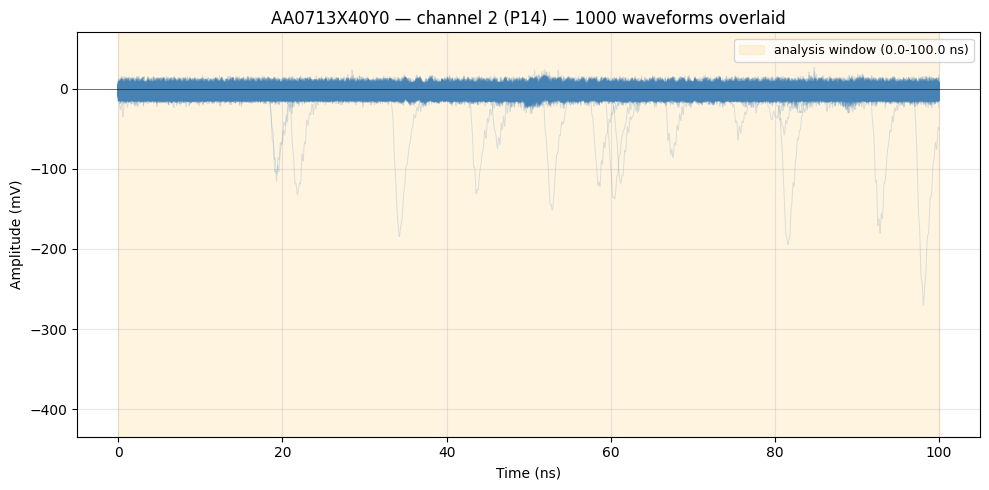


[AA0713X40Y0] channel 3 (P10): plotting 1000 waveforms
  plotted 1000 traces in 0.61s


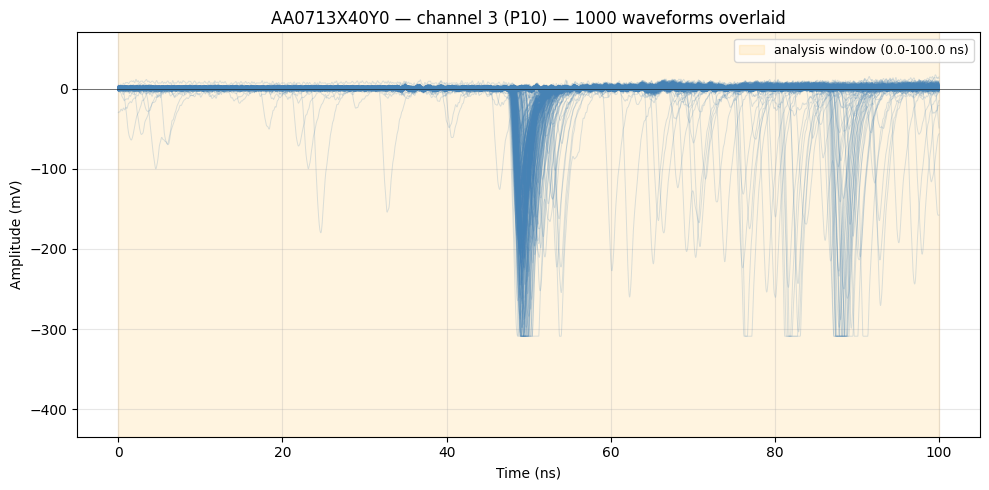


[AA0713X40Y0] channel 4 (P6): plotting 1000 waveforms
  plotted 1000 traces in 0.61s


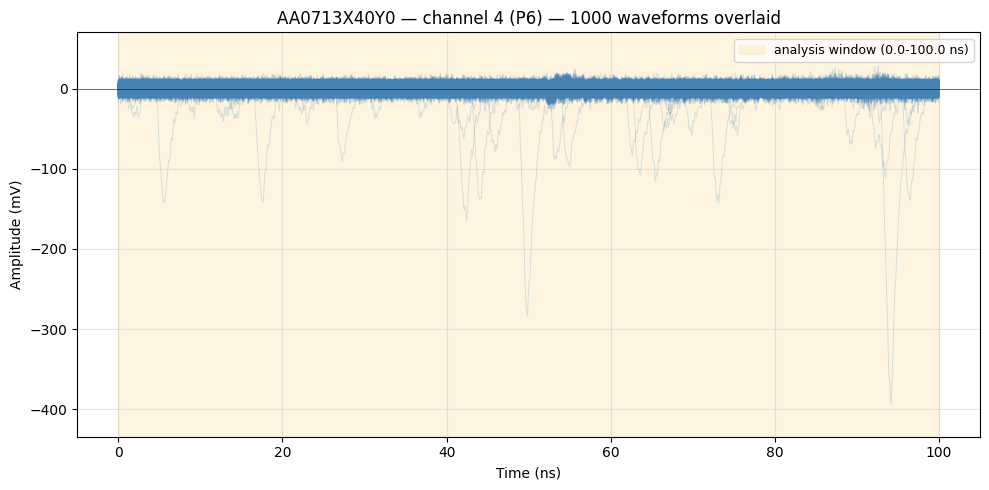

In [ ]:
# 06_plot_run_waveforms_stacked.py — Drop-in cell for Jupyter
#
# For ONE run (i.e. one step/position, e.g. AA0710X40Y0), plots ALL waveforms
# for each channel overlaid on top of each other, one separate figure per channel.
# With 3 signal channels -> 3 figures (trigger channel optionally included too,
# see INCLUDE_TRIGGER below).
#
# SHARED Y-SCALE: all three figures use the SAME y-axis range so you can visually
# compare pulse size/noise floor across channels directly (a pad sitting at -5mV
# noise should visibly look "smaller" than one with a -30mV pulse, not just have
# a different auto-scaled axis that hides the difference). The range is NOT
# hardcoded -- it's computed from whichever channel actually has the largest
# deflection IN THIS RUN, since which pad is "on" the beam changes with position.
# This means all three channels' data is loaded up front (one pass) before any
# figure is drawn, so the range can be computed first.
#
# HONEST LIMITATION: a real step can have 1000+ events. Plotting that many raw
# lines on one axes is slow AND becomes an illegible solid smear well before you
# hit the true count. This script does NOT silently subsample your data behind
# your back -- it plots everything by default, but:
#   - uses low alpha so overlapping traces show density rather than a flat block
#   - warns loudly in the console if event count exceeds a threshold where
#     rendering will be slow / not obviously useful, so you're not confused
#     about why it's taking a while
#   - lets you optionally set MAX_TRACES to a number if you actually want a
#     faster/lighter plot (None = plot all, no cap)

import os
import glob
import re
import time
import numpy as np
import matplotlib.pyplot as plt

# -------- CONFIG --------
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260730X"  # <-- must match 01_analyze_hrppd_ph.py
RUN_PREFIX  = "AA0730X"
STEP        = 40          # <-- which step/position to plo0
Y_FIXED     = 0            # this is a 1D scan; Y is fixed at this value for every step.
                            # Run naming is AA0715X{STEP}Y{Y_FIXED}, e.g. AA0715X40Y0.
EXT         = ".wfm"

TRIGGER_CHANNEL = 1
SIGNAL_CHANNELS = {2: "P14", 3: "P10", 4: "P6"}   # scope channel -> label
INCLUDE_TRIGGER = False    # True to also get a 4th figure for the trigger/sync channel

TIME_WINDOW_NS = (0.0, 100.0)   # shaded band showing the analysis window, for reference
PLOT_FULL_TRACE = False          # True: show full waveform. False: crop to TIME_WINDOW_NS only.

MAX_TRACES = 1000   # None = plot every event found. Set an integer (e.g. 300) to cap
                     # how many traces are drawn per channel, taken as an evenly-spaced
                     # sample across the run (not just the first N) so you still see
                     # the full run's variability rather than one time-ordered chunk.

ALPHA = 0.2         # per-trace transparency; lower = better density visualization
                     # when there are many overlapping traces
LARGE_RUN_WARNING_THRESHOLD = 500   # console warning if more traces than this are plotted

# --- Shared y-scale config ---
SHARED_YSCALE = True   # True: all 3 (or 4) figures use the same y-range, taken from
                        # whichever channel has the largest pulse in this run.
                        # False: each figure auto-scales independently (old behavior).
YSCALE_PADDING_FRAC = 0.1   # extra headroom above/below the observed min/max, as a
                             # fraction of the range, so pulses aren't flush against
                             # the plot edge
# -------------------------


def read_cached(wfm_path):
    d = os.path.dirname(wfm_path)
    base = os.path.splitext(os.path.basename(wfm_path))[0]
    cp = os.path.join(d, "CACHE", f"{base}.npz")
    if not os.path.exists(cp):
        raise RuntimeError(
            f"No cache found for {wfm_path}. Run 01_analyze_hrppd_ph.py with "
            f"CACHE_ONLY=False at least once to build the .npz cache first."
        )
    with np.load(cp, allow_pickle=False) as z:
        return z["t"], z["v"]


def build_channel_index(dname, run, ch):
    patt = os.path.join(dname, f"{run}_ch{ch}_*{EXT}")
    paths = glob.glob(patt)
    entries = []
    for p in paths:
        s = os.path.splitext(os.path.basename(p))[0]
        m = re.match(rf".*_ch{ch}_(\d+)$", s, flags=re.IGNORECASE)
        if not m:
            continue
        entries.append((int(m.group(1)), p))
    entries.sort(key=lambda x: x[0])
    return entries


def get_files_for_channel(run, ch):
    """All files for this run/channel, sorted by timestamp (i.e. acquisition order)."""
    idx = build_channel_index(DATA_DIR, run, ch)
    return [p for _, p in idx]


def subsample_evenly(items, max_n):
    if max_n is None or len(items) <= max_n:
        return items
    idxs = np.linspace(0, len(items) - 1, max_n).round().astype(int)
    idxs = sorted(set(idxs))
    return [items[i] for i in idxs]


def load_traces_for_channel(files_to_plot):
    """Read every trace once; return list of (t, v) so we don't re-read from disk
    twice (once to find the shared scale, once to actually plot)."""
    traces = []
    n_failed = 0
    for p in files_to_plot:
        try:
            t, v = read_cached(p)
        except RuntimeError:
            n_failed += 1
            continue
        t = np.asarray(t).squeeze()
        v = np.asarray(v).squeeze()
        if not PLOT_FULL_TRACE:
            m = (t >= TIME_WINDOW_NS[0]) & (t <= TIME_WINDOW_NS[1])
            t, v = t[m], v[m]
        traces.append((t, v))
    return traces, n_failed


def compute_yrange(all_channel_traces, padding_frac):
    """all_channel_traces: dict of label -> list of (t, v). Finds the global
    min/max across every channel/trace so the largest real pulse (whichever
    channel it's on) sets the scale for ALL figures."""
    global_min = np.inf
    global_max = -np.inf
    for label, traces in all_channel_traces.items():
        for t, v in traces:
            if v.size == 0 or not np.any(np.isfinite(v)):
                continue
            global_min = min(global_min, float(np.nanmin(v)))
            global_max = max(global_max, float(np.nanmax(v)))

    if not np.isfinite(global_min) or not np.isfinite(global_max):
        return None  # no valid data at all

    span = global_max - global_min
    if span <= 0:
        span = 1.0  # degenerate guard (all-flat data)
    pad = span * padding_frac
    return (global_min - pad, global_max + pad)


def plot_channel(run, ch, label, traces, y_range):
    n_plot = len(traces)
    print(f"[{run}] channel {ch} ({label}): plotting {n_plot} waveforms")

    if n_plot == 0:
        print(f"  WARNING: no traces available for channel {ch} -- skipping this figure")
        return

    t0 = time.time()
    fig, ax = plt.subplots(figsize=(10, 5))

    for t, v in traces:
        ax.plot(t, v, color="steelblue", alpha=ALPHA, linewidth=0.7)

    ax.axvspan(TIME_WINDOW_NS[0], TIME_WINDOW_NS[1], color="orange", alpha=0.12,
               label=f"analysis window ({TIME_WINDOW_NS[0]}-{TIME_WINDOW_NS[1]} ns)")
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)

    if y_range is not None:
        ax.set_ylim(y_range)

    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Amplitude (mV)")
    title_suffix = "" if y_range is not None else ""
    ax.set_title(f"{run} — channel {ch} ({label}) — {n_plot} waveforms overlaid{title_suffix}")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

    fig.tight_layout()
    elapsed = time.time() - t0
    print(f"  plotted {n_plot} traces in {elapsed:.2f}s")
    plt.show()


def main():
    run = f"{RUN_PREFIX}{STEP}Y{Y_FIXED}"
    # run = f"{RUN_PREFIX}{STEP}"
    print(f"Plotting stacked waveforms for run: {run}")
    print("=" * 70)

    channels_to_plot = dict(SIGNAL_CHANNELS)
    if INCLUDE_TRIGGER:
        channels_to_plot[TRIGGER_CHANNEL] = "TRIG"

    # ---- Pass 1: load every channel's traces up front (needed to compute a
    # shared y-scale across all of them before drawing any single figure) ----
    all_traces = {}
    for ch, label in channels_to_plot.items():
        files = get_files_for_channel(run, ch)
        n_found = len(files)
        print(f"[{run}] channel {ch} ({label}): found {n_found} waveform files")

        files_to_plot = subsample_evenly(files, MAX_TRACES)
        if MAX_TRACES is not None and len(files_to_plot) < n_found:
            print(f"  MAX_TRACES={MAX_TRACES} set -> using {len(files_to_plot)} of {n_found} "
                  f"(evenly sampled across the run)")
        elif len(files_to_plot) > LARGE_RUN_WARNING_THRESHOLD:
            print(f"  NOTE: loading all {len(files_to_plot)} traces (MAX_TRACES=None). "
                  f"This may be slow. Set MAX_TRACES to an integer above to cap it.")

        traces, n_failed = load_traces_for_channel(files_to_plot)
        all_traces[label] = traces
        if n_failed > 0:
            print(f"  WARNING: {n_failed} files had no cache and were skipped "
                  f"(re-run 01_analyze_hrppd_ph.py with CACHE_ONLY=False to build missing cache)")

    print()

    # ---- Compute shared y-range across ALL channels (or None if disabled) ----
    y_range = None
    if SHARED_YSCALE:
        y_range = compute_yrange(all_traces, YSCALE_PADDING_FRAC)
        if y_range is not None:
            # Report which channel actually drove the range, so it's clear WHY
            # the scale is what it is (e.g. "P9 has the pulse here, so P13/P5
            # -- which are just noise at this position -- will look flat").
            driving_label, driving_extreme = None, 0.0
            for label, traces in all_traces.items():
                for t, v in traces:
                    if v.size == 0:
                        continue
                    local_extreme = max(abs(np.nanmax(v)), abs(np.nanmin(v)))
                    if local_extreme > driving_extreme:
                        driving_extreme = local_extreme
                        driving_label = label
            print(f"Shared y-range: {y_range[0]:.2f} to {y_range[1]:.2f} mV "
                  f"(driven by channel '{driving_label}', largest deflection ~{driving_extreme:.2f} mV)")
        else:
            print("Could not compute a shared y-range (no valid data found in any channel)")
        print()

    # ---- Pass 2: draw each figure using the pre-loaded traces + shared range ----
    for ch, label in channels_to_plot.items():
        plot_channel(run, ch, label, all_traces[label], y_range)
        print()


if __name__ == "__main__":
    main()

### Waveform Baseline Oscillation Investigation - Histogram

Run: AA0710X40Y0, channel 4 (P6)
Found 1297 waveform files
Using 1000 waveforms (evenly sampled)
Computed window-mean for 1000 waveforms
Pooled 375000 individual samples across all 1000 waveforms (~375 samples/waveform)
Histogram 1: 499500 pairwise differences (1000 waveforms -> 1000*(1000-1)/2 = 499500 pairs)
Histogram 2: 1000 values (one per waveform)


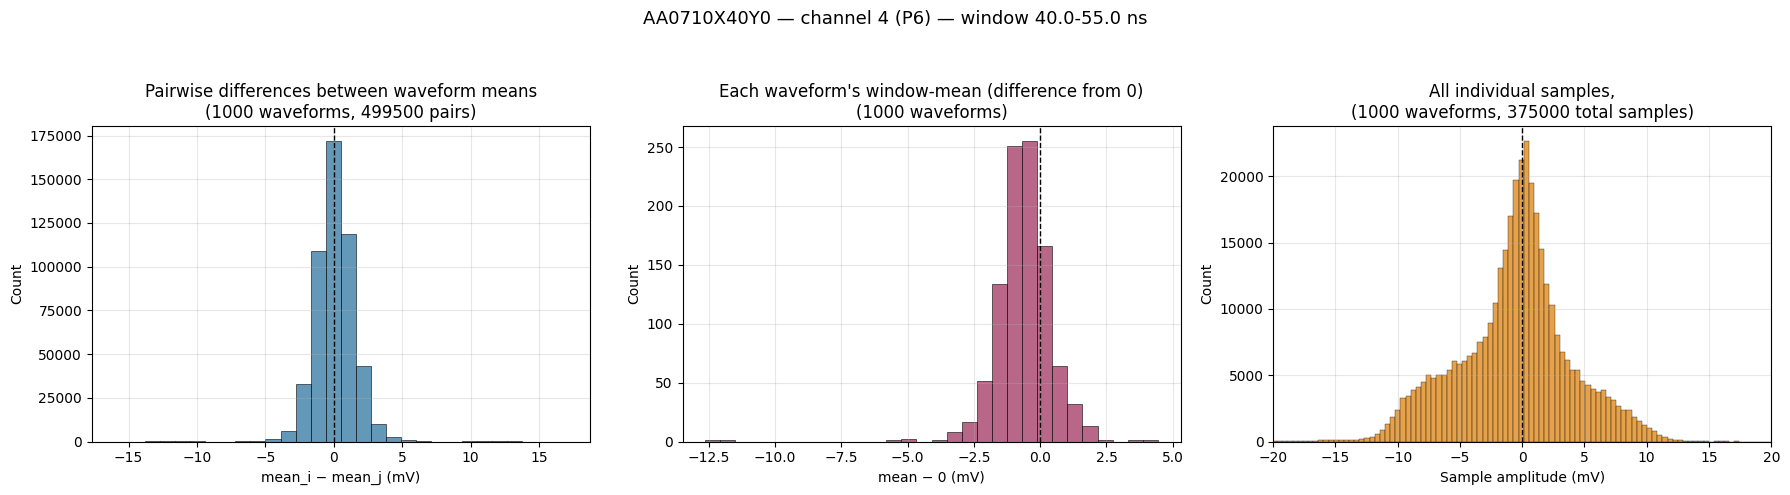


Histogram 2 stats: mean=-0.620 mV, std=1.085 mV
Histogram 1 stats: mean=0.088 mV (should be ~0 by construction), std=1.531 mV
Histogram 3 stats: mean=-0.620 mV, std=4.719 mV, min=-109.219 mV, max=22.813 mV


In [ ]:
# 07_ph_window_mean_histograms.py — Drop-in cell for Jupyter
#
# For ONE run/step and ONE channel, loads N waveforms (cropped to the analysis
# window, 40-55ns by default), and produces THREE histograms:
#
#   Histogram 1: ALL PAIRWISE differences between waveform means.
#                With N waveforms, this is N*(N-1)/2 values (e.g. N=20 -> 190
#                pairs): mean_1 - mean_2, mean_1 - mean_3, ..., mean_19 - mean_20.
#                Shows how much waveforms disagree with EACH OTHER, not just
#                with a group average (which could itself be skewed by outliers).
#
#   Histogram 2: each waveform's window-mean minus ZERO (i.e. just the raw
#                window-mean values themselves). Shows whether the analysis
#                window sits centered on 0mV on average, or is systematically
#                offset -- this is the "difference w.r.t. zero" you asked for.
#
#   Histogram 3: EVERY INDIVIDUAL SAMPLE from every loaded waveform, pooled
#                into one histogram (e.g. 20 waveforms x ~300 samples/waveform
#                in a 15ns window at typical scope sample rates = thousands of
#                points). This is a DIFFERENT question from histograms 1/2:
#                those summarize each waveform down to ONE number (its mean)
#                first; this one skips that step and shows the full raw
#                amplitude distribution across all samples, all waveforms,
#                mixed together. If a real pulse is present in the window for
#                some/all waveforms, this histogram will show it as a
#                second bump/tail on the negative side, not just a single
#                noise-like peak -- unlike histograms 1/2, which only see the
#                per-waveform MEAN and can partially wash out a brief pulse.
#
# NOTE ON SCOPE: mean/samples are computed over the FULL 40-55ns window, which
# includes the pulse itself if one is present at this step/channel. That's
# what you asked for ("just the analysis window"). If you meant the mean of
# ONLY the noisy/pulse-free part of that window, this will look different --
# say so and I'll adjust (e.g. exclude samples below some threshold).

import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# -------- CONFIG --------
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260710X"  # <-- must match your other scripts
RUN_PREFIX  = "AA0710X"
STEP        = 40
Y_FIXED     = 0
EXT         = ".wfm"

CHANNEL     = 4          # scope channel number to analyze (e.g. 3 = P10 per your latest channel map)
CHANNEL_LABEL = "P6"    # just for plot titles

TIME_WINDOW_NS = (40.0, 55.0)   # mean/samples computed over this window -- must match your analysis window

N_WAVEFORMS = 1000   # how many waveforms to use (evenly sampled across the run, not just the first N)

BINS = 30
BINS_SAMPLES = 320   # separate bin count for histogram 3, since it usually has far more points
                     # than histograms 1/2 and can support finer binning
# -------------------------


def read_cached(wfm_path):
    d = os.path.dirname(wfm_path)
    base = os.path.splitext(os.path.basename(wfm_path))[0]
    cp = os.path.join(d, "CACHE", f"{base}.npz")
    if not os.path.exists(cp):
        raise RuntimeError(f"No cache found for {wfm_path}")
    with np.load(cp, allow_pickle=False) as z:
        return z["t"], z["v"]


def build_channel_index(dname, run, ch):
    patt = os.path.join(dname, f"{run}_ch{ch}_*{EXT}")
    paths = glob.glob(patt)
    entries = []
    for p in paths:
        s = os.path.splitext(os.path.basename(p))[0]
        m = re.match(rf".*_ch{ch}_(\d+)$", s, flags=re.IGNORECASE)
        if not m:
            continue
        entries.append((int(m.group(1)), p))
    entries.sort(key=lambda x: x[0])
    return [p for _, p in entries]


def subsample_evenly(items, max_n):
    if max_n is None or len(items) <= max_n:
        return items
    idxs = np.linspace(0, len(items) - 1, max_n).round().astype(int)
    idxs = sorted(set(idxs))
    return [items[i] for i in idxs]


def crop_window(t, v, tmin, tmax):
    t = np.asarray(t).squeeze()
    v = np.asarray(v).squeeze()
    n = min(t.size, v.size)
    t, v = t[:n], v[:n]
    m = (t >= tmin) & (t <= tmax)
    if not np.any(m):
        return None
    return v[m]


def main():
    run = f"{RUN_PREFIX}{STEP}Y{Y_FIXED}"
    print(f"Run: {run}, channel {CHANNEL} ({CHANNEL_LABEL})")

    files = build_channel_index(DATA_DIR, run, CHANNEL)
    n_found = len(files)
    print(f"Found {n_found} waveform files")
    if n_found == 0:
        raise SystemExit("No files found -- check DATA_DIR/RUN_PREFIX/STEP/Y_FIXED/CHANNEL against your actual filenames.")

    files_to_use = subsample_evenly(files, N_WAVEFORMS)
    print(f"Using {len(files_to_use)} waveforms "
          f"({'all found' if len(files_to_use) == n_found else 'evenly sampled'})")

    # ---- compute each waveform's window-mean AND collect all individual samples ----
    means = []
    all_samples = []
    for p in files_to_use:
        t, v = read_cached(p)
        v_window = crop_window(t, v, TIME_WINDOW_NS[0], TIME_WINDOW_NS[1])
        if v_window is None or v_window.size == 0 or not np.any(np.isfinite(v_window)):
            continue
        means.append(float(np.nanmean(v_window)))
        all_samples.append(v_window[np.isfinite(v_window)])

    means = np.array(means)
    n = means.size
    all_samples = np.concatenate(all_samples) if len(all_samples) > 0 else np.array([])
    print(f"Computed window-mean for {n} waveforms")
    print(f"Pooled {all_samples.size} individual samples across all {n} waveforms "
          f"(~{all_samples.size / max(n,1):.0f} samples/waveform)")
    if n < 2:
        raise SystemExit("Need at least 2 waveforms with valid data to compute pairwise differences.")

    # ---- Histogram 1: all pairwise differences between waveform means ----
    pairwise_diffs = []
    for i in range(n):
        for j in range(i + 1, n):
            pairwise_diffs.append(means[i] - means[j])
    pairwise_diffs = np.array(pairwise_diffs)
    print(f"Histogram 1: {len(pairwise_diffs)} pairwise differences "
          f"({n} waveforms -> {n}*({n}-1)/2 = {n*(n-1)//2} pairs)")

    # ---- Histogram 2: each waveform's window-mean minus zero (i.e. the means themselves) ----
    diffs_from_zero = means - 0.0
    print(f"Histogram 2: {len(diffs_from_zero)} values (one per waveform)")

    # ---- Plot all three ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(pairwise_diffs, bins=BINS, color="#3d7ea6", alpha=0.8, edgecolor="black", linewidth=0.5)
    axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title(f"Pairwise differences between waveform means\n"
                       f"({n} waveforms, {len(pairwise_diffs)} pairs)")
    axes[0].set_xlabel("mean_i − mean_j (mV)")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3)

    axes[1].hist(diffs_from_zero, bins=BINS, color="#a6416b", alpha=0.8, edgecolor="black", linewidth=0.5)
    axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"Each waveform's window-mean (difference from 0)\n"
                       f"({n} waveforms)")
    axes[1].set_xlabel("mean − 0 (mV)")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.3)

    axes[2].hist(all_samples, bins=BINS_SAMPLES, color="#e08a1e", alpha=0.8, edgecolor="black", linewidth=0.3)
    axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[2].set_title(f"All individual samples,\n"
                       f"({n} waveforms, {all_samples.size} total samples)")
    axes[2].set_xlabel("Sample amplitude (mV)")
    axes[2].set_ylabel("Count")
    axes[2].set_xlim(-20, 20)
    axes[2].grid(alpha=0.3)

    fig.suptitle(f"{run} — channel {CHANNEL} ({CHANNEL_LABEL}) — window {TIME_WINDOW_NS[0]}-{TIME_WINDOW_NS[1]} ns",
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    print(f"\nHistogram 2 stats: mean={diffs_from_zero.mean():.3f} mV, "
          f"std={diffs_from_zero.std(ddof=1) if n > 1 else 0:.3f} mV")
    print(f"Histogram 1 stats: mean={pairwise_diffs.mean():.3f} mV "
          f"(should be ~0 by construction), std={pairwise_diffs.std(ddof=1):.3f} mV")
    if all_samples.size > 0:
        print(f"Histogram 3 stats: mean={all_samples.mean():.3f} mV, "
              f"std={all_samples.std(ddof=1):.3f} mV, "
              f"min={all_samples.min():.3f} mV, max={all_samples.max():.3f} mV")


if __name__ == "__main__":
    main()

### Per event Pulse Height Distribution

Loading: /home/matthew/Desktop/HRPPD/RESULTS/2026/AA0710X40Y0_results_260720.csv
n rows in CSV: 1297


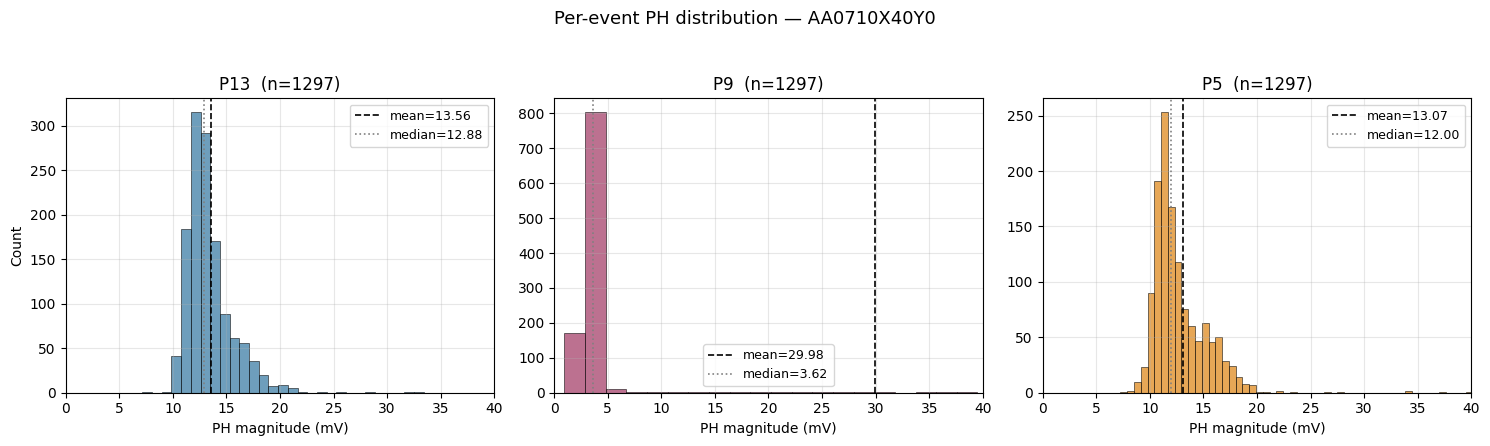


P13: mean=13.562 mV, median=12.875 mV, std=4.827 mV, n=1297
P9: mean=29.979 mV, median=3.621 mV, std=56.087 mV, n=1297
P5: mean=13.067 mV, median=12.000 mV, std=5.193 mV, n=1297


In [75]:
# 08_ph_histograms_from_csv.py — Drop-in cell for Jupyter
#
# Reads the per-event results CSV already saved by 01_analyze_hrppd_ph.py
# (the one with columns PH_P13, PH_P9, PH_P5, written per kept event) and plots
# one histogram PER CHANNEL, side by side, showing the actual extracted PH
# values (per-event single-sample magnitude) -- NOT the raw sample-pooled
# histogram from 07_ph_window_mean_histograms.py. These are different
# statistics (see prior discussion): this one is exactly what feeds the 1D
# PH-vs-position plot's mean/trimmed_mean, so it's the right thing to compare
# against that plot, not the raw-samples histogram.

import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- CONFIG --------
RESULTS_DIR = "/home/matthew/Desktop/HRPPD/RESULTS/2026"
RUN_PREFIX  = "AA0710X"
Y_FIXED     = 0
STEP        = 40          # <-- which step/position to look at

CHANNEL_LABELS = ["P13", "P9", "P5"]
CHANNEL_COLORS = {"P13": "#3d7ea6", "P9": "#a6416b", "P5": "#e08a1e"}

BINS = 160
X_MAX_MV = None   # set to a number (e.g. 50) to cap the x-axis/exclude extreme
                  # outliers from the view, same as your earlier distribution
                  # script did. None = show the full range as-is.
# -------------------------


def find_results_csv(run: str) -> str:
    pattern = os.path.join(RESULTS_DIR, f"{run}_results_*.csv")
    matches = sorted(glob.glob(pattern), key=os.path.getmtime)
    if not matches:
        raise FileNotFoundError(
            f"No per-event results CSV found matching {pattern}. "
            f"Make sure 01_analyze_hrppd_ph.py was run with WRITE_EVENTS=True "
            f"for step={STEP}, and that at least one event was KEPT for this step."
        )
    return matches[-1]


def main():
    run = f"{RUN_PREFIX}{STEP}Y{Y_FIXED}"
    csv_path = find_results_csv(run)
    print(f"Loading: {csv_path}")

    df = pd.read_csv(csv_path)
    print(f"n rows in CSV: {len(df)}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

    for ax, label in zip(axes, CHANNEL_LABELS):
        col = f"PH_{label}"
        if col not in df.columns:
            ax.set_title(f"{label} (column {col} not found)")
            print(f"WARNING: {col} not in CSV. Available columns: {list(df.columns)}")
            continue

        vals_all = df[col].to_numpy(float)
        vals_all = vals_all[np.isfinite(vals_all)]

        if X_MAX_MV is not None:
            n_excluded = int(np.sum(vals_all > X_MAX_MV))
            vals = vals_all[vals_all <= X_MAX_MV]
            hist_range = (0, X_MAX_MV)
        else:
            n_excluded = 0
            vals = vals_all
            hist_range = None

        ax.hist(vals, bins=BINS, range=hist_range, color=CHANNEL_COLORS.get(label, "gray"),
                alpha=0.75, edgecolor="black", linewidth=0.5)

        if vals.size > 0:
            mean_v = vals.mean()
            median_v = np.median(vals)
            ax.axvline(mean_v, color="black", linestyle="--", linewidth=1.2, label=f"mean={mean_v:.2f}")
            ax.axvline(median_v, color="gray", linestyle=":", linewidth=1.2, label=f"median={median_v:.2f}")
            ax.legend(fontsize=9)

        title = f"{label}  (n={vals.size}"
        if n_excluded > 0:
            title += f", {n_excluded} excl. >{X_MAX_MV:.0f}mV"
        title += ")"
        ax.set_title(title)
        ax.set_xlabel("PH magnitude (mV)")
        ax.set_xlim(left=0, right=40)
        if ax is axes[0]:
            ax.set_ylabel("Count")
        ax.grid(alpha=0.3)

    fig.suptitle(f"Per-event PH distribution — {run}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    print()
    for label in CHANNEL_LABELS:
        col = f"PH_{label}"
        if col in df.columns:
            vals = df[col].to_numpy(float)
            vals = vals[np.isfinite(vals)]
            if vals.size > 0:
                print(f"{label}: mean={vals.mean():.3f} mV, median={np.median(vals):.3f} mV, "
                      f"std={vals.std(ddof=1):.3f} mV, n={vals.size}")


if __name__ == "__main__":
    main()

Plotting stacked waveforms for run: AA0715X50
[AA0715X50] channel 2 (P14): found 2000 waveform files
  MAX_TRACES=1000 set -> using 1000 of 2000 (evenly sampled across the run)
[AA0715X50] channel 3 (P10): found 2000 waveform files
  MAX_TRACES=1000 set -> using 1000 of 2000 (evenly sampled across the run)
[AA0715X50] channel 4 (P6): found 2000 waveform files
  MAX_TRACES=1000 set -> using 1000 of 2000 (evenly sampled across the run)

Shared y-range: -240.27 to 47.24 mV (driven by channel 'P14', largest deflection ~216.31 mV)

[AA0715X50] channel 2 (P14): plotting 1000 waveforms
  plotted 1000 traces in 0.58s


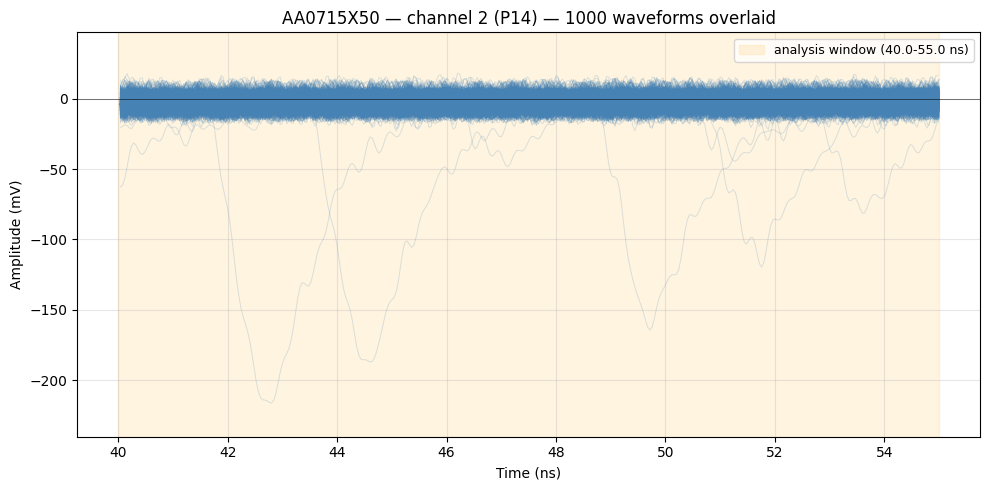


[AA0715X50] channel 3 (P10): plotting 1000 waveforms
  plotted 1000 traces in 0.46s


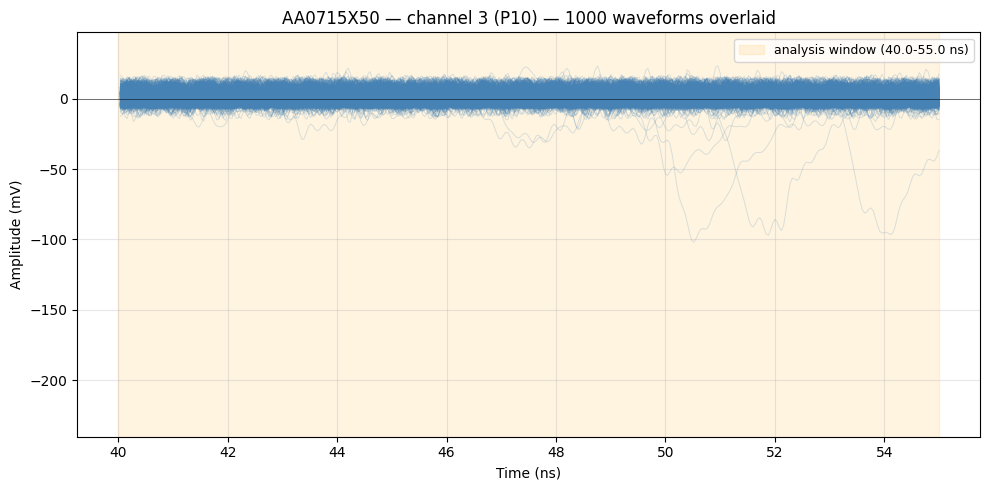


[AA0715X50] channel 4 (P6): plotting 1000 waveforms
  plotted 1000 traces in 0.48s


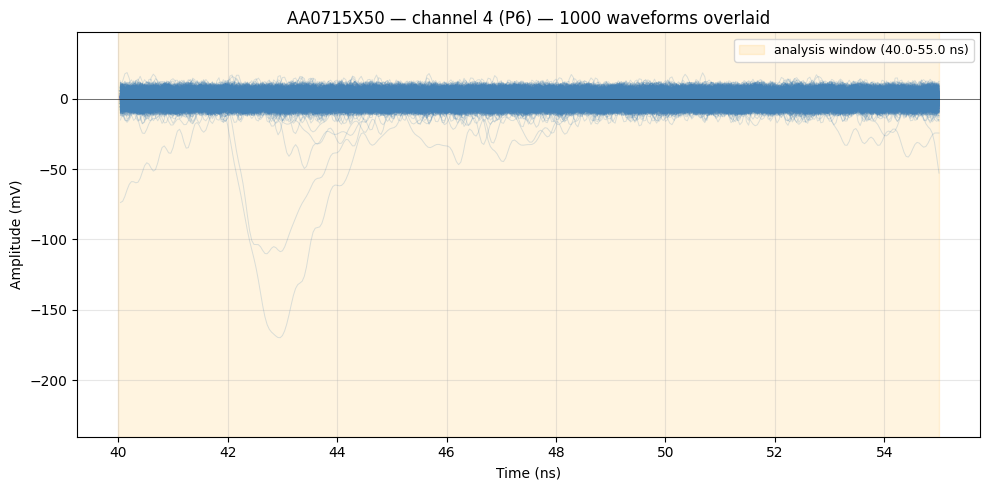

In [82]:
# 06_plot_run_waveforms_stacked.py — Drop-in cell for Jupyter
#
# For ONE run (i.e. one step/position, e.g. AA0710X40Y0), plots ALL waveforms
# for each channel overlaid on top of each other, one separate figure per channel.
# With 3 signal channels -> 3 figures (trigger channel optionally included too,
# see INCLUDE_TRIGGER below).
#
# SHARED Y-SCALE: all three figures use the SAME y-axis range so you can visually
# compare pulse size/noise floor across channels directly (a pad sitting at -5mV
# noise should visibly look "smaller" than one with a -30mV pulse, not just have
# a different auto-scaled axis that hides the difference). The range is NOT
# hardcoded -- it's computed from whichever channel actually has the largest
# deflection IN THIS RUN, since which pad is "on" the beam changes with position.
# This means all three channels' data is loaded up front (one pass) before any
# figure is drawn, so the range can be computed first.
#
# HONEST LIMITATION: a real step can have 1000+ events. Plotting that many raw
# lines on one axes is slow AND becomes an illegible solid smear well before you
# hit the true count. This script does NOT silently subsample your data behind
# your back -- it plots everything by default, but:
#   - uses low alpha so overlapping traces show density rather than a flat block
#   - warns loudly in the console if event count exceeds a threshold where
#     rendering will be slow / not obviously useful, so you're not confused
#     about why it's taking a while
#   - lets you optionally set MAX_TRACES to a number if you actually want a
#     faster/lighter plot (None = plot all, no cap)

import os
import glob
import re
import time
import numpy as np
import matplotlib.pyplot as plt

# -------- CONFIG --------
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260715"  # <-- must match 01_analyze_hrppd_ph.py
RUN_PREFIX  = "AA0715X"
STEP        = 50          # <-- which step/position to plo0
# Y_FIXED     = 0            # this is a 1D scan; Y is fixed at this value for every step.
                            # Run naming is AA0715X{STEP}Y{Y_FIXED}, e.g. AA0715X40Y0.
EXT         = ".wfm"

TRIGGER_CHANNEL = 1
SIGNAL_CHANNELS = {2: "P14", 3: "P10", 4: "P6"}   # scope channel -> label
INCLUDE_TRIGGER = False    # True to also get a 4th figure for the trigger/sync channel

TIME_WINDOW_NS = (40.0, 55.0)   # shaded band showing the analysis window, for reference
PLOT_FULL_TRACE = False          # True: show full waveform. False: crop to TIME_WINDOW_NS only.

MAX_TRACES = 1000   # None = plot every event found. Set an integer (e.g. 300) to cap
                     # how many traces are drawn per channel, taken as an evenly-spaced
                     # sample across the run (not just the first N) so you still see
                     # the full run's variability rather than one time-ordered chunk.

ALPHA = 0.2         # per-trace transparency; lower = better density visualization
                     # when there are many overlapping traces
LARGE_RUN_WARNING_THRESHOLD = 500   # console warning if more traces than this are plotted

# --- Shared y-scale config ---
SHARED_YSCALE = True   # True: all 3 (or 4) figures use the same y-range, taken from
                        # whichever channel has the largest pulse in this run.
                        # False: each figure auto-scales independently (old behavior).
YSCALE_PADDING_FRAC = 0.1   # extra headroom above/below the observed min/max, as a
                             # fraction of the range, so pulses aren't flush against
                             # the plot edge
# -------------------------


def read_cached(wfm_path):
    d = os.path.dirname(wfm_path)
    base = os.path.splitext(os.path.basename(wfm_path))[0]
    cp = os.path.join(d, "CACHE", f"{base}.npz")
    if not os.path.exists(cp):
        raise RuntimeError(
            f"No cache found for {wfm_path}. Run 01_analyze_hrppd_ph.py with "
            f"CACHE_ONLY=False at least once to build the .npz cache first."
        )
    with np.load(cp, allow_pickle=False) as z:
        return z["t"], z["v"]


def build_channel_index(dname, run, ch):
    patt = os.path.join(dname, f"{run}_ch{ch}_*{EXT}")
    paths = glob.glob(patt)
    entries = []
    for p in paths:
        s = os.path.splitext(os.path.basename(p))[0]
        m = re.match(rf".*_ch{ch}_(\d+)$", s, flags=re.IGNORECASE)
        if not m:
            continue
        entries.append((int(m.group(1)), p))
    entries.sort(key=lambda x: x[0])
    return entries


def get_files_for_channel(run, ch):
    """All files for this run/channel, sorted by timestamp (i.e. acquisition order)."""
    idx = build_channel_index(DATA_DIR, run, ch)
    return [p for _, p in idx]


def subsample_evenly(items, max_n):
    if max_n is None or len(items) <= max_n:
        return items
    idxs = np.linspace(0, len(items) - 1, max_n).round().astype(int)
    idxs = sorted(set(idxs))
    return [items[i] for i in idxs]


def load_traces_for_channel(files_to_plot):
    """Read every trace once; return list of (t, v) so we don't re-read from disk
    twice (once to find the shared scale, once to actually plot)."""
    traces = []
    n_failed = 0
    for p in files_to_plot:
        try:
            t, v = read_cached(p)
        except RuntimeError:
            n_failed += 1
            continue
        t = np.asarray(t).squeeze()
        v = np.asarray(v).squeeze()
        if not PLOT_FULL_TRACE:
            m = (t >= TIME_WINDOW_NS[0]) & (t <= TIME_WINDOW_NS[1])
            t, v = t[m], v[m]
        traces.append((t, v))
    return traces, n_failed


def compute_yrange(all_channel_traces, padding_frac):
    """all_channel_traces: dict of label -> list of (t, v). Finds the global
    min/max across every channel/trace so the largest real pulse (whichever
    channel it's on) sets the scale for ALL figures."""
    global_min = np.inf
    global_max = -np.inf
    for label, traces in all_channel_traces.items():
        for t, v in traces:
            if v.size == 0 or not np.any(np.isfinite(v)):
                continue
            global_min = min(global_min, float(np.nanmin(v)))
            global_max = max(global_max, float(np.nanmax(v)))

    if not np.isfinite(global_min) or not np.isfinite(global_max):
        return None  # no valid data at all

    span = global_max - global_min
    if span <= 0:
        span = 1.0  # degenerate guard (all-flat data)
    pad = span * padding_frac
    return (global_min - pad, global_max + pad)


def plot_channel(run, ch, label, traces, y_range):
    n_plot = len(traces)
    print(f"[{run}] channel {ch} ({label}): plotting {n_plot} waveforms")

    if n_plot == 0:
        print(f"  WARNING: no traces available for channel {ch} -- skipping this figure")
        return

    t0 = time.time()
    fig, ax = plt.subplots(figsize=(10, 5))

    for t, v in traces:
        ax.plot(t, v, color="steelblue", alpha=ALPHA, linewidth=0.7)

    ax.axvspan(TIME_WINDOW_NS[0], TIME_WINDOW_NS[1], color="orange", alpha=0.12,
               label=f"analysis window ({TIME_WINDOW_NS[0]}-{TIME_WINDOW_NS[1]} ns)")
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)

    if y_range is not None:
        ax.set_ylim(y_range)

    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Amplitude (mV)")
    title_suffix = "" if y_range is not None else ""
    ax.set_title(f"{run} — channel {ch} ({label}) — {n_plot} waveforms overlaid{title_suffix}")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

    fig.tight_layout()
    elapsed = time.time() - t0
    print(f"  plotted {n_plot} traces in {elapsed:.2f}s")
    plt.show()


def main():
    # run = f"{RUN_PREFIX}{STEP}Y{Y_FIXED}"
    run = f"{RUN_PREFIX}{STEP}"
    # run = f"{RUN_PREFIX}{STEP}"
    print(f"Plotting stacked waveforms for run: {run}")
    print("=" * 70)

    channels_to_plot = dict(SIGNAL_CHANNELS)
    if INCLUDE_TRIGGER:
        channels_to_plot[TRIGGER_CHANNEL] = "TRIG"

    # ---- Pass 1: load every channel's traces up front (needed to compute a
    # shared y-scale across all of them before drawing any single figure) ----
    all_traces = {}
    for ch, label in channels_to_plot.items():
        files = get_files_for_channel(run, ch)
        n_found = len(files)
        print(f"[{run}] channel {ch} ({label}): found {n_found} waveform files")

        files_to_plot = subsample_evenly(files, MAX_TRACES)
        if MAX_TRACES is not None and len(files_to_plot) < n_found:
            print(f"  MAX_TRACES={MAX_TRACES} set -> using {len(files_to_plot)} of {n_found} "
                  f"(evenly sampled across the run)")
        elif len(files_to_plot) > LARGE_RUN_WARNING_THRESHOLD:
            print(f"  NOTE: loading all {len(files_to_plot)} traces (MAX_TRACES=None). "
                  f"This may be slow. Set MAX_TRACES to an integer above to cap it.")

        traces, n_failed = load_traces_for_channel(files_to_plot)
        all_traces[label] = traces
        if n_failed > 0:
            print(f"  WARNING: {n_failed} files had no cache and were skipped "
                  f"(re-run 01_analyze_hrppd_ph.py with CACHE_ONLY=False to build missing cache)")

    print()

    # ---- Compute shared y-range across ALL channels (or None if disabled) ----
    y_range = None
    if SHARED_YSCALE:
        y_range = compute_yrange(all_traces, YSCALE_PADDING_FRAC)
        if y_range is not None:
            # Report which channel actually drove the range, so it's clear WHY
            # the scale is what it is (e.g. "P9 has the pulse here, so P13/P5
            # -- which are just noise at this position -- will look flat").
            driving_label, driving_extreme = None, 0.0
            for label, traces in all_traces.items():
                for t, v in traces:
                    if v.size == 0:
                        continue
                    local_extreme = max(abs(np.nanmax(v)), abs(np.nanmin(v)))
                    if local_extreme > driving_extreme:
                        driving_extreme = local_extreme
                        driving_label = label
            print(f"Shared y-range: {y_range[0]:.2f} to {y_range[1]:.2f} mV "
                  f"(driven by channel '{driving_label}', largest deflection ~{driving_extreme:.2f} mV)")
        else:
            print("Could not compute a shared y-range (no valid data found in any channel)")
        print()

    # ---- Pass 2: draw each figure using the pre-loaded traces + shared range ----
    for ch, label in channels_to_plot.items():
        plot_channel(run, ch, label, all_traces[label], y_range)
        print()


if __name__ == "__main__":
    main()

### FCCee HRPPD Brainstorm

# A Photon-Counting Timing Layer for FCC-ee
### Where LAPPD/HRPPD technology has a defensible, unclaimed slot — and where it does not

*Working document. Prepared July 2026. Intended for internal discussion and circulation to colleagues.*

---

## 0. Executive summary — the one-sentence claim

> **FCC-ee flavour physics gains roughly an order of magnitude in misidentification background when per-track time-of-flight resolution crosses below ~10 ps. No silicon technology reaches 10 ps per track. A Cherenkov-photon-counting timing layer does, and it requires a fast, low-dark-rate, magnetic-field-tolerant, large-area single-photon vacuum photodetector — which is exactly what HRPPD is.**

That is the entire pitch. Everything below is either evidence for it, engineering to realise it, or honest accounting of what could kill it.

**What this proposal is NOT:** it is not "HRPPD is a better sensor than SiPM." On raw specification HRPPD *loses* to SiPM on cost per unit area and on pixel pitch, and *loses* to LGAD on material budget. If the pitch is framed as a sensor beauty contest, it will be dismissed in one meeting. The pitch must be framed as a **capability threshold with documented physics value that only one technology can cross.**

---

## 1. State of play: what is actually decided at FCC-ee (as of mid-2026)

Facts, not impressions:

| Item | Status |
|---|---|
| FCC-ee endorsed as preferred next flagship | Yes — European Strategy update, recommended by CERN Council May 2026; construction decision ~2028 |
| Detector concepts | **Five**: ALLEGRO, CLD, IDEA, ILD@FCC-ee, and ALFA (newly emerged, very thin documentation) |
| Timeline (from 9th FCC Physics Workshop, Garching, Jan 2026) | Optimisation studies → 2027; **system demonstrators ~2030**; scalable prototypes early 2030s; **CDRs 2033** |
| Solenoid field | **2 T** in CLD, IDEA, ALLEGRO — limited by machine-detector-interface constraints, *not* 3–4 T |
| Dedicated PID sub-detector | **None is in any baseline.** All concepts currently rely on tracker-derived PID |
| Only PID sub-detector with a formal EOI | **ARC** (Array of RICH Cells), DRD4 WP3 task 4 |

Two of these deserve emphasis because they are commonly gotten wrong:

**(a) The field is 2 T, not 3 T.** This materially changes the MCP-PMT risk assessment. Published LAPPD measurements go to ~1.5 T (CERN MNP-17 / M113 dipoles); HRPPD was *designed* against a 2–3 T target with 10 µm pores and a 1.1 mm photocathode gap. 2 T is at the edge of demonstrated territory, not beyond it. If anyone tells you MCPs are disqualified by the FCC-ee field, they are working from a 4 T CLIC-era number.

**(b) No concept has claimed the timing slot.** IDEA's stated plan is TOF "either by LGAD technologies in the Si wrapper or by a first layer of LYSO crystals in the ECAL." Both are ~30–50 ps devices. That is a placeholder, and it is a placeholder chosen to satisfy a requirement (~100 ps) that is now known to be far below the useful ceiling. This is the opening.

---

## 2. The physics argument, with the actual numbers

### 2.1 The paper that makes this proposal possible

**Beck & Smith, arXiv:2511.17447** (MIT, Nov 2025), *"Flavour-physics benchmarks for tracker-based particle identification at the FCC-ee."* Full Geant4 simulation of CLD and IDEA, BDT-based π/K/p identification, three flavour benchmarks. Read this first, twice.

The findings that matter:

1. **Same-side B⁰ₛ flavour tagging** (very low momentum kaons): needs σ_ToF ≲ 30–50 ps to be useful. Achievable with silicon. *Not our argument.*

2. **Rare b→s decays** (medium momentum — B⁰ₛ→K⁺K⁻ℓℓ, B⁰→K⁻π⁺ℓℓ, Λ⁰_b→pK⁻ℓℓ): at IDEA, dN/dx alone already suppresses contamination by >1 order of magnitude. Then, in their words: *additional time-of-flight information improves on a purely dN/dx-based classifier by an order of magnitude for resolutions below 10 ps.* At CLD, a further order-of-magnitude reduction requires 30–50 ps or better.

3. **s-jet tagging** (H→ss̄, momenta >10 GeV/c): time-of-flight is useless at any realistic resolution. Only dN/dx or a RICH helps. *Do not claim this region.*

4. Their closing line is an open invitation: *"the benefits to flavour-physics analyses in the presence of a dedicated particle-identification system should be ascertained in future studies."*

**The 10 ps number is the hinge of this entire proposal.** It is not our number, it is not INCOM's number, and it is not a detector-builder's aspiration. It comes from an independent full-simulation flavour-physics study by people with no stake in photodetectors. That is why it will survive a review committee.

### 2.2 What 10 ps buys, computed from scratch

For a flight path *L* and momentum *p*, the K–π arrival-time difference is

    Δt = (L/c)·[ √(1 + m_K²/p²) − √(1 + m_π²/p²) ]  →  (L/c)·(m_K² − m_π²)/(2p²)  for p ≫ m

With **L = 2.0 m** (IDEA drift chamber outer radius = 200 cm; CLD tracking radius = 210 cm, half-length 220 cm — so L ≈ 2.0–2.2 m at essentially all polar angles):

    Δt(K,π) ≈ 748 / p²  ps   (p in GeV/c)

| p (GeV/c) | Δt(K,π) | σ_t needed for 3σ |
|---|---|---|
| 1 | 704 ps | 235 ps |
| 2 | 184 ps | 61 ps |
| 3 | 82 ps | 27 ps |
| 5 | 30 ps | **10 ps** |
| 7 | 15 ps | 5 ps |
| 10 | 7.5 ps | 2.5 ps |

Inverting — **3σ π/K reach over a 2 m path**:

| σ_t (per track) | π/K 3σ reach | K/p 3σ reach | Technology that gets there |
|---|---|---|---|
| 100 ps | 1.6 GeV/c | 2.7 GeV/c | anything |
| 50 ps | 2.2 GeV/c | 3.8 GeV/c | LGAD, single layer |
| 30 ps | 2.9 GeV/c | 4.9 GeV/c | LGAD / AC-LGAD, LYSO+SiPM — **the current FCC-ee baseline ceiling** |
| 20 ps | 3.5 GeV/c | 5.9 GeV/c | multi-layer LGAD, optimistic |
| **10 ps** | **5.0 GeV/c** | **8.4 GeV/c** | **Cherenkov photon counting only** |
| 5 ps | 7.1 GeV/c | 11.9 GeV/c | Cherenkov photon counting, direct mode |
| 3 ps | 9.1 GeV/c | 15.3 GeV/c | aspirational |

Note the shape of this table. Between 30 ps and 10 ps the π/K reach nearly doubles, and this is precisely the interval Beck & Smith identify as worth an order of magnitude in rare-decay contamination. **The FCC-ee baseline sits on the wrong side of that line, and silicon cannot cross it.** A per-track resolution of 10 ps requires either an implausible number of LGAD layers or a fundamentally different measurement — counting many prompt Cherenkov photons.

### 2.3 Why silicon cannot get to 10 ps, stated precisely

An LGAD's single-hit resolution is set by Landau fluctuations in the ~50 µm gain layer and is floored around 25–30 ps; a few layers in coincidence give ~20 ps per track at best, at the cost of material in the tracking volume. There is no roadmap to 10 ps.

A photon-counting device has a completely different scaling: σ_track = σ_γ/√N ⊕ (correlated terms). With N ≈ 30 detected Cherenkov photons and σ_γ = 55 ps, σ_track ≈ 10 ps. With N ≈ 35 and no propagation dispersion, σ_track ≈ 4 ps. **The 1/√N is the whole trick, and it requires single-photon sensitivity with tens-of-ps transit-time spread — i.e. an MCP-PMT.**

### 2.4 Where NOT to plant the flag (be honest about these)

Three arguments look attractive and are weaker than they appear. Say them only with the caveats attached.

- **"The 0.85–1.05 GeV/c dN/dx crossover hole."** Real — it is documented in the IDEA drift-chamber literature and visible as dips in Beck & Smith's AUC-vs-momentum plots. But the stated requirement to patch it is *~100 ps ToF*. An LGAD does that trivially and for less money. **Do not lead with this.** It is a nice free extra, not a justification.

- **"The endcap dN/dx collapse."** Partly overstated, including in my own earlier framing of it. Running the geometry: at θ = 18° a track crosses ~0.97 m of the drift chamber versus 1.65 m at 90° — a √-scaling degradation of ~30% in separation power, not a collapse. dN/dx genuinely dies only below θ ≈ 11°, i.e. |cos θ| > 0.98, which is ~2% of solid angle per side. **The endcap argument is thin. Use it as a secondary benefit, not a pillar.** Note also that the flight path at the endcap is *longer* than the barrel (L ≈ 2.2 m at |cos θ| = 0.95), which helps a timing layer independently of any dN/dx deficit.

- **"SiPMs will be radiation-damaged."** True at LHC and EIC, **false at FCC-ee.** The FCC-ee environment is benign; this removes the SiPM's single biggest liability. Anyone who pitches HRPPD at FCC-ee on radiation-hardness grounds is arguing an LHC case in an e⁺e⁻ room and will be corrected in public. The anti-SiPM case at FCC-ee rests on dark count rate, cooling infrastructure, UV reach, and single-photon timing — nothing else.

---

## 3. The concrete detector proposal

### 3.1 Two operating modes

**Mode A — Direct ("window Cherenkov") TOF.** A charged track crosses the HRPPD's own fused-silica entrance window at near-normal incidence and radiates Cherenkov photons directly onto the photocathode deposited on the window's inner face. Zero propagation distance ⇒ **no chromatic time dispersion, no emission-point ambiguity**. The only terms left are the sensor TTS and electronics.

Photon budget for a 5 mm fused-silica window, β ≈ 1, n ≈ 1.47:
- sin²θ_c = 1 − 1/n² = 0.537
- Effective figure of merit for a bialkali photocathode on fused silica, PDE ≈ 20% over an effective ~2.5 eV band: N₀ ≈ 370 × 0.5 ≈ 185 cm⁻¹
- N_pe ≈ 185 × 0.50 cm × 0.537 × 0.75 (active-area fraction) ≈ **35 photoelectrons**
- With σ_SPE ≈ 20 ps (measured on HRPPD15 at nominal HV): **σ_track ≈ 20/√35 ≈ 3.4 ps**, realistically ~5 ps with electronics and systematics

The photons land in a ring of radius ≈ d·tanθ_c ≈ 5.4 mm around the track — spread over a handful of 3.25 mm pixels, so the same hit also yields a position measurement. ePIC's pfRICH already anticipates this effect ("the photosensors also function as timing detectors"); **nobody has proposed it as a dedicated FCC-ee timing layer.**

*Design subtlety worth flagging in any talk, because a good referee will raise it:* photons at θ_c = 47° exceed the silica→vacuum critical angle (42.9°), so they would be totally internally reflected at a bare surface. They are not, because the photocathode is deposited directly on the inner face and absorbs them; oblique incidence in fact lengthens the path through the photocathode film and tends to *raise* effective QE. This needs a proper optical simulation to quantify, and quantifying it is a publishable result in itself.

**Mode B — Light-guiding (TORCH/DIRC-style) plate.** A ~10 mm fused-silica plate; Cherenkov photons propagate by total internal reflection to the plate periphery, are focused by a cylindrical mirror in a quartz block, and are imaged onto HRPPDs at the edge. Adds chromatic dispersion and emission-point uncertainty, so σ_γ ≈ 50–70 ps and σ_track ≈ 10–15 ps.

### 3.2 Why Mode B must be the deployment concept — the cost arithmetic that decides it

The barrel surface at r = 2 m over L = 4 m is **≈ 50 m²**.

- Mode A at full coverage: 50 m² / 0.0108 m² per HRPPD ≈ **4,600 devices**. At even $10k each, ~$46M in sensors alone. **This is dead on arrival.** State this yourself before someone else does.
- Mode B: sensors only along the plate edges. LHCb TORCH achieves ~45× area leverage (≈ 0.4 m² of MCP for ≈ 18 m² of radiator). Scaling to 50 m²: **≈ 1–2 m² of sensor, i.e. ~100–200 HRPPDs, ~$1–2M.**

That factor of ~40 in sensor area is the single answer to the standard objection — *"MCP-PMTs cost too much per unit area"* — which is exactly how MCPs were dismissed in the 2021 FCC-ee PID review. **The geometry, not the sensor price, is what makes MCP-PMTs affordable at FCC-ee.** Do not argue that HRPPDs are cheap. Argue that a light-guiding radiator means you barely need any.

### 3.3 A second, quieter advantage of Mode B: field orientation

In a barrel plate, photons travel along ±z to the plate ends, so the MCP stack axis points along **z — parallel to the solenoid field**. Axial field is the *favourable* orientation for an MCP-PMT: photoelectrons spiral along field lines across the short photocathode gap rather than being swept sideways. This is the configuration in which Belle II's TOP counter operates 32 MCP-PMTs successfully at 1.5 T.

An endcap disc has photons travelling radially, i.e. sensor axis perpendicular to **B** — the unfavourable case. It is solvable with optical folding (a prism or mirror to reorient the sensor), but it is extra design work and must be costed honestly. **This is an argument for prioritising the barrel.**

### 3.4 Material budget — the objection that will actually hurt

A 10 mm fused-silica plate is **0.081 X₀** (X₀ = 12.3 cm for SiO₂). At r = 2 m in IDEA, that sits directly in front of the crystal dual-readout ECAL, whose entire value proposition is precision electromagnetic energy resolution. The calorimetry group will fight this, and they will not be being unreasonable.

Honest mitigations, in order of strength:
1. **Thin the plate to 5 mm** (0.041 X₀). Halves the photon yield, so σ_track degrades as √2 — from ~10 to ~14 ps. This trade-off must be simulated, not asserted.
2. **Target CLD and ALLEGRO first**, where the coil sits outside the HCAL and the radial layout between tracker and calorimeter is less contested than in IDEA.
3. Note that IDEA already accepts a Si wrapper *and* a μ-RWELL preshower in front of the ECAL, so the precedent for material in that envelope exists. This is a weaker argument — use it last.
4. For comparison, ARC's own EOI targets 20 cm of radial thickness and <10% X₀. **A 5–10 mm quartz plate is a factor 20 thinner and comparable or better in X₀.** This is a genuinely strong comparative point.

### 3.5 Which concept to target

| Concept | Tracker PID | Deficit | Fit for a 10 ps timing layer |
|---|---|---|---|
| **CLD** | All-silicon; no dN/dx at all | Severe — fails at high p entirely, needs ≤30 ps to be useful at all | **Strongest.** Already the host for ARC in simulation. A 10 ps layer + ARC = full coverage |
| **ALLEGRO** | Shares IDEA drift chamber (dN/dx) | Moderate | Strong; coil outside HCAL eases integration |
| **IDEA** | dN/dx over full range | Modest — the incremental order of magnitude in rare decays | Good physics case, hardest integration fight |
| **ILD@FCC-ee** | TPC dE/dx | Moderate | Untested; TPC endplate integration unclear |
| **ALFA** | Essentially undocumented | Unknown | **Do not spend time here.** No public design to attach to |

**Recommendation: lead with CLD, keep ALLEGRO warm, engage IDEA on the physics case rather than the integration.**

---

## 4. The second route in: HRPPD as the vacuum-photodetector option for ARC

This is lower-risk, faster, and gets you inside an existing collaboration with an existing EOI and an existing prototype programme. Run it in parallel with §3.

### 4.1 What ARC is, and what its own EOI admits

ARC (Cardinale, Tolosa-Delgado, Forty, Kreps, Malde, Pezzulo, Wilkinson — Genova/INFN, CERN, Oxford, Warwick; EOI Feb 2025): a cellular array of compact dual-radiator RICH cells, aerogel + C₄F₁₀ gas, spherical mirror, SiPM readout. Target 20 cm radial envelope, <10% X₀. Delivers **3σ π/K over 2–40 GeV/c**, K/p from ~20 GeV/c with gas. Embedded in DRD4 as WP3 task 4. Three-year goal: prototype and validate one cell.

The EOI lists its own R&D challenges. Read them carefully, because two of them are openings:

1. *"The simulation assumes a C₄F₁₀ gas radiator at atmospheric pressure. On the timescale of FCC this is unlikely to be viable due to a ban on these types of gases."* — **ARC's baseline radiator is expected to be illegal.** (C₄F₁₀ GWP ≈ 7000–8500.)
2. *"The final design goal for photodetectors would be SiPM's, with 0.5×0.5 mm pixel size, and integrated electronics, and high efficiency. Such devices are not yet available although there is significant activity in this area."* — **ARC's baseline sensor does not exist yet.**
3. *"The photodetector housing module for SiPM requires a compact and lightweight integrated cooling solution."* — because SiPM dark count rate at room temperature is 10–100 kHz/mm², ARC must run its sensors cold (ΔT ~70 K) and uses the aerogel as a thermal barrier between the cryogenic sensor plane and the gas radiator.

### 4.2 The head-to-head, honestly scored

| Parameter | Cooled SiPM (ARC baseline) | HRPPD (DC-coupled, EIC generation) | Winner |
|---|---|---|---|
| Dark count rate | 10–100 kHz/mm² at 300 K → needs cooling to ~−45 °C | **<1.8 kHz/cm² = 0.018 kHz/mm²** at gain 5×10⁶ | **HRPPD by 10³–10⁴** |
| Cooling infrastructure | CO₂ cooling plate, ceramic 2.5D integration, aerogel thermal barrier, condensation control | **None** | **HRPPD** |
| PDE | 40–60% peak | **17.1 ± 0.1(stat) ± 0.3(sys) % at 398.6 nm** (measured, BNL) — QE 24.4%, collection efficiency 70.3% | **SiPM, decisively** |
| Pixel pitch | 0.5 mm goal (not yet available) | 3.25 mm as built | **SiPM** |
| UV reach | Cut off ~300 nm by window/epoxy | **Fused silica → ~165–200 nm** | **HRPPD** |
| SPE timing | 50–100 ps | **<20 ps** (HRPPD15, 775 V bias, 200 V PC) | **HRPPD** |
| Cost per unit area | Low | High | **SiPM** |
| B-field at 2 T | Immune | Gain and PDE degrade; partial recovery via bias | **SiPM** |
| Maturity for this application | Target device not yet available | 7 devices built and qualified for EIC; baseline for ePIC pfRICH | **HRPPD** |
| Afterpulsing | N/A (correlated noise instead) | <2.8% at gain 5×10⁶ | — |

**Read that table honestly. It is not a rout.** PDE and pixel pitch are real losses, and PDE matters enormously in a photon-starved 20 cm radiator. But two things are worth pressing:

- **The pixel-pitch loss is not fundamental.** HRPPD anodes are separately fabricated multilayer ceramic structures; the 3.25 mm pitch is a design choice, not an MCP physics limit. The intrinsic charge-cloud size from 10 µm pores across ~1 mm gaps is sub-millimetre. **Whether a finer HRPPD anode pitch is usable is an open, measurable question — and it maps exactly onto DRD4 WP4.2.3, "VPD time and spatial resolution performance."** This is your existing thesis work, pointed at an FCC-ee deliverable.
- **UV reach partially offsets the PDE deficit.** Cherenkov yield goes as ∫dλ/λ². Extending the band from a 300 nm cutoff down to ~200 nm adds substantial photons from a *gas* radiator (though not from aerogel, where Rayleigh scattering ∝ λ⁻⁴ kills the UV). The net photon-yield comparison for an ARC cell is a simulation study nobody has done. **Doing it is a paper and a seat at the table.**

### 4.3 What to actually propose to ARC

Not "replace your sensor." Propose: **"a quantitative vacuum-photodetector risk-mitigation study for the ARC cell,"** delivering a photon-yield-and-resolution comparison of cooled SiPM vs. HRPPD in the existing ARC DD4hep/Gaudi simulation framework, with HRPPD parameters taken from measured bench data rather than datasheets. Framed as risk mitigation against a sensor that does not yet exist, this is very hard to refuse — and ePIC's hpDIRC has already established the precedent of carrying DC-coupled HRPPD as the mitigation option against commercial MCP-PMTs.

---

## 5. Risk register — write this slide yourself before someone writes it for you

| # | Risk | Severity | Honest status | Mitigation / what to measure |
|---|---|---|---|---|
| 1 | **Gain and PDE loss at 2 T** | **Critical** | LAPPD gain falls exponentially to 1.5 T with mild angular dependence; gain and PDE only *partially* recovered by raising bias (Agarwala et al., NIMA 1072 (2025) 170122). HRPPDs recently tested at CERN and BNL — "no show-stoppers" for pfRICH, but **no published 2 T HRPPD curve exists** | **Measure and publish an HRPPD 2 T characterisation.** This is the single highest-value thing you can do. See §6 |
| 2 | Timing at 2 T — does σ_SPE survive? | High | Essentially unmeasured for HRPPD | Same campaign as #1. σ_t(B, θ_B) is the observable that decides the whole proposal |
| 3 | Cost per unit area | High if Mode A, low if Mode B | Real | The ~40× area leverage of a light-guiding radiator. Lead with the geometry |
| 4 | Material budget in front of ECAL | High | Real, and the calorimetry groups are right to push | 5 mm plate; target CLD/ALLEGRO; compare against ARC's 20 cm envelope |
| 5 | Pixel pitch 3.25 mm vs ARC's 0.5 mm | High (for §4 only) | Real | Anode is a design variable; measure achievable position resolution and charge sharing |
| 6 | Photocathode lifetime / integrated anode charge | **Low — argue this actively** | ALD-coated MCPs degrade above ~20 C/cm²; PANDA requires 5 C/cm² at LHC-like rates. FCC-ee rates are orders of magnitude lower | Do the FCC-ee integrated-charge calculation explicitly. This is a place where FCC-ee is *friendlier* than EIC or LHCb — one of your few free wins |
| 7 | Radiation damage | Low | FCC-ee is benign | Do not build any argument on this, in either direction |
| 8 | **The t₀ problem** | Medium, and underappreciated | Beck & Smith deliberately use first-to-last silicon hit precisely because it "does not rely on assumptions regarding the FCC-ee clock resolution." **The collision time reference at FCC-ee is an acknowledged open question** | See §7 — this is a genuinely unclaimed niche and a natural first hardware contribution |
| 9 | Rate capability | Low | HRPPD designed for 200 kHz/cm²; FCC-ee Z-pole photon rates are far below this | Straightforward occupancy calculation |
| 10 | Someone else gets there first | Medium | LAPPD/HRPPD appear in the Cherenkov-imaging synergy table for ePIC, ALICE3, LHCb and Belle II — but **the FCC row is empty.** That will not stay true indefinitely | Move in 2026, not 2028 |

---

## 6. The work plan — what you can deliver, in order of value per unit effort

The organising principle: **measurements land now; sub-detector concepts land in 2033.** Your fastest route to being taken seriously is not a concept paper. It is being the person who owns a number that the FCC-ee community needs and does not have.

### Phase 0 — Immediate, on your existing bench, no beam time, no new hardware (2–4 months)

**Deliverable: σ_t versus N_pe for an HRPPD, from single-photon to ~50 photoelectrons.**

This is the measurement that converts the whole proposal from arithmetic into evidence, and you already have every piece of apparatus required: PiLas 405 nm picosecond laser with calibrated ND filters, MSO64B, HRPPD, and a working Poisson-based single-photoelectron calibration.

Method:
1. Walk ⟨n⟩ from ~0.1 to ~50 pe using the ND filter set, with ⟨n⟩ established by Poisson statistics from the response/no-response fraction (the method you already use).
2. At each ⟨n⟩, extract σ_t against the laser sync reference using constant-fraction discrimination.
3. Plot σ_t vs N_pe and fit σ_t = σ_SPE/√N ⊕ σ_floor.
4. Identify σ_floor and its origin — laser jitter, sync jitter, scope timebase, MCP transit-time variation across the illuminated pore ensemble.

**Why this is the right first move:** if you can show σ_t(N ≈ 20–35) ≈ 4–6 ps on a real device, you have directly demonstrated the capability that Beck & Smith identify as worth an order of magnitude in rare-decay background, on the very technology in question. That is a short, self-contained, highly citable NIMA or JINST paper. It cannot be waved away as simulation. And it is, so far as the published literature shows, **not yet done for HRPPD.**

Watch out for the floor. Your sync-corrected two-channel result of ~47.5 ps suggests your current floor is well above 5 ps; identifying and beating it is most of the actual work, and characterising it honestly is part of the paper. If the floor turns out to be ~20 ps and immovable with your present setup, say so — a well-characterised limit is still a result, and it tells the community what readout development is needed.

### Phase 1 — Simulation, in the FCC-ee framework (3–6 months, overlapping)

**Deliverable: the Beck & Smith study, extended to a dedicated timing layer.** They explicitly flagged this as future work; that is an invitation, not a coincidence.

1. Get into Key4hep / k4geo / DD4hep. Use the FCC full-simulation tutorial as the entry point — CLD, ALLEGRO and IDEA geometries are centrally available.
2. Implement a thin fused-silica timing layer in the CLD geometry: 5 mm and 10 mm variants, r = 2.0 m, barrel plus endcap disc.
3. Parametrise σ_track from **your Phase 0 measurement**, not from a datasheet. This is the whole point — it is what makes the study yours and not a repetition.
4. Rerun their three benchmarks (same-side B⁰ₛ tagging, rare b→s, s-jet tagging) and quantify the gain at σ_track = 5, 10, 15 ps against the 30 ps silicon baseline.
5. Include the material-budget penalty on ECAL resolution honestly. If it costs 3% on the electromagnetic resolution, report 3%. A proposal that reports its own costs is trusted; one that omits them is discounted entirely.

Beck and Smith are at MIT and acknowledge the "MIT and friends FCC-ee" meeting series; Eluned Smith is LHCb. Given your US LHCb connection, an email proposing exactly this extension is a reasonable and well-motivated first contact.

### Phase 2 — The magnetic field campaign (12–18 months, needs a partner)

**Deliverable: gain, PDE and σ_SPE versus |B| and orientation angle for an HRPPD, up to 2 T.**

You almost certainly cannot do this at Syracuse. You do not need to — you need a collaborator with a magnet, and there are two obvious ones, both of whom have already done the LAPPD version:

- **INFN Trieste** — Tessarotto, Chatterjee, Agarwala, Dalla Torre, Levorato. They performed the LAPPD magnetic-field measurements on CERN's MNP-17 and M113 dipoles, are inside DRD4, and Chatterjee wrote the 2026 Cherenkov-imaging review. They are the single most natural partner for this entire programme.
- **Argonne** — Junqi Xie's group, longstanding MCP-PMT development, LAPPD/HRPPD magnetic-field tests, and a 10×10 cm MCP-PMT fabrication facility. Domestic, and a shorter path for a US student.

Also relevant: **BNL** (Kiselev, Jin, Stoll, Azmoun, Page, Woody, Purschke) own the pfRICH programme and the absolute-PDE measurement, and INCOM (Lyashenko, Minot, Popecki, Hamel) is already your vendor contact — a genuine advantage most people proposing this would not have.

Frame the ask as: *"we have HRPPD characterisation infrastructure and a specific FCC-ee physics case that requires 2 T data; can we join your next magnet campaign?"* Bring the Phase 0 result as your entry ticket.

### Phase 3 — Formal collaboration (parallel with all of the above, start now)

1. **Join DRD4.** 74 institutes, 19 countries, CERN as host. Coordinators Christian Joram (CERN) and Peter Križan (JSI Ljubljana); Massimiliano Fiorini (INFN Ferrara) reports status to the DRDC. Your work maps onto:
   - **WG1** (Photon Detectors — vacuum and solid state) — natural home
   - **WP4.2.3** — *"VPD time and spatial resolution performance"* — this is a literal description of your thesis
   - **WP4.2.1** — VPD longevity and rate capability
   - **WP3 / WP4** — RICH concepts and Time-of-Flight systems
   
   DRD4 was approved in December 2023 for an initial, extendable three-year term. **The renewal cycle is a natural moment to add scope and institutes; do not miss it.**
   
2. **Contact the ARC proponents** with the §4.3 framing. Roberta Cardinale (Genova/INFN) and Sneha Malde (Oxford) are the named contact authors.

3. **Submit an Expression of Interest for a timing sub-detector concept.** The ARC EOI is three pages and is your template. The FCC workshop in Garching explicitly encouraged further concept proposals. An EOI backed by one measured result and one simulation study is a credible document; one backed by neither is noise.

---

## 7. A smaller, unclaimed niche worth knowing about: the t₀ problem

Every time-of-flight measurement needs a start time. Beck & Smith sidestep it by using first-hit-to-last-hit within the silicon, explicitly noting this avoids assumptions about the FCC-ee clock resolution. That is a workaround, and it costs you: it shortens the effective lever arm and it fails for particles from displaced vertices — which is to say, it fails for exactly the b-hadron decay products the flavour programme cares about.

At Z-pole operation with ~10⁴ bunches and tens-of-ns spacing, a **picosecond-level collision-time reference** would be genuinely valuable and is, as far as I can find, unclaimed. A small LAPPD or HRPPD viewing prompt Cherenkov light from a thin quartz radiator in the forward region is a plausible instrument for it.

Why this is worth keeping in your pocket: it is small, cheap, technically tractable, needs no space in the contested tracking volume, and nobody owns it. If the big proposal stalls on material budget or cost, this is a second door into the same building. It also puts you in contact with the machine-detector-interface community rather than only the PID community, which broadens your base.

I have not verified this against a detailed FCC-ee timing-distribution design, so treat it as a lead to check rather than an established gap — but check it.

---

## 8. Reading list, in the order I would read it

**Tier 1 — read these before writing anything**

1. **arXiv:2511.17447** — Beck & Smith, *Flavour-physics benchmarks for tracker-based PID at the FCC-ee.* The 10 ps number. Your foundation.
2. **arXiv:2602.12853** — Chatterjee, *R&D Efforts in Cherenkov Imaging Technologies for PID in Future Experiments* (2026). The complete competitive map. Table 1 is the synergy matrix — note that the FCC row lists aerogel, gas and SiPM but **not** LAPPD/HRPPD.
3. **arXiv:2505.10658** — Lyashenko et al., *HRPPD photosensors for RICH detectors with high resolution timing capability.* The seven EIC HRPPDs: QE >30%, DCR <1.8 kHz/cm², APF <2.8%, σ_SPE <20 ps, 1.1 mm photocathode gap.
4. **ARC EOI**, Cardinale et al., Feb 2025 — three pages, and the "Challenges" section is the most useful text in this entire list.
5. **arXiv:2106.01253** — Forty & Wilkinson, *Particle Identification at FCC-ee.* The paper that dismissed MCP-PMTs on 0.7 T tolerance and cost per unit area. **Know this argument cold, because it is the one you must overturn**, and note that its MCP reference predates both HRPPD and Belle II TOP operational experience.

**Tier 2 — the technology**

6. **NIMA 1072 (2025) 170122** — Agarwala et al., *Performance of an LAPPD in magnetic fields.* Your risk #1, stated by the people who measured it.
7. **arXiv:2506.16490** — Jin, Kiselev, Stoll, *Absolute single-photon detection efficiency of HRPPD.* PDE = 17.1%, collection efficiency 70.3%. Use these numbers, not datasheet QE.
8. **arXiv:2505.00272** — *FCC Feasibility Study Report Vol. 1.* Section 6.7 is PID; Section 4.5 the physics motivation.
9. **arXiv:2502.21223** — *The IDEA detector concept for FCC-ee.* Note the TOF sentence: "either LGAD technologies in the Si wrapper or a first layer of LYSO crystals in the ECAL."
10. **arXiv:1911.12230** — *CLD — A Detector Concept for the FCC-ee.* Geometry and the 2 T rationale.
11. **NIMA 1058 (2024) 168937** — Bhattacharya et al., *Characterization of LAPPD timing at CERN PS testbeam.* 80 ps in beam. Understand the gap between this and 20 ps on a bench.
12. **NIMA 1050 (2023) 168181** — Bhasin et al., *Performance of a prototype TORCH time-of-flight detector.* 70 ps per photon demonstrated; the reference design for Mode B.

**Tier 3 — context and comparison**

13. **arXiv:2509.21883** — cluster counting beam tests; the dN/dx 0.85–1.05 GeV/c gap and combined dN/dx+ToF performance.
14. **arXiv:2310.05267** — Harnew, *ECFA Roadmap Process for PID and Photon Detector R&D.* Source of the SiPM 10–100 kHz/mm² dark-rate figure and the cooling requirement.
15. **DRD4 proposal**, CDS 2884872 — the work-package structure, so you can name WP4.2.3 correctly in an email.
16. **arXiv:2506.02675** and **arXiv:2502.04071** — FCC-ee vertex detector reviews; useful for the surrounding geometry constraints.
17. **CERN Courier, "Garching gathers for the FCC"** (Feb 2026) — the five concepts, the timeline, and the explicit encouragement of new concept proposals.

---

## 9. How to pitch this, and how not to

**Say:**
- "Independent full-simulation flavour studies show an order of magnitude in rare-decay background rejection at σ_ToF below 10 ps. Silicon does not reach 10 ps. Photon counting does. Here is a measurement of what a real HRPPD delivers."
- "A light-guiding radiator gives ~40× area leverage, so 50 m² of coverage needs 1–2 m² of sensor. Cost per unit area is not the binding constraint if the geometry is right."
- "This is risk mitigation for ARC's photodetector plane, which the ARC EOI itself notes does not yet exist."
- "Here is the material budget cost, and here is what it does to ECAL resolution."

**Do not say:**
- "HRPPD is better than SiPM." It is not, on PDE, pitch, or cost. You will be corrected.
- "SiPMs will be radiation damaged." Not at FCC-ee.
- "MCP-PMTs work fine in magnetic fields." They do not work *fine* at 2 T; they degrade, and recovery via bias is partial. Say that first, then say you are going to measure it.
- Anything about ALFA. There is nothing to attach to.
- "This fills the 0.85–1.05 GeV/c gap." True but cheap — an LGAD does it for less.

**The posture that works:** arrive with one measured number nobody else has, one simulation study that an existing paper explicitly invited, and a risk register you wrote yourself. That is how a single student from a group with two detectors on the bench becomes indispensable to a 74-institute collaboration.

---

## 10. What I am least sure about

Stated plainly so you can check rather than inherit my errors:

1. **The Mode A photon budget (~35 pe from 5 mm)** uses a hand-estimated effective ∫PDE·dE ≈ 0.5 eV. This could easily be off by ±40%, which moves σ_track by ±20%. It needs a proper wavelength-resolved calculation with the measured HRPPD PDE curve and the fused-silica transmission. Do this before quoting 5 ps to anyone.
2. **The oblique-incidence photocathode absorption** beyond the critical angle is physically sound but I have not found a quantitative HRPPD-specific treatment. Simulate it.
3. **Whether σ_t really scales as 1/√N down to a few ps in a real HRPPD** is the central unverified assumption of the whole proposal. Correlated terms — MCP pore-to-pore transit variation, anode crosstalk, HV ripple — may impose a floor well above 5 ps. This is precisely why Phase 0 comes first, and why you should be prepared for the answer to be less good than the arithmetic.
4. **The t₀ niche (§7)** is a lead I have not fully verified against FCC-ee timing-system design documents.
5. **The HRPPD 2 T behaviour** is the one thing nobody knows, including INCOM. If it turns out gain recovery at 2 T is not achievable within a viable HV envelope, Mode A dies and Mode B survives only because its sensors sit in the favourable axial orientation. Know this branch point in advance.

## Testing

### Samples Histogram Distribution

Run: AA0715X50, channel 4 (P6)
Found 2000 waveform files
Using 1000 waveforms (evenly sampled)
Computed window-mean for 1000 waveforms
Pooled 375000 individual samples across all 1000 waveforms (~375 samples/waveform)
Histogram 1: 499500 pairwise differences (1000 waveforms -> 1000*(1000-1)/2 = 499500 pairs)
Histogram 2: 1000 values (one per waveform)


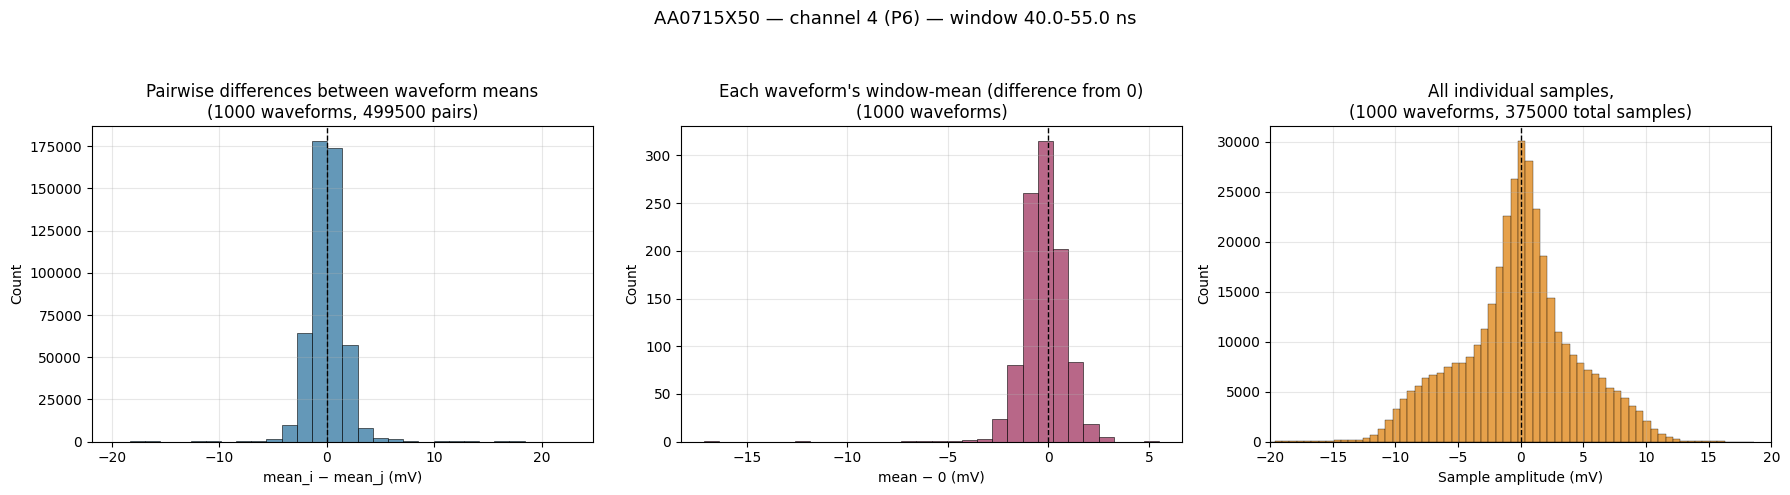


Histogram 2 stats: mean=-0.250 mV, std=1.220 mV
Histogram 1 stats: mean=0.045 mV (should be ~0 by construction), std=1.725 mV
Histogram 3 stats: mean=-0.250 mV, std=4.945 mV, min=-169.844 mV, max=18.625 mV


In [89]:
# 07_ph_window_mean_histograms.py — Drop-in cell for Jupyter
#
# For ONE run/step and ONE channel, loads N waveforms (cropped to the analysis
# window, 40-55ns by default), and produces THREE histograms:
#
#   Histogram 1: ALL PAIRWISE differences between waveform means.
#                With N waveforms, this is N*(N-1)/2 values (e.g. N=20 -> 190
#                pairs): mean_1 - mean_2, mean_1 - mean_3, ..., mean_19 - mean_20.
#                Shows how much waveforms disagree with EACH OTHER, not just
#                with a group average (which could itself be skewed by outliers).
#
#   Histogram 2: each waveform's window-mean minus ZERO (i.e. just the raw
#                window-mean values themselves). Shows whether the analysis
#                window sits centered on 0mV on average, or is systematically
#                offset -- this is the "difference w.r.t. zero" you asked for.
#
#   Histogram 3: EVERY INDIVIDUAL SAMPLE from every loaded waveform, pooled
#                into one histogram (e.g. 20 waveforms x ~300 samples/waveform
#                in a 15ns window at typical scope sample rates = thousands of
#                points). This is a DIFFERENT question from histograms 1/2:
#                those summarize each waveform down to ONE number (its mean)
#                first; this one skips that step and shows the full raw
#                amplitude distribution across all samples, all waveforms,
#                mixed together. If a real pulse is present in the window for
#                some/all waveforms, this histogram will show it as a
#                second bump/tail on the negative side, not just a single
#                noise-like peak -- unlike histograms 1/2, which only see the
#                per-waveform MEAN and can partially wash out a brief pulse.
#
# NOTE ON SCOPE: mean/samples are computed over the FULL 40-55ns window, which
# includes the pulse itself if one is present at this step/channel. That's
# what you asked for ("just the analysis window"). If you meant the mean of
# ONLY the noisy/pulse-free part of that window, this will look different --
# say so and I'll adjust (e.g. exclude samples below some threshold).

import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# -------- CONFIG --------
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260715"  # <-- must match your other scripts
RUN_PREFIX  = "AA0715X"
STEP        = 50
# Y_FIXED     = 0
EXT         = ".wfm"

CHANNEL     = 4          # scope channel number to analyze (e.g. 3 = P10 per your latest channel map)
CHANNEL_LABEL = "P6"    # just for plot titles

TIME_WINDOW_NS = (40.0, 55.0)   # mean/samples computed over this window -- must match your analysis window

N_WAVEFORMS = 1000   # how many waveforms to use (evenly sampled across the run, not just the first N)

BINS = 30
BINS_SAMPLES = 320   # separate bin count for histogram 3, since it usually has far more points
                     # than histograms 1/2 and can support finer binning
# -------------------------


def read_cached(wfm_path):
    d = os.path.dirname(wfm_path)
    base = os.path.splitext(os.path.basename(wfm_path))[0]
    cp = os.path.join(d, "CACHE", f"{base}.npz")
    if not os.path.exists(cp):
        raise RuntimeError(f"No cache found for {wfm_path}")
    with np.load(cp, allow_pickle=False) as z:
        return z["t"], z["v"]


def build_channel_index(dname, run, ch):
    patt = os.path.join(dname, f"{run}_ch{ch}_*{EXT}")
    paths = glob.glob(patt)
    entries = []
    for p in paths:
        s = os.path.splitext(os.path.basename(p))[0]
        m = re.match(rf".*_ch{ch}_(\d+)$", s, flags=re.IGNORECASE)
        if not m:
            continue
        entries.append((int(m.group(1)), p))
    entries.sort(key=lambda x: x[0])
    return [p for _, p in entries]


def subsample_evenly(items, max_n):
    if max_n is None or len(items) <= max_n:
        return items
    idxs = np.linspace(0, len(items) - 1, max_n).round().astype(int)
    idxs = sorted(set(idxs))
    return [items[i] for i in idxs]


def crop_window(t, v, tmin, tmax):
    t = np.asarray(t).squeeze()
    v = np.asarray(v).squeeze()
    n = min(t.size, v.size)
    t, v = t[:n], v[:n]
    m = (t >= tmin) & (t <= tmax)
    if not np.any(m):
        return None
    return v[m]


def main():
    run = f"{RUN_PREFIX}{STEP}"
    print(f"Run: {run}, channel {CHANNEL} ({CHANNEL_LABEL})")

    files = build_channel_index(DATA_DIR, run, CHANNEL)
    n_found = len(files)
    print(f"Found {n_found} waveform files")
    if n_found == 0:
        raise SystemExit("No files found -- check DATA_DIR/RUN_PREFIX/STEP/Y_FIXED/CHANNEL against your actual filenames.")

    files_to_use = subsample_evenly(files, N_WAVEFORMS)
    print(f"Using {len(files_to_use)} waveforms "
          f"({'all found' if len(files_to_use) == n_found else 'evenly sampled'})")

    # ---- compute each waveform's window-mean AND collect all individual samples ----
    means = []
    all_samples = []
    for p in files_to_use:
        t, v = read_cached(p)
        v_window = crop_window(t, v, TIME_WINDOW_NS[0], TIME_WINDOW_NS[1])
        if v_window is None or v_window.size == 0 or not np.any(np.isfinite(v_window)):
            continue
        means.append(float(np.nanmean(v_window)))
        all_samples.append(v_window[np.isfinite(v_window)])

    means = np.array(means)
    n = means.size
    all_samples = np.concatenate(all_samples) if len(all_samples) > 0 else np.array([])
    print(f"Computed window-mean for {n} waveforms")
    print(f"Pooled {all_samples.size} individual samples across all {n} waveforms "
          f"(~{all_samples.size / max(n,1):.0f} samples/waveform)")
    if n < 2:
        raise SystemExit("Need at least 2 waveforms with valid data to compute pairwise differences.")

    # ---- Histogram 1: all pairwise differences between waveform means ----
    pairwise_diffs = []
    for i in range(n):
        for j in range(i + 1, n):
            pairwise_diffs.append(means[i] - means[j])
    pairwise_diffs = np.array(pairwise_diffs)
    print(f"Histogram 1: {len(pairwise_diffs)} pairwise differences "
          f"({n} waveforms -> {n}*({n}-1)/2 = {n*(n-1)//2} pairs)")

    # ---- Histogram 2: each waveform's window-mean minus zero (i.e. the means themselves) ----
    diffs_from_zero = means - 0.0
    print(f"Histogram 2: {len(diffs_from_zero)} values (one per waveform)")

    # ---- Plot all three ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(pairwise_diffs, bins=BINS, color="#3d7ea6", alpha=0.8, edgecolor="black", linewidth=0.5)
    axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title(f"Pairwise differences between waveform means\n"
                       f"({n} waveforms, {len(pairwise_diffs)} pairs)")
    axes[0].set_xlabel("mean_i − mean_j (mV)")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3)

    axes[1].hist(diffs_from_zero, bins=BINS, color="#a6416b", alpha=0.8, edgecolor="black", linewidth=0.5)
    axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"Each waveform's window-mean (difference from 0)\n"
                       f"({n} waveforms)")
    axes[1].set_xlabel("mean − 0 (mV)")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.3)

    axes[2].hist(all_samples, bins=BINS_SAMPLES, color="#e08a1e", alpha=0.8, edgecolor="black", linewidth=0.3)
    axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[2].set_title(f"All individual samples,\n"
                       f"({n} waveforms, {all_samples.size} total samples)")
    axes[2].set_xlabel("Sample amplitude (mV)")
    axes[2].set_ylabel("Count")
    axes[2].set_xlim(-20, 20)
    # axes[2].set_yscale('log')
    axes[2].grid(alpha=0.3)

    fig.suptitle(f"{run} — channel {CHANNEL} ({CHANNEL_LABEL}) — window {TIME_WINDOW_NS[0]}-{TIME_WINDOW_NS[1]} ns",
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    print(f"\nHistogram 2 stats: mean={diffs_from_zero.mean():.3f} mV, "
          f"std={diffs_from_zero.std(ddof=1) if n > 1 else 0:.3f} mV")
    print(f"Histogram 1 stats: mean={pairwise_diffs.mean():.3f} mV "
          f"(should be ~0 by construction), std={pairwise_diffs.std(ddof=1):.3f} mV")
    if all_samples.size > 0:
        print(f"Histogram 3 stats: mean={all_samples.mean():.3f} mV, "
              f"std={all_samples.std(ddof=1):.3f} mV, "
              f"min={all_samples.min():.3f} mV, max={all_samples.max():.3f} mV")


if __name__ == "__main__":
    main()

### Fixing baseline Problems

In [92]:
#!/usr/bin/env python3
"""
01_extract_events.py -- HRPPD 1D X-scan: RAW per-event feature extraction.

DESIGN CHANGE vs 01_analyze_hrppd_ph.py
=======================================
The old script fused three things into one pass: read waveforms, apply a keep
threshold, and reduce to per-step summary statistics. That meant every time you
touched THR_KEEP_MV you re-read every .npz, and the only surviving record of
what happened was a summary row. Changing a threshold from 5 to 20 mV therefore
looked like the physics changed.

This script does ONE job: turn every event into a row of raw, threshold-free
numbers and write it to disk. Nothing is cut, nothing is averaged, nothing is
flagged. Selection and plotting happen in 02_select_and_plot.py, which reads
these CSVs and never touches a waveform. Re-thresholding is then seconds.

WHAT IS MEASURED, PER EVENT, PER SIGNAL CHANNEL
===============================================
  base       baseline level (median of BASELINE_NS region of the FULL trace)
  sig        baseline noise sigma (1.4826 * MAD of the same region)
  ph         negative-pulse magnitude in WINDOW_NS, i.e. -(min(v) - base)
  pmax       positive-excursion magnitude in WINDOW_NS, -> reflections, polarity
  q          integrated charge in WINDOW_NS [pC], assuming 50 ohm
  tpk        time of the minimum sample in WINDOW_NS [ns]
  ph_ctrl    SAME ph statistic, computed in CONTROL_NS: a signal-free window of
             IDENTICAL LENGTH. This is the empirical noise-only PH floor for
             this exact channel, this exact step, from this exact data. A
             min-search over N noise samples returns ~sigma*sqrt(2 ln N), NOT
             zero -- with sigma ~4 mV and 375 samples that is ~13 mV. This
             column is how you set a defensible threshold instead of guessing.
  q_ctrl     charge in the control window: the null distribution of q. Should be
             centred on zero. If it is not, your baseline region is wrong.
  vmin/vmax  full-trace extrema -> clipping / rail detection
  nlow       samples within CLIP_EPS_MV of the in-window minimum. A flat-bottomed
             clipped pulse has many; a real pulse has 1-2. If your traces pile up
             at -300 mV this column is how you prove it.
  dt_match   |timestamp(ch) - timestamp(anchor)|, for pairing QA

PAIRING
=======
The old nearest-timestamp match ALWAYS returned a file, so a single missing
.npz silently paired one event's ch2 with a different event's ch3, undetectably.
Here the match distance is recorded, and MATCH_TOL_UNITS (if set) rejects the
pair outright rather than fabricating one.

PERFORMANCE
===========
The timestamp array per channel is built ONCE per step and stored as a numpy
array. The previous version rebuilt a Python list of every timestamp on every
single bisect lookup, which is O(N_events * N_files) -- the same quadratic blowup
that was already fixed once and then reintroduced.
"""

import os, re, glob, time, json, bisect
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd

# ============================== CONFIG ==============================
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260710X"
CACHE_DIR   = os.path.join(DATA_DIR, "CACHE")   # where the .npz files live
RESULTS_DIR = "/home/matthew/Desktop/HRPPD/RESULTS/2026_v2"

RUN_PREFIX = "AA0710X"          # run string before the X-step integer
Y_FIXED    = 0
X_STEPS    = range(0, 77)
SPACING_MM = 1.0
START_MM   = 0.0

SIGNAL_CHANNELS = {2: "P13", 3: "P9", 4: "P5"}
TRIGGER_CHANNEL = 1

# Pulse search window.
WINDOW_NS = (40.0, 55.0)

# Control window: MUST be signal-free and MUST be the same length as WINDOW_NS,
# otherwise ph_ctrl is not a valid null for ph (the extreme-value statistic
# depends on the number of samples searched). VERIFY THIS AGAINST A FULL TRACE
# before trusting anything downstream -- the script prints the realised sample
# counts for the first step so you can check.
CONTROL_NS = (20.0, 35.0)

# Baseline region, in ns, on the FULL trace. Set to None to fall back to the
# first BASELINE_FRACTION of the trace. Explicit ns is preferred: a fraction
# silently changes meaning if the record length or trigger position changes.
BASELINE_NS       = (0.0, 5.0)
BASELINE_FRACTION = 0.10

IMPEDANCE_OHM = 50.0
CLIP_EPS_MV   = 0.5     # samples within this of the window min count as "at min"

MATCH_TOL_UNITS = None  # e.g. 200000 to reject bad pairings; None = accept any

N_WORKERS = max(1, cpu_count() - 1)
CHUNKSIZE = 200
# ====================================================================

os.makedirs(RESULTS_DIR, exist_ok=True)
LABELS = list(SIGNAL_CHANNELS.values())


def load_npz(path):
    with np.load(path, allow_pickle=False) as z:
        return z["t"], z["v"]


# ------------------------- file index -------------------------
def build_index(run: str, ch: int):
    """One glob per (step, channel). Returns (timestamps ndarray, paths list)."""
    paths = glob.glob(os.path.join(CACHE_DIR, f"{run}_ch{ch}_*.npz"))
    entries = []
    for p in paths:
        stem = os.path.splitext(os.path.basename(p))[0]
        m = re.match(rf".*_ch{ch}_(\d+)$", stem, flags=re.IGNORECASE)
        if m:
            entries.append((int(m.group(1)), p))
    entries.sort(key=lambda e: e[0])
    ts = np.array([e[0] for e in entries], dtype=np.int64)
    return ts, [e[1] for e in entries]


def nearest(ts_arr, paths, target):
    """O(log n). Returns (path, |dt|) or (None, nan)."""
    if ts_arr.size == 0:
        return None, np.nan
    i = int(np.searchsorted(ts_arr, target))
    best, bestd = None, None
    for j in (i - 1, i):
        if 0 <= j < ts_arr.size:
            d = abs(int(ts_arr[j]) - target)
            if bestd is None or d < bestd:
                best, bestd = paths[j], d
    if MATCH_TOL_UNITS is not None and bestd is not None and bestd > MATCH_TOL_UNITS:
        return None, float(bestd)
    return best, float(bestd)


def anchor_ts(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    m = re.match(rf".*_ch{TRIGGER_CHANNEL}_(\d+)$", stem, flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


# ------------------------- feature kernel -------------------------
def baseline_mask(t):
    if BASELINE_NS is not None:
        return (t >= BASELINE_NS[0]) & (t <= BASELINE_NS[1])
    n0 = max(16, int(t.size * BASELINE_FRACTION))
    m = np.zeros(t.size, dtype=bool)
    m[:n0] = True
    return m


def window_stats(t, v, base, lo, hi, dt_ns):
    """Return (ph, pmax, q_pC, tpk, n_at_min, n_samples) for [lo, hi]."""
    m = (t >= lo) & (t <= hi)
    n = int(m.sum())
    if n == 0:
        return (np.nan,) * 5 + (0,)
    w = v[m] - base
    vmin = float(np.nanmin(w))
    ph = -vmin
    pmax = float(np.nanmax(w))
    q = float(-np.nansum(w) * dt_ns / IMPEDANCE_OHM)   # mV*ns/ohm -> pC
    tpk = float(t[m][int(np.nanargmin(w))])
    n_at_min = int(np.sum(w <= vmin + CLIP_EPS_MV))
    return ph, pmax, q, tpk, n_at_min, n


def channel_features(t, v):
    bm = baseline_mask(t)
    bseg = v[bm]
    if bseg.size < 8 or not np.any(np.isfinite(bseg)):
        base, sig = 0.0, np.nan
    else:
        base = float(np.nanmedian(bseg))
        sig = float(1.4826 * np.nanmedian(np.abs(bseg - base)))

    dt_ns = float(np.median(np.diff(t))) if t.size > 1 else np.nan

    ph, pmax, q, tpk, nlow, nw = window_stats(t, v, base, *WINDOW_NS, dt_ns)
    phc, _, qc, _, _, nc = window_stats(t, v, base, *CONTROL_NS, dt_ns)

    return dict(base=base, sig=sig, ph=ph, pmax=pmax, q=q, tpk=tpk, nlow=nlow,
                ph_ctrl=phc, q_ctrl=qc,
                vmin=float(np.nanmin(v)), vmax=float(np.nanmax(v)),
                n_win=nw, n_ctrl=nc, dt_ns=dt_ns)


# ------------------------- worker -------------------------
_IDX = None

def _init(idx):
    global _IDX
    _IDX = idx


def process_event(anchor_path):
    row = {"anchor_file": os.path.basename(anchor_path)}
    ts = anchor_ts(anchor_path)
    row["ts"] = ts if ts is not None else -1

    for ch, lbl in SIGNAL_CHANNELS.items():
        ts_arr, paths = _IDX[ch]
        p, d = (nearest(ts_arr, paths, ts) if ts is not None else (None, np.nan))
        row[f"file_{lbl}"] = os.path.basename(p) if p else None
        row[f"dtmatch_{lbl}"] = d
        if p is None:
            for k in ("base", "sig", "ph", "pmax", "q", "tpk", "nlow",
                      "ph_ctrl", "q_ctrl", "vmin", "vmax"):
                row[f"{k}_{lbl}"] = np.nan
            continue
        try:
            t, v = load_npz(p)
            f = channel_features(np.asarray(t).ravel(), np.asarray(v).ravel())
        except Exception as e:
            row[f"err_{lbl}"] = str(e)
            for k in ("base", "sig", "ph", "pmax", "q", "tpk", "nlow",
                      "ph_ctrl", "q_ctrl", "vmin", "vmax"):
                row[f"{k}_{lbl}"] = np.nan
            continue
        for k in ("base", "sig", "ph", "pmax", "q", "tpk", "nlow",
                  "ph_ctrl", "q_ctrl", "vmin", "vmax"):
            row[f"{k}_{lbl}"] = f[k]
        row[f"_nwin_{lbl}"] = f["n_win"]
        row[f"_nctrl_{lbl}"] = f["n_ctrl"]
        row[f"_dtns_{lbl}"] = f["dt_ns"]
    return row


# ------------------------- per-step driver -------------------------
def process_step(step, verbose_geometry=False):
    run = f"{RUN_PREFIX}{step}Y{Y_FIXED}"
    pos = START_MM + step * SPACING_MM

    anchors = sorted(glob.glob(os.path.join(CACHE_DIR,
                     f"{run}_ch{TRIGGER_CHANNEL}_*.npz")))
    if not anchors:
        print(f"[{run}] no anchor (ch{TRIGGER_CHANNEL}) npz files -- skipped")
        return None

    idx = {ch: build_index(run, ch) for ch in SIGNAL_CHANNELS}
    counts = {ch: len(idx[ch][1]) for ch in SIGNAL_CHANNELS}
    print(f"[{run}] x={pos:.1f} mm  anchors={len(anchors)}  files/ch={counts}")
    for ch, n in counts.items():
        if n != len(anchors):
            print(f"  [WARN] ch{ch} has {n} files vs {len(anchors)} anchors "
                  f"-- pairing may be shifted; check dtmatch_* in the CSV")

    with Pool(N_WORKERS, initializer=_init, initargs=(idx,)) as pool:
        rows = list(pool.imap_unordered(process_event, anchors, chunksize=CHUNKSIZE))

    df = pd.DataFrame(rows)
    df.insert(0, "step", step)
    df.insert(1, "position_mm", pos)

    if verbose_geometry:
        print("\n  --- WINDOW GEOMETRY CHECK (verify these before trusting anything) ---")
        for lbl in LABELS:
            nw = df.get(f"_nwin_{lbl}")
            nc = df.get(f"_nctrl_{lbl}")
            dt = df.get(f"_dtns_{lbl}")
            if nw is None:
                continue
            print(f"  {lbl}: dt={np.nanmedian(dt):.4f} ns  "
                  f"N(window)={int(np.nanmedian(nw))}  N(control)={int(np.nanmedian(nc))}")
        print("  If N(window) != N(control), ph_ctrl is NOT a valid null for ph.")
        print("  If median(q_ctrl) is far from 0, BASELINE_NS is contaminated.\n")
        for lbl in LABELS:
            if f"q_ctrl_{lbl}" in df:
                print(f"  {lbl}: median(q_ctrl) = {np.nanmedian(df[f'q_ctrl_{lbl}']):+.4f} pC   "
                      f"median(sig) = {np.nanmedian(df[f'sig_{lbl}']):.2f} mV   "
                      f"median(ph_ctrl) = {np.nanmedian(df[f'ph_ctrl_{lbl}']):.2f} mV")
        print()

    df = df[[c for c in df.columns if not c.startswith("_")]]
    out = os.path.join(RESULTS_DIR, f"{run}_events.csv")
    df.to_csv(out, index=False)
    return out


def main():
    print("=" * 72)
    print("HRPPD RAW EVENT EXTRACTION (no thresholds applied)")
    print("=" * 72)
    print(f"CACHE_DIR    : {CACHE_DIR}")
    print(f"RESULTS_DIR  : {RESULTS_DIR}")
    print(f"RUN_PREFIX   : {RUN_PREFIX}   Y={Y_FIXED}   steps={X_STEPS.start}..{X_STEPS.stop-1}")
    print(f"WINDOW_NS    : {WINDOW_NS}")
    print(f"CONTROL_NS   : {CONTROL_NS}   (signal-free null, same length)")
    print(f"BASELINE_NS  : {BASELINE_NS}")
    print(f"CHANNELS     : {SIGNAL_CHANNELS}   (trigger = ch{TRIGGER_CHANNEL})")
    print("=" * 72 + "\n")

    with open(os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_extract_meta.json"), "w") as f:
        json.dump(dict(run_prefix=RUN_PREFIX, y_fixed=Y_FIXED,
                       window_ns=WINDOW_NS, control_ns=CONTROL_NS,
                       baseline_ns=BASELINE_NS, baseline_fraction=BASELINE_FRACTION,
                       signal_channels=SIGNAL_CHANNELS, trigger_channel=TRIGGER_CHANNEL,
                       impedance_ohm=IMPEDANCE_OHM, spacing_mm=SPACING_MM,
                       start_mm=START_MM, steps=list(X_STEPS),
                       when=time.strftime("%Y-%m-%d %H:%M:%S")), f, indent=2)

    t0 = time.time()
    first = True
    for step in X_STEPS:
        process_step(step, verbose_geometry=first)
        first = False
    print(f"\nDone in {time.time() - t0:.1f} s. Per-event CSVs in {RESULTS_DIR}")
    print("Next: 02_select_and_plot.py  (applies thresholds; does NOT re-read waveforms)")


if __name__ == "__main__":
    main()

HRPPD RAW EVENT EXTRACTION (no thresholds applied)
CACHE_DIR    : /media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260710X/CACHE
RESULTS_DIR  : /home/matthew/Desktop/HRPPD/RESULTS/2026_v2
RUN_PREFIX   : AA0710X   Y=0   steps=0..76
WINDOW_NS    : (40.0, 55.0)
CONTROL_NS   : (20.0, 35.0)   (signal-free null, same length)
BASELINE_NS  : (0.0, 5.0)
CHANNELS     : {2: 'P13', 3: 'P9', 4: 'P5'}   (trigger = ch1)

[AA0710X0Y0] x=0.0 mm  anchors=1366  files/ch={2: 1366, 3: 1366, 4: 1366}

  --- WINDOW GEOMETRY CHECK (verify these before trusting anything) ---
  P13: dt=0.0400 ns  N(window)=375  N(control)=375
  P9: dt=0.0400 ns  N(window)=375  N(control)=375
  P5: dt=0.0400 ns  N(window)=375  N(control)=375
  If N(window) != N(control), ph_ctrl is NOT a valid null for ph.
  If median(q_ctrl) is far from 0, BASELINE_NS is contaminated.

  P13: median(q_ctrl) = -0.0937 pC   median(sig) = 5.33 mV   median(ph_ctrl) = 13.47 mV
  P9: median(q_ctrl) = +0.0342 pC   median(sig) = 1.20 mV   median(ph_

In [93]:
import numpy as np, glob, os
CACHE = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260710X/CACHE"
for ch, lbl in [(2,"P13"), (3,"P9"), (4,"P5")]:
    f = sorted(glob.glob(os.path.join(CACHE, f"AA0710X0Y0_ch{ch}_*.npz")))[0]
    v = np.load(f)["v"].ravel()
    u = np.unique(v); d = np.diff(u)
    print(f"{lbl}: n_unique={u.size:5d}  min_step={d.min():.4f} mV  "
          f"median_step={np.median(d):.4f} mV  full_range={v.min():.1f}..{v.max():.1f} mV")

P13: n_unique=  823  min_step=0.0312 mV  median_step=0.0312 mV  full_range=-21.7..14.4 mV
P9: n_unique=  758  min_step=0.0078 mV  median_step=0.0078 mV  full_range=-6.7..4.1 mV
P5: n_unique=  935  min_step=0.0312 mV  median_step=0.0313 mV  full_range=-61.4..26.9 mV


In [97]:
#!/usr/bin/env python3
"""
01_extract_events.py -- HRPPD 1D X-scan: RAW per-event feature extraction.

Pipeline: this script only extracts. It applies NO thresholds and drops NO
events. 02_select_and_plot.py reads its output and does selection + plotting in
seconds, so changing a threshold or a clip cut never requires re-reading a
waveform. That separation is the whole point: it's what makes re-thresholding
cheap and stops a bad cut from silently reporting as physics.

WHAT WAS LEARNED BEFORE WRITING THIS:

  1. PH from a min-search over a signal-free window is NOT zero. It is biased
     high by an extreme-value effect (roughly sigma * sqrt(2 ln N) for N
     samples). A threshold set below this floor selects ~100% of events,
     silently turning "mean PH" into a mixture of real hits and pure noise.
     Fix: every channel gets a CONTROL_NS window (signal-free, same length as
     WINDOW_NS) so the noise-only PH/charge distribution is MEASURED, not
     assumed.

  2. Channels can be on different scope vertical scales (confirmed: P13/P5
     were 200 mV/div, P9 was 50 mV/div in the 260710X dataset -- exactly a 4x
     ratio, matching the LSB ratio to the decimal). This inflates noise sigma
     and the PH floor on the coarser channels by the V/div ratio. It does NOT
     invalidate the data -- it means raw mV must never be compared ACROSS
     channels, only used within a channel relative to that channel's own
     measured noise. Charge (pC) and hit-fraction are scale-invariant and
     preferred for anything cross-channel.

  3. A channel run close to its full-scale range WILL clip on its largest
     pulses. Clipped events pin at an identical extreme value across many
     otherwise-independent events -- confirmed directly in this dataset
     (P9 at -309.0 mV, recurring at multiple positions near its response
     peak). This is detected empirically here (repeated vmin, flat run of
     samples at the extremum) and excluded downstream, never corrected or
     extrapolated.

  4. A single shared mV threshold across channels is not equivalent selection
     when channel noise sigma differs -- it silently changes the false-hit
     rate per channel. Thresholds are set per-channel from that channel's own
     measured noise (done in 02_select_and_plot.py using the ph_ctrl values
     written here).

PER EVENT, PER SIGNAL CHANNEL, THIS SCRIPT WRITES:
  base, sig       baseline (median) and noise sigma (1.4826*MAD), from
                  BASELINE_NS on the FULL trace -- decoupled from WINDOW_NS so
                  a contaminated pulse region can't feed its own reference.
  ph, tpk         negative-pulse magnitude and its time, within WINDOW_NS
  pmax            positive-excursion magnitude within WINDOW_NS (polarity /
                  reflection sanity check)
  q               integrated charge within WINDOW_NS [pC] (50 ohm assumed)
  ph_ctrl, q_ctrl same two statistics from CONTROL_NS -- the measured
                  noise-only null distribution for this exact channel/step
  vmin, vmax      full-trace extrema
  nlow            # of samples within CLIP_EPS_MV of the in-window minimum.
                  A real pulse peak has ~1-2. A clipped/railed pulse has many.
  dt_match        |timestamp(ch) - timestamp(anchor)|, for pairing QA -- a
                  fat tail here means events are mispaired across channels.

Also written per step: <run>_railcheck.json -- the empirically detected rail
value per channel (most common vmin, if it recurs >= RAIL_MIN_REPEATS times),
so clipping is DETECTED from the data, not guessed from a hardcoded constant.

PERFORMANCE: one glob + one sorted timestamp array per (step, channel), built
once, looked up via np.searchsorted -- O(log n) per event, not O(n) per event.
"""

import os, re, glob, time, json
from collections import Counter
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd

# ============================== CONFIG ==============================
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260710X"
CACHE_DIR   = os.path.join(DATA_DIR, "CACHE")
RESULTS_DIR = "/home/matthew/Desktop/HRPPD/RESULTS/2026_v3"

RUN_PREFIX = "AA0710X"
Y_FIXED    = 0
X_STEPS    = range(0, 77)
SPACING_MM = 1.0
START_MM   = 0.0

SIGNAL_CHANNELS = {2: "P13", 3: "P9", 4: "P5"}
TRIGGER_CHANNEL = 1

# Pulse search window.
WINDOW_NS = (40.0, 55.0)

# Control window: signal-free, SAME LENGTH as WINDOW_NS (15 ns here). Verify
# against a full trace for your own data before trusting anything downstream --
# the script prints realised sample counts for step 0 so you can check by eye.
CONTROL_NS = (20.0, 35.0)

# Baseline region on the FULL trace, in ns. Prefer explicit ns over a fraction
# of record length -- a fraction silently changes meaning if record length or
# trigger position changes between runs.
BASELINE_NS = (0.0, 5.0)

IMPEDANCE_OHM = 50.0

# --- clipping detection ---
# A rail is detected EMPIRICALLY per (step, channel): if the same vmin value
# (binned to CLIP_EPS_MV) recurs at least RAIL_MIN_REPEATS times across the
# step's events, that value is flagged as the rail. Physics does not produce
# the identical peak amplitude, to a fraction of a mV, across many
# independent laser shots -- so a strong repeat is instrumental, not physical.
CLIP_EPS_MV      = 0.5
RAIL_MIN_REPEATS = 5

N_WORKERS = max(1, cpu_count() - 1)
CHUNKSIZE = 200
# ====================================================================

os.makedirs(RESULTS_DIR, exist_ok=True)
LABELS = list(SIGNAL_CHANNELS.values())


def load_npz(path):
    with np.load(path, allow_pickle=False) as z:
        return z["t"].ravel(), z["v"].ravel()


# ------------------------- file index -------------------------
def build_index(run, ch):
    paths = glob.glob(os.path.join(CACHE_DIR, f"{run}_ch{ch}_*.npz"))
    entries = []
    for p in paths:
        stem = os.path.splitext(os.path.basename(p))[0]
        m = re.match(rf".*_ch{ch}_(\d+)$", stem, flags=re.IGNORECASE)
        if m:
            entries.append((int(m.group(1)), p))
    entries.sort(key=lambda e: e[0])
    ts = np.array([e[0] for e in entries], dtype=np.int64)
    return ts, [e[1] for e in entries]


def nearest(ts_arr, paths, target):
    if ts_arr.size == 0:
        return None, np.nan
    i = int(np.searchsorted(ts_arr, target))
    best, bestd = None, None
    for j in (i - 1, i):
        if 0 <= j < ts_arr.size:
            d = abs(int(ts_arr[j]) - target)
            if bestd is None or d < bestd:
                best, bestd = paths[j], d
    return best, float(bestd) if bestd is not None else np.nan


def anchor_ts(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    m = re.match(rf".*_ch{TRIGGER_CHANNEL}_(\d+)$", stem, flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


# ------------------------- feature kernel -------------------------
def window_stats(t, v, base, lo, hi, dt_ns):
    m = (t >= lo) & (t <= hi)
    n = int(m.sum())
    if n == 0:
        return (np.nan,) * 5 + (0,)
    w = v[m] - base
    vmin = float(np.nanmin(w))
    ph = -vmin
    pmax = float(np.nanmax(w))
    q = float(-np.nansum(w) * dt_ns / IMPEDANCE_OHM)   # mV*ns/ohm -> pC
    tpk = float(t[m][int(np.nanargmin(w))])
    nlow = int(np.sum(w <= vmin + CLIP_EPS_MV))
    return ph, pmax, q, tpk, nlow, n


def channel_features(t, v):
    bm = (t >= BASELINE_NS[0]) & (t <= BASELINE_NS[1])
    bseg = v[bm]
    if bseg.size < 8 or not np.any(np.isfinite(bseg)):
        base, sig = 0.0, np.nan
    else:
        base = float(np.nanmedian(bseg))
        sig = float(1.4826 * np.nanmedian(np.abs(bseg - base)))

    dt_ns = float(np.median(np.diff(t))) if t.size > 1 else np.nan

    ph, pmax, q, tpk, nlow, nw = window_stats(t, v, base, *WINDOW_NS, dt_ns)
    phc, _, qc, _, _, nc = window_stats(t, v, base, *CONTROL_NS, dt_ns)

    return dict(base=base, sig=sig, ph=ph, pmax=pmax, q=q, tpk=tpk, nlow=nlow,
                ph_ctrl=phc, q_ctrl=qc,
                vmin=float(np.nanmin(v)), vmax=float(np.nanmax(v)),
                n_win=nw, n_ctrl=nc, dt_ns=dt_ns)


# ------------------------- worker -------------------------
_IDX = None

def _init(idx):
    global _IDX
    _IDX = idx


def process_event(anchor_path):
    row = {"anchor_file": os.path.basename(anchor_path)}
    ts = anchor_ts(anchor_path)
    row["ts"] = ts if ts is not None else -1

    for ch, lbl in SIGNAL_CHANNELS.items():
        ts_arr, paths = _IDX[ch]
        p, d = (nearest(ts_arr, paths, ts) if ts is not None else (None, np.nan))
        row[f"file_{lbl}"] = os.path.basename(p) if p else None
        row[f"dtmatch_{lbl}"] = d
        keys = ("base", "sig", "ph", "pmax", "q", "tpk", "nlow",
                "ph_ctrl", "q_ctrl", "vmin", "vmax")
        if p is None:
            for k in keys:
                row[f"{k}_{lbl}"] = np.nan
            continue
        try:
            t, v = load_npz(p)
            f = channel_features(t, v)
        except Exception as e:
            row[f"err_{lbl}"] = str(e)
            for k in keys:
                row[f"{k}_{lbl}"] = np.nan
            continue
        for k in keys:
            row[f"{k}_{lbl}"] = f[k]
        row[f"_nwin_{lbl}"] = f["n_win"]
        row[f"_nctrl_{lbl}"] = f["n_ctrl"]
        row[f"_dtns_{lbl}"] = f["dt_ns"]
    return row


# ------------------------- per-step driver -------------------------
def detect_rails(df):
    rails = {}
    for lbl in LABELS:
        v = df[f"vmin_{lbl}"].dropna().to_numpy(float)
        if v.size == 0:
            rails[lbl] = None
            continue
        binned = np.round(v / CLIP_EPS_MV) * CLIP_EPS_MV
        counts = Counter(binned)
        val, n = counts.most_common(1)[0]
        rails[lbl] = {"value_mv": float(val), "count": int(n)} if n >= RAIL_MIN_REPEATS else None
    return rails


def process_step(step, verbose_geometry=False):
    run = f"{RUN_PREFIX}{step}Y{Y_FIXED}"
    pos = START_MM + step * SPACING_MM

    anchors = sorted(glob.glob(os.path.join(CACHE_DIR, f"{run}_ch{TRIGGER_CHANNEL}_*.npz")))
    if not anchors:
        print(f"[{run}] no anchor (ch{TRIGGER_CHANNEL}) npz files -- skipped")
        return None

    idx = {ch: build_index(run, ch) for ch in SIGNAL_CHANNELS}
    counts = {ch: len(idx[ch][1]) for ch in SIGNAL_CHANNELS}
    print(f"[{run}] x={pos:.1f} mm  anchors={len(anchors)}  files/ch={counts}")
    for ch, n in counts.items():
        if n != len(anchors):
            print(f"  [WARN] ch{ch} has {n} files vs {len(anchors)} anchors -- "
                  f"pairing may be shifted; check dtmatch_* in the CSV")

    with Pool(N_WORKERS, initializer=_init, initargs=(idx,)) as pool:
        rows = list(pool.imap_unordered(process_event, anchors, chunksize=CHUNKSIZE))

    df = pd.DataFrame(rows)
    df.insert(0, "step", step)
    df.insert(1, "position_mm", pos)

    if verbose_geometry:
        print("\n  --- WINDOW GEOMETRY CHECK ---")
        for lbl in LABELS:
            nw, nc, dt = df.get(f"_nwin_{lbl}"), df.get(f"_nctrl_{lbl}"), df.get(f"_dtns_{lbl}")
            if nw is None:
                continue
            print(f"  {lbl}: dt={np.nanmedian(dt):.4f} ns  N(window)={int(np.nanmedian(nw))}  "
                  f"N(control)={int(np.nanmedian(nc))}")
        print("  N(window) must equal N(control) or ph_ctrl is not a valid null for ph.\n")
        for lbl in LABELS:
            print(f"  {lbl}: median(sig)={np.nanmedian(df[f'sig_{lbl}']):.2f} mV   "
                  f"median(ph_ctrl)={np.nanmedian(df[f'ph_ctrl_{lbl}']):.2f} mV   "
                  f"median(q_ctrl)={np.nanmedian(df[f'q_ctrl_{lbl}']):+.3f} pC")
        print()

    rails = detect_rails(df)
    for lbl, r in rails.items():
        if r:
            print(f"  [RAIL DETECTED] {run} {lbl}: {r['count']} events pinned at "
                  f"{r['value_mv']:.1f} mV -- treat as clipped, not a real extremum")

    df = df[[c for c in df.columns if not c.startswith("_")]]
    out_csv = os.path.join(RESULTS_DIR, f"{run}_events.csv")
    df.to_csv(out_csv, index=False)

    with open(os.path.join(RESULTS_DIR, f"{run}_railcheck.json"), "w") as f:
        json.dump(rails, f, indent=2)

    return out_csv


def main():
    print("=" * 72)
    print("HRPPD RAW EVENT EXTRACTION (no thresholds, no clip cuts applied here)")
    print("=" * 72)
    print(f"CACHE_DIR   : {CACHE_DIR}")
    print(f"RESULTS_DIR : {RESULTS_DIR}")
    print(f"RUN_PREFIX  : {RUN_PREFIX}  Y={Y_FIXED}  steps={X_STEPS.start}..{X_STEPS.stop-1}")
    print(f"WINDOW_NS   : {WINDOW_NS}")
    print(f"CONTROL_NS  : {CONTROL_NS}  (signal-free null, same length as WINDOW_NS)")
    print(f"BASELINE_NS : {BASELINE_NS}")
    print(f"CHANNELS    : {SIGNAL_CHANNELS}  (trigger = ch{TRIGGER_CHANNEL})")
    print("=" * 72 + "\n")

    with open(os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_extract_meta.json"), "w") as f:
        json.dump(dict(run_prefix=RUN_PREFIX, y_fixed=Y_FIXED, window_ns=WINDOW_NS,
                       control_ns=CONTROL_NS, baseline_ns=BASELINE_NS,
                       signal_channels=SIGNAL_CHANNELS, trigger_channel=TRIGGER_CHANNEL,
                       impedance_ohm=IMPEDANCE_OHM, spacing_mm=SPACING_MM, start_mm=START_MM,
                       steps=list(X_STEPS), clip_eps_mv=CLIP_EPS_MV,
                       rail_min_repeats=RAIL_MIN_REPEATS,
                       when=time.strftime("%Y-%m-%d %H:%M:%S")), f, indent=2)

    t0 = time.time()
    first = True
    for step in X_STEPS:
        process_step(step, verbose_geometry=first)
        first = False
    print(f"\nDone in {time.time()-t0:.1f}s. Per-event CSVs + *_railcheck.json in {RESULTS_DIR}")
    print("Next: 02_select_and_plot.py")


if __name__ == "__main__":
    main()

HRPPD RAW EVENT EXTRACTION (no thresholds, no clip cuts applied here)
CACHE_DIR   : /media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260710X/CACHE
RESULTS_DIR : /home/matthew/Desktop/HRPPD/RESULTS/2026_v3
RUN_PREFIX  : AA0710X  Y=0  steps=0..76
WINDOW_NS   : (40.0, 55.0)
CONTROL_NS  : (20.0, 35.0)  (signal-free null, same length as WINDOW_NS)
BASELINE_NS : (0.0, 18.0)
CHANNELS    : {2: 'P13', 3: 'P9', 4: 'P5'}  (trigger = ch1)

[AA0710X0Y0] x=0.0 mm  anchors=1366  files/ch={2: 1366, 3: 1366, 4: 1366}

  --- WINDOW GEOMETRY CHECK ---
  P13: dt=0.0400 ns  N(window)=375  N(control)=375
  P9: dt=0.0400 ns  N(window)=375  N(control)=375
  P5: dt=0.0400 ns  N(window)=375  N(control)=375
  N(window) must equal N(control) or ph_ctrl is not a valid null for ph.

  P13: median(sig)=5.33 mV   median(ph_ctrl)=13.38 mV   median(q_ctrl)=-0.110 pC
  P9: median(sig)=1.23 mV   median(ph_ctrl)=3.37 mV   median(q_ctrl)=+0.033 pC
  P5: median(sig)=5.79 mV   median(ph_ctrl)=14.00 mV   median(q_ctrl)=-0.

In [4]:
#!/usr/bin/env python3
"""
02_select_and_plot.py -- selection + response maps from the per-event CSVs.

Reads what 01_extract_events.py wrote. Touches no waveforms, so re-running with
a different threshold or clip cut takes seconds, not an hour.

SELECTION LOGIC
================
Each channel gets an INDEPENDENT own_pass flag, from ITS OWN measured noise
(not a shared mV constant -- channels can be on different vertical scales):

    thr[ch] = max(THR_ABS_MV, K_SIGMA * median(sig[ch]),
                  PCTL_CTRL-th percentile of ph_ctrl[ch])

ph_ctrl is the empirical noise-only PH distribution (measured in a signal-free
control window of identical length to the pulse window). Its high percentile
IS the false-hit rate, measured from this data, not assumed.

An event is KEPT if ANY channel passes (own_pass). When kept, ALL THREE
channels' values are retained for that event, so the non-firing pads on the
same laser shot are visible too. Statistics are reported over three explicitly
separate populations per channel, never blended:

    all    : every event, no cut           -> the RESPONSE MAP (charge)
    own    : this channel itself fired     -> amplitude/gain given a hit
    other  : kept by a DIFFERENT channel, this one did NOT fire
             -> CROSSTALK / pedestal monitor. Flat vs. position = noise only.
                A bump under a neighbour's peak = real charge sharing/crosstalk.

CLIPPING
========
Any event with nlow_<ch> >= CLIP_NLOW_MIN OR vmin within CLIP_EPS_MV of the
empirically-detected rail (from <run>_railcheck.json) is EXCLUDED from that
channel's ph/q statistics -- counted and reported, never corrected or
extrapolated. Confirmed necessary on this exact dataset: P9 at 50 mV/div
pinned at -309.0 mV on 6-23 events per step across X25-X52, concentrated
exactly where P9's response peaks.

WHY CHARGE, NOT PH, IS THE HEADLINE PLOT
=========================================
PH is a min-search: it is upward-biased on pure noise by an extreme-value
effect, and that bias grows with the channel's noise sigma AND changes
whenever you truncate the population by a threshold (this is what made a
5 mV vs 20 mV threshold disagree by 3x on the same data). Charge is an
integral: noise integrates toward zero-mean regardless of sigma, has no
comparable truncation bias, and is in physical units that don't care what
V/div a given channel happened to be recorded at. PH is kept as a secondary/
QA variable, not the response map.
"""

import os, glob, re, json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ============================== CONFIG ==============================
RESULTS_DIR = "/home/matthew/Desktop/HRPPD/RESULTS/2026_v3"
RUN_PREFIX  = "AA0801X"
Y_FIXED     = 0
LABELS      = ["P13", "P9", "P5"]
COLORS      = {"P13": "tab:blue", "P9": "tab:red", "P5": "tab:orange"}

THR_ABS_MV = 5.0
K_SIGMA    = 4.0     # measured ph_ctrl percentile is the primary criterion;
                      # this is a floor, not meant to dominate -- check the
                      # printed breakdown to confirm which term actually wins
PCTL_CTRL  = 99.9     # false-hit rate target from the MEASURED noise-only PH

CLIP_NLOW_MIN  = 4    # >= this many samples at the window minimum -> suspect
CLIP_EPS_MV    = 0.5  # must match extraction script's CLIP_EPS_MV

PLOT_DIR = os.path.join(RESULTS_DIR, "PLOTS")
# ====================================================================

os.makedirs(PLOT_DIR, exist_ok=True)


def load_all_events():
    pat = os.path.join(RESULTS_DIR, f"{RUN_PREFIX}*Y{Y_FIXED}_events.csv")
    files = glob.glob(pat)
    if not files:
        raise SystemExit(f"No event CSVs matching {pat}. Run 01_extract_events.py first.")
    files.sort(key=lambda p: int(re.search(rf"{RUN_PREFIX}(\d+)Y", p).group(1)))
    df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
    print(f"Loaded {len(files)} steps, {len(df)} events total")
    return df, files


def load_rails():
    """Merge per-step railcheck.json into {step: {label: rail_mv or None}}."""
    rails = {}
    for f in glob.glob(os.path.join(RESULTS_DIR, f"{RUN_PREFIX}*Y{Y_FIXED}_railcheck.json")):
        m = re.search(rf"{RUN_PREFIX}(\d+)Y", f)
        if not m:
            continue
        step = int(m.group(1))
        with open(f) as fh:
            d = json.load(fh)
        rails[step] = {lbl: (d[lbl]["value_mv"] if d.get(lbl) else None) for lbl in LABELS}
    return rails


def apply_clip_flags(df, rails):
    for lbl in LABELS:
        clip_nlow = df[f"nlow_{lbl}"] >= CLIP_NLOW_MIN
        clip_rail = pd.Series(False, index=df.index)
        for step, rd in rails.items():
            rv = rd.get(lbl)
            if rv is None:
                continue
            m = (df["step"] == step) & (np.abs(df[f"vmin_{lbl}"] - rv) <= CLIP_EPS_MV)
            clip_rail |= m
        df[f"clip_{lbl}"] = clip_nlow | clip_rail
    return df


def compute_thresholds(df):
    thr = {}
    print("\n--- THRESHOLDS (derived from measured noise, not guessed) ---")
    for lbl in LABELS:
        sig = np.nanmedian(df[f"sig_{lbl}"])
        ctrl = df[f"ph_ctrl_{lbl}"].to_numpy(float)
        ctrl = ctrl[np.isfinite(ctrl)]
        p = np.percentile(ctrl, PCTL_CTRL) if ctrl.size else np.nan
        candidates = {"THR_ABS_MV": THR_ABS_MV, "K_SIGMA*sigma": K_SIGMA * sig,
                      f"ph_ctrl p{PCTL_CTRL}": p}
        t = float(np.nanmax(list(candidates.values())))
        winner = max(candidates, key=lambda k: (candidates[k] if np.isfinite(candidates[k]) else -np.inf))
        thr[lbl] = t
        print(f"  {lbl}: sigma={sig:6.2f} mV | K_SIGMA*sigma={K_SIGMA*sig:6.2f} | "
              f"ph_ctrl_p{PCTL_CTRL}={p:6.2f} | THRESHOLD={t:6.2f} mV  (driven by: {winner})")
        for tt in (10, 20, 30, 40):
            rate = np.mean(ctrl >= tt) if ctrl.size else np.nan
            print(f"        measured fake-hit rate at {tt:2d} mV cut: {rate:.4f}")
    print()
    return thr


def flag(df, thr):
    for lbl in LABELS:
        df[f"own_{lbl}"] = (df[f"ph_{lbl}"] >= thr[lbl]) & (~df[f"clip_{lbl}"])
        # clipped events are excluded from own_pass -- a clipped waveform's
        # true PH is unknown and >= the rail, so we neither count it as a
        # clean hit nor let it distort the amplitude statistics; it's tracked
        # separately via clip_<lbl> and reported, not silently dropped.
        df[f"qnet_{lbl}"] = df[f"q_{lbl}"] - df[f"q_ctrl_{lbl}"]
    df["keep_any"] = np.logical_or.reduce([df[f"own_{l}"].to_numpy() for l in LABELS])
    df["n_fired"] = sum(df[f"own_{l}"].astype(int) for l in LABELS)
    return df


def agg(a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    n = a.size
    if n == 0:
        return dict(n=0, mean=np.nan, sem=np.nan, median=np.nan)
    m = float(a.mean())
    s = float(a.std(ddof=1)) if n > 1 else 0.0
    med = float(np.median(a))
    return dict(n=n, mean=m, sem=(s / np.sqrt(n) if n else np.nan), median=med)


def summarize(df, thr):
    out = []
    for (step, pos), g in df.groupby(["step", "position_mm"]):
        r = dict(step=step, position_mm=pos, N_all=len(g), N_keep_any=int(g["keep_any"].sum()))
        r["frac_keep_any"] = r["N_keep_any"] / max(1, r["N_all"])
        for lbl in LABELS:
            own = g[f"own_{lbl}"].to_numpy(bool)
            other = g["keep_any"].to_numpy(bool) & ~own
            clip = g[f"clip_{lbl}"].to_numpy(bool)
            n = len(g)
            k = int(own.sum())
            p = k / max(1, n)
            r[f"{lbl}_hit_frac"] = p
            r[f"{lbl}_hit_frac_err"] = float(np.sqrt(max(p * (1 - p), 0) / max(1, n)))
            r[f"{lbl}_n_hit"] = k
            r[f"{lbl}_n_clip"] = int(clip.sum())
            r[f"{lbl}_clip_frac"] = float(clip.sum() / max(1, n))

            not_clip = ~clip
            for pop, mask in (("all", not_clip), ("own", own & not_clip),
                              ("other", other & not_clip)):
                for var in ("qnet", "ph"):
                    s = agg(g[f"{var}_{lbl}"].to_numpy(float)[mask])
                    r[f"{lbl}_{var}_{pop}_mean"] = s["mean"]
                    r[f"{lbl}_{var}_{pop}_sem"] = s["sem"]
                    r[f"{lbl}_{var}_{pop}_n"] = s["n"]
            r[f"{lbl}_sigma"] = float(np.nanmedian(g[f"sig_{lbl}"]))
            r[f"{lbl}_thr"] = thr[lbl]
        out.append(r)
    return pd.DataFrame(out).sort_values("position_mm").reset_index(drop=True)


def eb(ax, s, ycol, ecol, title, ylab, note=None):
    for lbl in LABELS:
        y = s[f"{lbl}_{ycol}"]
        e = s[f"{lbl}_{ecol}"] if f"{lbl}_{ecol}" in s else None
        ax.errorbar(s["position_mm"], y, yerr=e, marker="o", ms=3.5, lw=1.2,
                    capsize=2, color=COLORS[lbl], label=lbl)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Position (mm)")
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    if note:
        ax.text(0.02, 0.97, note, transform=ax.transAxes, va="top", fontsize=7, color="0.35")


def make_plots(s, thr, window_ns):
    fig, axs = plt.subplots(2, 3, figsize=(18, 9))

    eb(axs[0, 0], s, "qnet_all_mean", "qnet_all_sem",
       "RESPONSE MAP: mean net charge, ALL non-clipped events", "Mean charge (pC)",
       "threshold-independent; noise integrates to ~0.\nThis is the plot to trust.")

    eb(axs[0, 1], s, "hit_frac", "hit_frac_err",
       "Hit fraction (this channel above its own\nmeasured-noise threshold)", "Hit fraction",
       "binomial errors")

    eb(axs[0, 2], s, "ph_own_mean", "ph_own_sem",
       "Mean PH given this channel fired\n(clipped events excluded)", "Mean PH (mV)",
       "TRUNCATED mean: shifts if threshold changes.\nSecondary/QA variable only.")

    eb(axs[1, 0], s, "ph_other_mean", "ph_other_sem",
       "Mean PH when this channel did NOT fire\n(event kept by a neighbour)", "Mean PH (mV)",
       "flat = noise floor only.\nBump under neighbour's peak = crosstalk")

    eb(axs[1, 1], s, "qnet_other_mean", "qnet_other_sem",
       "Mean net charge when this channel did NOT fire", "Mean charge (pC)",
       "no extreme-value pedestal here -- real\ncrosstalk/charge-sharing shows cleanly")

    ax = axs[1, 2]
    for lbl in LABELS:
        ax.plot(s["position_mm"], s[f"{lbl}_n_clip"], marker="o", ms=3.5, lw=1.2,
                color=COLORS[lbl], label=f"{lbl} clipped events")
    ax.set_title("Clipped-event count vs position (excluded from ph/q)", fontsize=10)
    ax.set_xlabel("Position (mm)")
    ax.set_ylabel("N clipped")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    fig.suptitle(f"{RUN_PREFIX} 1D X scan -- window {window_ns[0]:.0f}-{window_ns[1]:.0f} ns   "
                 f"thresholds: " + ", ".join(f"{l}={thr[l]:.1f} mV" for l in LABELS), fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    p = os.path.join(PLOT_DIR, f"{RUN_PREFIX}_response_panels.png")
    fig.savefig(p, dpi=150)
    plt.close(fig)
    print(f"wrote {p}")

    fig, ax = plt.subplots(figsize=(10, 6))
    eb(ax, s, "qnet_all_mean", "qnet_all_sem",
       f"{RUN_PREFIX}: mean net charge vs position (all non-clipped events, "
       f"{window_ns[0]:.0f}-{window_ns[1]:.0f} ns)", "Mean charge (pC)")
    fig.tight_layout()
    p = os.path.join(PLOT_DIR, f"{RUN_PREFIX}_response_charge.png")
    fig.savefig(p, dpi=150)
    plt.close(fig)
    print(f"wrote {p}")


def diagnostics(df, s, files):
    print("--- DIAGNOSTICS ---")
    print(f"keep_any fraction over whole scan: {df['keep_any'].mean():.3f}")
    if df["keep_any"].mean() > 0.98:
        print("  [!] Nearly every event passes -- threshold may still be at/below the "
              "noise floor on some channel. Check the per-channel breakdown above.")

    for lbl in LABELS:
        n = int(df[f"clip_{lbl}"].sum())
        if n:
            frac = n / len(df)
            steps_hit = sorted(df.loc[df[f"clip_{lbl}"], "step"].unique().tolist())
            print(f"  [CLIP] {lbl}: {n} events ({frac:.2%}) excluded as clipped, "
                  f"steps {steps_hit[:5]}{'...' if len(steps_hit) > 5 else ''} "
                  f"-- see PLOTS panel and *_railcheck.json for the rail value used.")

    for lbl in LABELS:
        qc = np.nanmedian(df[f"q_ctrl_{lbl}"])
        if abs(qc) > 0.5:
            print(f"  [!] {lbl}: median control-window charge = {qc:+.3f} pC. "
                  f"Check BASELINE_NS/CONTROL_NS placement.")

    for lbl in LABELS:
        d = df[f"dtmatch_{lbl}"].to_numpy(float)
        d = d[np.isfinite(d)]
        if d.size:
            print(f"  {lbl}: |dt| match median={np.median(d):.0f}, p99={np.percentile(d,99):.0f}, "
                  f"max={d.max():.0f} (a heavy tail = cross-channel mispairing)")

    nmulti = int((df["n_fired"] >= 2).sum())
    print(f"  events with >=2 channels firing: {nmulti} ({nmulti/len(df):.2%}) "
          f"-- compare against position for charge-sharing vs crosstalk")

    # anchor-count drift check across the scan
    counts = df.groupby("step").size()
    if counts.max() / max(counts.min(), 1) > 1.05:
        print(f"  [!] anchor count varies {counts.min()}-{counts.max()} across steps "
              f"({(counts.max()-counts.min())/counts.max():.1%} spread). Correlate against "
              f"hit_frac per step before trusting efficiency numbers at face value.")
    print()


if __name__ == "__main__":
    meta_p = os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_extract_meta.json")
    window_ns = (40.0, 55.0)
    if os.path.exists(meta_p):
        with open(meta_p) as f:
            window_ns = tuple(json.load(f)["window_ns"])

    df, files = load_all_events()
    rails = load_rails()
    df = apply_clip_flags(df, rails)
    thr = compute_thresholds(df)
    df = flag(df, thr)
    s = summarize(df, thr)

    diagnostics(df, s, files)

    sp = os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_summary_v3.csv")
    s.to_csv(sp, index=False)
    print(f"wrote {sp}")

    for step, g in df.groupby("step"):
        run = f"{RUN_PREFIX}{step}Y{Y_FIXED}"
        g.to_csv(os.path.join(RESULTS_DIR, f"{run}_events_flagged.csv"), index=False)
    print("wrote per-step *_events_flagged.csv (own_*/keep_any/clip_*/qnet_* columns)")

    make_plots(s, thr, window_ns)

SystemExit: No event CSVs matching /home/matthew/Desktop/HRPPD/RESULTS/2026_v3/AA0801X*Y0_events.csv. Run 01_extract_events.py first.

/home/matthew/Desktop/LAPPD/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [6]:
#!/usr/bin/env python3
"""
01_hrppd_1d_analysis.py -- HRPPD 1D (X) scan: mean pulse height vs position.

PLAIN VERSION -- no control window, no floor diagnostic, no polarity check.
Just: per position, per channel, mean of PH over OR-gated events.

PULSE HEIGHT ("mean of MAX", HRPPD pulses are NEGATIVE):
  b  = median of first BASELINE_NS of the FULL trace
  PH = -(min(v - b)) inside WIN_NS      <- magnitude of the negative excursion

  This is the negative-pulse equivalent of your LAPPD "mean of max": on LAPPD,
  ph_pos = max(v-b) was used for the channels that pulse positive. Taking a
  literal max(v-b) on a NEGATIVE pulse does not find the pulse -- it finds the
  largest upward noise fluctuation, which sits at some small positive value
  (a few mV) at every position whether or not a real pulse is present, and
  would corrupt every mean in this scan the same way. -(min(v-b)) is the
  correct analogue for a negative-going pulse: same operation (find the
  extremum in the pulse direction, report it as a positive magnitude),
  applied to the correct side of baseline.
  If you actually want literal max(v-b) regardless of polarity, change ONE
  line in ph_value() below (marked) -- do not change the rest, this note is
  the only thing standing between "mean of max" and "mean of the noise ceiling."

EVENT MATCHING:
  Filenames end in a DATETIME stamp (e.g. 20260730111105270), and ch2/ch3/ch4
  are written a few ms apart -- they never share an identical stamp, and raw
  integer arithmetic on the stamp is not time (a gap can jump by 40000+ across
  a second boundary for the same 1 ms of real time). Stamps are parsed to real
  datetimes; the systematic per-channel write lag is measured from the data
  itself and removed before a self-derived tolerance is applied.

KEEP RULE (OR): event kept if ANY channel's PH >= THR_MV. For every kept
  event, ALL channels' PH are recorded, including channels below threshold --
  this is what lets the rising/falling edges of the OTHER pads show up as the
  laser is scanned onto and off of a given channel.
"""

import os, glob, re, time
from datetime import datetime
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd

# ============================== CONFIG ==============================
DATA_DIR    = "/media/matthew/e520fc8f-f5f2-4fa8-a4f5-44670f2412d7/260801XY"
RESULTS_DIR = "/home/matthew/Desktop/HRPPD/RESULTS/2026"

RUN_PREFIX  = "AA0801X"
Y_FIXED     = 0
X_STEPS     = range(0, 25)
EXT         = ".wfm"

SPACING_MM  = 1.0
START_MM    = 0.0

# ch2/3/4 = anode pads, adjacent in X. ch1 = laser sync, not used.
SIGNAL_CHANNELS = {2: "P12", 3: "P8", 4: "P4"}

WIN_NS      = (40.0, 55.0)
BASELINE_NS = 5.0        # from the START of the record

THR_MV      = 5.0       # OR keep threshold, on PH magnitude

MATCH_TOL_FRAC = 0.4     # matching tolerance, as a fraction of median inter-event spacing

CACHE_ONLY   = True
N_WORKERS    = max(1, cpu_count() - 1)
CHUNKSIZE    = 200
WRITE_EVENTS = False      # True -> per-step per-event CSV (large)
# ====================================================================

LABELS = [SIGNAL_CHANNELS[c] for c in sorted(SIGNAL_CHANNELS)]
CHS    = sorted(SIGNAL_CHANNELS)

os.makedirs(RESULTS_DIR, exist_ok=True)


# --------------------------- waveform I/O ---------------------------
def cache_path_for(p):
    return os.path.join(os.path.dirname(p), "CACHE",
                        os.path.splitext(os.path.basename(p))[0] + ".npz")


def read_trace(p):
    cp = cache_path_for(p)
    if os.path.exists(cp):
        with np.load(cp, allow_pickle=False) as z:
            return z["t"], z["v"]
    if CACHE_ONLY:
        raise RuntimeError(f"cache missing and CACHE_ONLY=True: {cp}")

    import tekwfm
    volts, tstart, tscale, tfrac, _, _ = tekwfm.read_wfm(p)
    v = 1e3 * volts[:, 0]
    n = volts.shape[0]
    t = 1e9 * np.linspace(tstart + tfrac * tscale, n * tscale + tstart + tfrac * tscale,
                          num=n, endpoint=False)
    os.makedirs(os.path.dirname(cp), exist_ok=True)
    tmp = f"{cp}.tmp_{os.getpid()}_{int(time.time()*1000)}.npz"
    np.savez_compressed(tmp, t=t, v=v)
    os.replace(tmp, cp)
    return t, v


# --------------------------- pulse height ---------------------------
def ph_value(path):
    """
    PH (mV, positive magnitude) for one waveform. HRPPD pulses are negative,
    so this is -(min(v-b)) -- the depth of the dip below baseline.
    >>> to use literal max(v-b) instead, change the return line marked below.
    """
    try:
        t, v = read_trace(path)
        t = np.asarray(t).ravel().astype(float)
        v = np.asarray(v).ravel().astype(float)
        n = min(t.size, v.size)
        if n < 16:
            return np.nan
        t, v = t[:n], v[:n]

        bmask = t <= t[0] + BASELINE_NS
        if bmask.sum() < 8:
            return np.nan
        b = np.nanmedian(v[bmask])
        if not np.isfinite(b):
            return np.nan

        wmask = (t >= WIN_NS[0]) & (t <= WIN_NS[1])
        if wmask.sum() == 0:
            return np.nan
        d = v[wmask] - b
        if not np.any(np.isfinite(d)):
            return np.nan

        return float(-np.nanmin(d))     # <-- negative-pulse magnitude (change here for literal max)
    except Exception:
        return np.nan


# --------------------------- timestamps & matching ---------------------------
_TS_FMTS = ["%Y%m%d%H%M%S%f", "%Y%m%d%H%M%S"]


def parse_stamp(s):
    for f in _TS_FMTS:
        try:
            return datetime.strptime(s, f).timestamp() * 1e3
        except ValueError:
            pass
    return float(int(s))


def channel_files(run, ch):
    rx = re.compile(rf".*_ch{ch}_(\d+)$", re.IGNORECASE)
    out = []
    for p in glob.glob(os.path.join(DATA_DIR, f"{run}_ch{ch}_*{EXT}")):
        m = rx.match(os.path.splitext(os.path.basename(p))[0])
        if m:
            out.append((parse_stamp(m.group(1)), p))
    out.sort(key=lambda e: e[0])
    return np.array([e[0] for e in out], float), [e[1] for e in out]


def _nearest(anchor, other):
    i = np.clip(np.searchsorted(other, anchor), 1, len(other) - 1)
    pick_left = np.abs(anchor - other[i - 1]) <= np.abs(other[i] - anchor)
    idx = np.where(pick_left, i - 1, i)
    return idx, other[idx] - anchor


def match_events(run):
    st, fp = {}, {}
    for ch in CHS:
        st[ch], fp[ch] = channel_files(run, ch)
    counts = {ch: len(st[ch]) for ch in CHS}
    if min(counts.values()) == 0:
        return [], {"counts": counts, "reason": "a channel has no files"}

    a_ch = min(CHS, key=lambda c: counts[c])
    a_st = st[a_ch]
    gaps = np.diff(a_st)
    gaps = gaps[gaps > 0]
    med_gap = float(np.median(gaps)) if gaps.size else 1000.0
    tol = max(MATCH_TOL_FRAC * med_gap, 1.0)

    sel = {a_ch: np.arange(len(a_st))}
    ok = np.ones(len(a_st), bool)
    for ch in CHS:
        if ch == a_ch:
            continue
        if len(st[ch]) < 2:
            return [], {"counts": counts, "reason": f"ch{ch} has <2 files"}
        _, d0 = _nearest(a_st, st[ch])
        off = float(np.median(d0))
        idx, d1 = _nearest(a_st + off, st[ch])
        sel[ch] = idx
        ok &= np.abs(d1) <= tol

    keep = np.where(ok)[0]
    events = [tuple(fp[ch][sel[ch][i]] for ch in CHS) for i in keep]
    return events, {"counts": counts, "n_anchor": len(a_st), "n_matched": len(events)}


# --------------------------- one event / one step ---------------------------
def process_one_event(paths):
    out = {}
    for j, ch in enumerate(CHS):
        out[f"PH_{SIGNAL_CHANNELS[ch]}"] = ph_value(paths[j])
    # ---- OR RULE: any channel over threshold keeps the whole event ----
    out["keep"] = bool(any(np.isfinite(out[f"PH_{l}"]) and out[f"PH_{l}"] >= THR_MV
                           for l in LABELS))
    return out


def _blank(run, step, pos, note):
    r = {"run": run, "step": step, "position_mm": pos, "N_all": 0, "N_kept": 0, "note": note}
    for l in LABELS:
        r.update({f"{l}_N": 0, f"{l}_mean": np.nan, f"{l}_std": np.nan, f"{l}_sem": np.nan})
    return r


def process_step(step, pool):
    run = f"{RUN_PREFIX}{step}Y{Y_FIXED}"
    pos = START_MM + step * SPACING_MM

    events, info = match_events(run)
    if not events:
        print(f"[{run}] x={pos:6.1f} mm  no events ({info.get('reason','')})", flush=True)
        return _blank(run, step, pos, info.get("reason", ""))

    rows = pool.map(process_one_event, events, chunksize=CHUNKSIZE)
    df = pd.DataFrame(rows)
    kept = df[df["keep"]]

    r = {"run": run, "step": step, "position_mm": pos,
         "N_all": int(len(df)), "N_kept": int(len(kept)), "note": ""}

    if WRITE_EVENTS and len(kept):
        kept.to_csv(os.path.join(RESULTS_DIR, f"{run}_events.csv"), index=False)

    for l in LABELS:
        ph = kept[f"PH_{l}"].to_numpy(float) if len(kept) else np.array([])
        ph = ph[np.isfinite(ph)]
        if ph.size:
            mean = float(ph.mean())
            std = float(ph.std(ddof=1)) if ph.size > 1 else 0.0
            sem = std / np.sqrt(ph.size)
        else:
            mean = std = sem = np.nan
        r[f"{l}_N"] = int(ph.size)
        r[f"{l}_mean"] = mean
        r[f"{l}_std"] = std
        r[f"{l}_sem"] = sem

    msg = "  ".join(f"{l}:{r[f'{l}_mean']:6.2f}" if np.isfinite(r[f"{l}_mean"])
                    else f"{l}:    --" for l in LABELS)
    print(f"[{run}] x={pos:6.1f} mm  kept {r['N_kept']:5d}/{r['N_all']:5d}  {msg} mV", flush=True)
    return r


# --------------------------- startup check ---------------------------
def _startup():
    if not os.path.isdir(DATA_DIR):
        raise FileNotFoundError(DATA_DIR)

    probe = None
    for ch in CHS:
        h = glob.glob(os.path.join(DATA_DIR, f"{RUN_PREFIX}*Y{Y_FIXED}_ch{ch}_*{EXT}"))
        if h:
            probe = sorted(h)[0]
            break
    if probe is None:
        raise FileNotFoundError(f"no {RUN_PREFIX}*Y{Y_FIXED}_ch<n>_*{EXT} in {DATA_DIR}")

    t, _ = read_trace(probe)
    t = np.asarray(t).ravel().astype(float)
    print(f"Record: t = {t[0]:.2f} .. {t[-1]:.2f} ns, {t.size} samples, "
          f"dt = {np.mean(np.diff(t))*1e3:.1f} ps")

    if t[0] + BASELINE_NS >= WIN_NS[0]:
        raise ValueError("baseline region reaches the pulse window; lower BASELINE_NS")
    if t[0] > WIN_NS[0] or t[-1] < WIN_NS[1]:
        raise ValueError(f"WIN_NS {WIN_NS} outside record [{t[0]:.2f},{t[-1]:.2f}] ns")
    print(f"Baseline: first {BASELINE_NS} ns. Window: {WIN_NS} ns. Keep: OR, "
          f"THR_MV={THR_MV}.\n")


# --------------------------- main ---------------------------
def main():
    _startup()
    t0 = time.time()
    with Pool(processes=N_WORKERS) as pool:
        rows = [process_step(s, pool) for s in X_STEPS]
    df = pd.DataFrame(rows).sort_values("position_mm").reset_index(drop=True)

    tag = time.strftime("%y%m%d")
    csv = os.path.join(RESULTS_DIR, f"{RUN_PREFIX}_1D_Y{Y_FIXED}_{tag}.csv")
    df.to_csv(csv, index=False)
    print(f"\nCSV -> {csv}")
    print(f"Done in {time.time()-t0:.1f} s")

    dead = df.loc[df["N_kept"] == 0, "position_mm"].tolist()
    if dead:
        print(f"{len(dead)} steps kept ZERO events (nothing crossed {THR_MV:g} mV): {dead}")


if __name__ == "__main__":
    main()

Record: t = -33.96 .. 166.00 ns, 5000 samples, dt = 40.0 ps
Baseline: first 5.0 ns. Window: (40.0, 55.0) ns. Keep: OR, THR_MV=5.0.

[AA0801X0Y0] x=   0.0 mm  kept  1922/ 7750  P12:  6.48  P8:  6.11  P4:  4.89 mV
[AA0801X1Y0] x=   1.0 mm  kept  2338/ 7917  P12:  6.33  P8:  6.53  P4:  4.54 mV
[AA0801X2Y0] x=   2.0 mm  kept  2543/ 7675  P12:  5.46  P8:  6.16  P4:  4.24 mV
[AA0801X3Y0] x=   3.0 mm  kept  3492/ 8074  P12:  5.11  P8:  5.96  P4:  4.02 mV
[AA0801X4Y0] x=   4.0 mm  kept  3398/ 7866  P12:  5.20  P8:  6.32  P4:  4.10 mV
[AA0801X5Y0] x=   5.0 mm  kept  3021/ 7504  P12:  5.30  P8:  6.25  P4:  4.51 mV
[AA0801X6Y0] x=   6.0 mm  kept  3172/ 8148  P12:  5.36  P8:  6.49  P4:  4.16 mV
[AA0801X7Y0] x=   7.0 mm  kept  3107/ 7988  P12:  5.19  P8:  6.85  P4:  4.31 mV
[AA0801X8Y0] x=   8.0 mm  kept  3604/ 7946  P12:  5.13  P8:  7.22  P4:  4.30 mV
[AA0801X9Y0] x=   9.0 mm  kept  3446/ 8122  P12:  5.20  P8:  7.30  P4:  4.28 mV
[AA0801X10Y0] x=  10.0 mm  kept  3822/ 8049  P12:  4.83  P8:  7.53  

In [7]:
#!/usr/bin/env python3
"""
02_hrppd_1d_plot.py -- HRPPD 1D X scan: mean pulse height vs position.

Reads the CSV written by 01_hrppd_1d_analysis.py. Plain plot: mean PH per
channel vs X, error bars = SEM. Nothing else. Configure below.
"""

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================== CONFIG ==============================
CSV_PATH    = None      # set explicitly, or leave None to auto-pick the newest
RESULTS_DIR = "/home/matthew/Desktop/HRPPD/RESULTS/2026"

FIGSIZE = (9, 5)
YLIM    = None          # e.g. (10, 33)
TITLE   = None          # None -> derived from the CSV filename
SAVE_PNG = True
# ====================================================================

if CSV_PATH is None:
    hits = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_1D_Y*.csv")), key=os.path.getmtime)
    if not hits:
        raise FileNotFoundError(f"no *_1D_Y*.csv in {RESULTS_DIR}")
    CSV_PATH = hits[-1]

df = pd.read_csv(CSV_PATH)
LABELS = [c[:-5] for c in df.columns if c.endswith("_mean")]
print(f"{os.path.basename(CSV_PATH)}: {len(df)} positions, pads {LABELS}")

x = df["position_mm"].to_numpy(float)

fig, ax = plt.subplots(figsize=FIGSIZE)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, lbl in enumerate(LABELS):
    ax.errorbar(x, df[f"{lbl}_mean"].to_numpy(float),
                yerr=df[f"{lbl}_sem"].to_numpy(float),
                marker="o", ms=4, capsize=2, lw=1.2,
                color=colors[i % len(colors)], label=lbl)

ax.set_xlabel("X position (mm)")
ax.set_ylabel("Mean pulse height (mV)")
ax.set_title(TITLE or f"{os.path.basename(CSV_PATH).split('_1D')[0]} 1D X scan")
if YLIM:
    ax.set_ylim(*YLIM)
ax.grid(alpha=0.3)
ax.legend(title="pad")
fig.tight_layout()

if SAVE_PNG:
    out = os.path.splitext(CSV_PATH)[0] + "_1Dplot.png"
    fig.savefig(out, dpi=150)
    print(f"Plot -> {out}")

plt.show()

AA0801X_1D_Y0_260803.csv: 25 positions, pads ['P12', 'P8', 'P4']
Plot -> /home/matthew/Desktop/HRPPD/RESULTS/2026/AA0801X_1D_Y0_260803_1Dplot.png


/tmp/ipykernel_34685/4036845609.py:59: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
